# Physical information extraction and analysis

Include
- multiplicity
- Momentum（px, py, pz, pt, p）
- Energy（E）
- β（betax, betay, betaz）
- Position（x, y, z）

## 1. Library import and graph style setting

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from scipy.stats import entropy, wasserstein_distance

steps = 200

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.titlesize': 20,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
})

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Utility function

In [2]:
def beta_squash_np(u: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    """
    Map 3 continuous values u to a beta vector within the unit sphere.
    """
    u = np.asarray(u, dtype=np.float64)
    norm = np.linalg.norm(u, axis=-1, keepdims=True)
    beta = np.tanh(norm + eps) * (u / (norm + eps))
    return beta

def load_events(path: str):
    """
    Load events from a .npy file, handling different possible formats.
    """
    arr = np.load(path, allow_pickle=True)
    
    if isinstance(arr, np.ndarray) and arr.dtype == object:
        return list(arr)
    
    if isinstance(arr, np.ndarray) and arr.ndim == 3 and arr.shape[-1] >= 4:
        return [arr[i] for i in range(arr.shape[0])]
    
    raise ValueError(f"Unrecognized format in {path}")

def sanitize_event(ev, me=0.000511):
    """
    Standardize event data into a consistent format.
    
    Return: (pdg, px, py, pz, Eabs, E_signed, beta_mag, x, y, z, betax, betay, betaz)
    """
    ev = np.asarray(ev)

    # Case A: generated / explicit PDG format: [pdg, E, betax, betay, betaz, x, y, z]
    if ev.ndim == 2 and ev.shape[1] >= 8:
        pdg = ev[:, 0].astype(np.int64, copy=False)
        Eabs = np.abs(ev[:, 1].astype(np.float64, copy=False))
        betax = ev[:, 2].astype(np.float64, copy=False)
        betay = ev[:, 3].astype(np.float64, copy=False)
        betaz = ev[:, 4].astype(np.float64, copy=False)
        x = ev[:, 5].astype(np.float64, copy=False)
        y = ev[:, 6].astype(np.float64, copy=False)
        z = ev[:, 7].astype(np.float64, copy=False)

        beta = np.stack([betax, betay, betaz], axis=1)
        beta_mag = np.linalg.norm(beta, axis=1)
        pvec = Eabs[:, None] * beta
        px, py, pz = pvec[:, 0], pvec[:, 1], pvec[:, 2]
        E_signed = np.where(pdg == -11, -Eabs, Eabs)

        return (pdg, px, py, pz, Eabs, E_signed, beta_mag,
                x, y, z, betax, betay, betaz)

    # Case B: real guineapig format [E_signed, betax, betay, betaz, x, y, z]
    if ev.ndim == 2 and ev.shape[1] >= 7:
        E_signed = ev[:, 0].astype(np.float64, copy=False)
        betax = ev[:, 1].astype(np.float64, copy=False)
        betay = ev[:, 2].astype(np.float64, copy=False)
        betaz = ev[:, 3].astype(np.float64, copy=False)
        x = ev[:, 4].astype(np.float64, copy=False)
        y = ev[:, 5].astype(np.float64, copy=False)
        z = ev[:, 6].astype(np.float64, copy=False)

        pdg = np.where(E_signed >= 0.0, 11, -11).astype(np.int64)
        Eabs = np.abs(E_signed)
        beta = np.stack([betax, betay, betaz], axis=1)
        beta_mag = np.linalg.norm(beta, axis=1)
        pvec = Eabs[:, None] * beta
        px, py, pz = pvec[:, 0], pvec[:, 1], pvec[:, 2]

        return (pdg, px, py, pz, Eabs, E_signed, beta_mag,
                x, y, z, betax, betay, betaz)

    # fallback: empty
    empty = np.array([], dtype=np.float64)
    return (
        empty.astype(np.int64),
        empty, empty, empty,
        empty, empty, empty,
        empty, empty, empty,
        empty, empty, empty
    )

def extract_species(events, pdgs=None, me=0.000511):
    """
    Extract physical quantities for specified particle species from a list of events.
    """
    mult = np.zeros(len(events), dtype=np.int64)
    px_list, py_list, pz_list = [], [], []
    E_list, Esigned_list, bmag_list = [], [], []
    x_list, y_list, z_list = [], [], []
    bx_list, by_list, bz_list = [], [], []

    for i, ev in enumerate(events):
        pdg, px, py, pz, Eabs, E_signed, bmag, x, y, z, betax, betay, betaz = sanitize_event(ev, me=me)

        if pdgs is None:
            sel = np.ones(len(px), dtype=bool)
        else:
            sel = np.zeros(len(px), dtype=bool)
            for code in pdgs:
                sel |= (pdg == code)

        mult[i] = int(np.sum(sel))

        if np.any(sel):
            px_list.append(px[sel]); py_list.append(py[sel]); pz_list.append(pz[sel])
            E_list.append(Eabs[sel])
            Esigned_list.append(E_signed[sel])
            bmag_list.append(bmag[sel])
            bx_list.append(betax[sel]); by_list.append(betay[sel]); bz_list.append(betaz[sel])

            if x.size:
                x_list.append(x[sel]); y_list.append(y[sel]); z_list.append(z[sel])

    def cat_or_empty(lst):
        return np.concatenate(lst) if len(lst) else np.array([], dtype=np.float64)

    px_all = cat_or_empty(px_list)
    py_all = cat_or_empty(py_list)
    pz_all = cat_or_empty(pz_list)
    p_all  = np.sqrt(px_all**2 + py_all**2 + pz_all**2)
    pt_all = np.sqrt(px_all**2 + py_all**2)

    E_signed_all = cat_or_empty(Esigned_list)

    return {
        "mult": mult,
        "px": px_all, "py": py_all, "pz": pz_all, "p": p_all, "pt": pt_all,
        "E": cat_or_empty(E_list),
        "E_abs": cat_or_empty(E_list),
        "E_signed": E_signed_all,
        "beta_mag": cat_or_empty(bmag_list),
        "x": cat_or_empty(x_list), "y": cat_or_empty(y_list), "z": cat_or_empty(z_list),
        "betax": cat_or_empty(bx_list),
        "betay": cat_or_empty(by_list),
        "betaz": cat_or_empty(bz_list),
    }

print("Helper functions defined!")

Helper functions defined!


## 3. Data path

In [ ]:
REAL_DATA_PATH = "/work/submit/haoyun22/FCC-Beam-Background/DM/guineapig_raw_trimmed.npy"
# GEN_DATA_DIR = "/ceph/submit/data/user/h/haoyun22/dm_generated_results/results_nosquash_cosine_bigdata"
GEN_DATA_DIR = "/work/submit/haoyun22/FCC-Beam-Background/DM/results_nosquash_cosine_chargeloss"
# Define steps to load, can be adjusted based on available data and analysis needs
# STEPS = [25, 50, 100, 150, 200]
STEPS = [1000]

print(f"Real data path: {REAL_DATA_PATH}")
print(f"Generated data directory: {GEN_DATA_DIR}")
print(f"Steps to load: {STEPS}")

Real data path: /work/submit/haoyun22/FCC-Beam-Background/DM/guineapig_raw_trimmed.npy
Generated data directory: /work/submit/haoyun22/FCC-Beam-Background/DM/results_nosquash_cosine_chargeloss
Steps to load: [1000]


## 4. Data loading

In [ ]:
print("Loading real data...")
real_events = load_events(REAL_DATA_PATH)
n_real = len(real_events)
print(f"✓ Loaded {n_real} real events")

print(f"\nLoading generated data for multiple steps...")
gen_events_all = {}

for step in STEPS:
    gen_path = f"{GEN_DATA_DIR}/generated_events_{step}steps.npy"
    # gen_path = '/work/submit/haoyun22/FCC-Beam-Background/DM/results_nosquash/generated_events_200steps_10000.npy'
    try:
        gen_events_all[step] = load_events(gen_path)
        n_gen = len(gen_events_all[step])
        print(f"  ✓ Step {step:3d}: {n_gen} events loaded")
    except FileNotFoundError:
        print(f"  ✗ Step {step:3d}: File not found - {gen_path}")
    except Exception as e:
        print(f"  ✗ Step {step:3d}: Error - {e}")

print(f"\n✓ Data loading complete!")
print(f"  Real events: {n_real}")
print(f"  Generated data loaded for steps: {list(gen_events_all.keys())}")

Loading real data...
✓ Loaded 20726 real events

Loading generated data for multiple steps...
  ✓ Step 1000: 20000 events loaded

✓ Data loading complete!
  Real events: 20726
  Generated data loaded for steps: [1000]


## 5. Print first event

In [5]:
print("First real event:")
print(f"Shape: {real_events[0].shape}")
print(f"First 3 particles:\n{real_events[0][:3]}")

# Print first event from each step
for step in gen_events_all.keys():
    print(f"\nFirst generated event (step {step}):")
    print(f"Shape: {gen_events_all[step][0].shape}")
    print(f"First 3 particles:\n{gen_events_all[step][0][:3]}")
    break  # Only print first step for brevity

First real event:
Shape: (1068, 7)
First 3 particles:
[[-1.98879e-02 -3.08594e-02  2.75781e-02 -9.98813e-01 -4.51875e+05
  -3.13548e+05 -3.24000e+07]
 [ 2.92183e-02  5.32115e-04  5.75086e-02 -9.98192e-01  7.67770e+05
   1.56261e+06 -3.24000e+07]
 [-6.01314e-02 -1.59992e-02  6.54093e-03 -9.99815e-01 -5.82457e+05
   3.21813e+04 -3.24000e+07]]

First generated event (step 200):
Shape: (1206, 8)
First 3 particles:
[[ 1.1000000e+01  1.2516497e-02 -3.4463584e-02 -2.9831802e-02
   9.9813837e-01 -1.0390484e+06 -2.4178209e+05  2.6591442e+07]
 [-1.1000000e+01  3.9932854e-03  1.1288468e-02  5.5344760e-02
  -9.9015260e-01 -9.1695675e+05  3.9689047e+05 -3.2419464e+07]
 [-1.1000000e+01  3.5713773e-02  5.6296080e-02  4.6438921e-02
   9.9723148e-01  1.3694390e+06  1.7725094e+06  3.2380230e+07]]


## 6. Extract physical information for each type of particle


In [5]:
species_list = [
    {"name": "e−",  "pdgs": [11],   "tag": "eminus"},
    {"name": "e+",  "pdgs": [-11],  "tag": "eplus"},
    {"name": "all", "pdgs": None,   "tag": "all"},
]

# Extract real data (only once)
print("="*60)
print("Extracting real data...")
print("="*60)
real_data = {}

for sp in species_list:
    print(f"\nExtracting {sp['name']}...")
    real_data[sp['tag']] = extract_species(real_events, sp['pdgs'])
    print(f"  Real: {len(real_data[sp['tag']]['E'])} particles")



Extracting real data...

Extracting e−...
  Real: 11472669 particles

Extracting e+...
  Real: 11472669 particles

Extracting all...
  Real: 22945338 particles


In [6]:
# Extract generated data for each step
species_list = [
    {"name": "e−",  "pdgs": [11],   "tag": "eminus"},
    {"name": "e+",  "pdgs": [-11],  "tag": "eplus"},
    {"name": "all", "pdgs": None,   "tag": "all"},
]

print("\n" + "="*60)
print("Extracting generated data for each step...")
print("="*60)
gen_data_all = {}

for step in gen_events_all.keys():
    print(f"\n--- Step {step} ---")
    gen_data_all[step] = {}
    
    for sp in species_list:
        print(f"  Extracting {sp['name']}...")
        gen_data_all[step][sp['tag']] = extract_species(gen_events_all[step], sp['pdgs'])
        print(f"    Gen: {len(gen_data_all[step][sp['tag']]['E'])} particles")

print("\n" + "="*60)
print("✓ All species extracted for all steps!")
print("="*60)
print(f"Real data tags: {list(real_data.keys())}")
print(f"Generated data steps: {list(gen_data_all.keys())}")


Extracting generated data for each step...

--- Step 1000 ---
  Extracting e−...
    Gen: 11067997 particles
  Extracting e+...
    Gen: 11073275 particles
  Extracting all...
    Gen: 22141272 particles

✓ All species extracted for all steps!
Real data tags: ['eminus', 'eplus', 'all']
Generated data steps: [1000]


## 7. Stat info

In [ ]:
def print_statistics(data_dict, name="Real"):
    print(f"\n{'='*60}")
    print(f"{name} Data Statistics")
    print(f"{'='*60}")
    
    for sp_tag, sp_data in data_dict.items():
        print(f"\n{sp_tag.upper()}:")
        print("-" * 40)
        
        # Multiplicity
        mult = sp_data['mult']
        print(f"  Multiplicity: mean={mult.mean():.2f}, std={mult.std():.2f}, "
              f"min={mult.min()}, max={mult.max()}")
        
        # Energy
        E = sp_data['E']
        if E.size > 0:
            print(f"  Energy |E|:   mean={E.mean():.4f} GeV, std={E.std():.4f} GeV, "
                  f"min={E.min():.4f}, max={E.max():.4f}")
        
        # Momentum
        p = sp_data['p']
        if p.size > 0:
            print(f"  Momentum |p|: mean={p.mean():.4f} GeV/c, std={p.std():.4f} GeV/c, "
                  f"min={p.min():.4f}, max={p.max():.4f}")
        
        pt = sp_data['pt']
        if pt.size > 0:
            print(f"  Momentum pT:  mean={pt.mean():.4f} GeV/c, std={pt.std():.4f} GeV/c")
        
        # Beta
        beta_mag = sp_data['beta_mag']
        if beta_mag.size > 0:
            print(f"  |β|:          mean={beta_mag.mean():.4f}, std={beta_mag.std():.4f}")
        
        # Position
        x, y, z = sp_data['x'], sp_data['y'], sp_data['z']
        if x.size > 0:
            print(f"  Position x:   mean={x.mean():.2f} nm, std={x.std():.2f} nm")
            print(f"  Position y:   mean={y.mean():.2f} nm, std={y.std():.2f} nm")
            print(f"  Position z:   mean={z.mean():.2f} nm, std={z.std():.2f} nm")

# Print statistics for real data
print_statistics(real_data, "Real")

# Print statistics for each step of generated data
for step in gen_data_all.keys():
    print_statistics(gen_data_all[step], f"Generated (Step {step})")

## 8. Multiplicity check

Visualizing multiplicity for step 1000


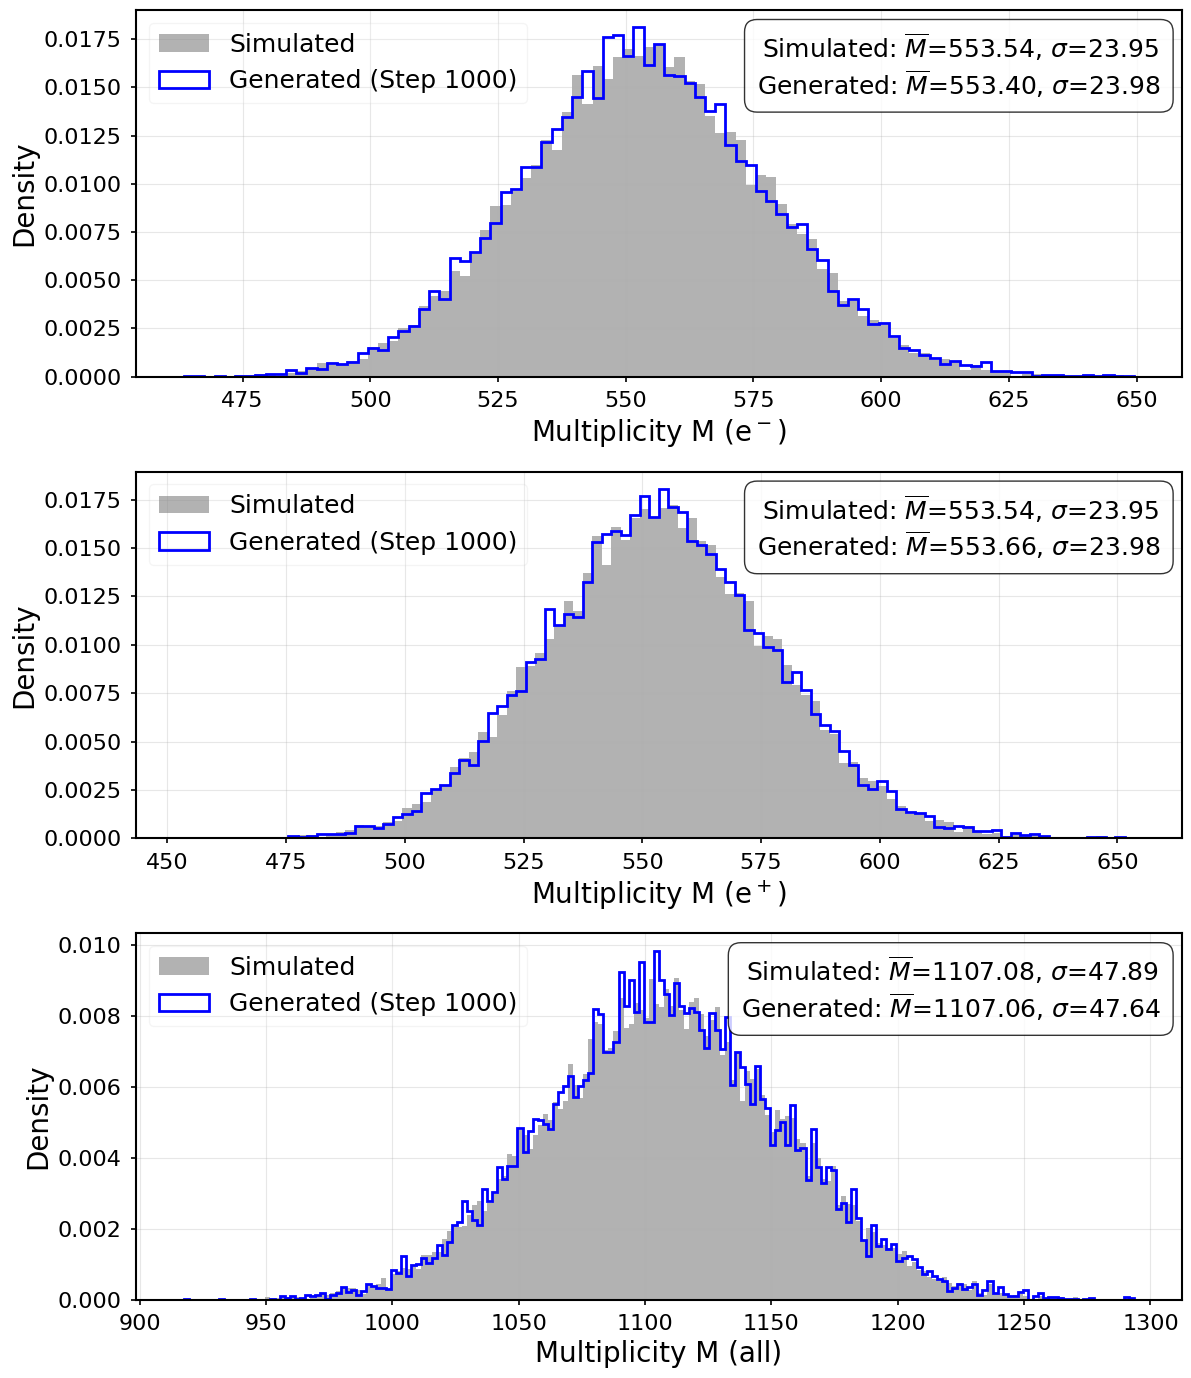

In [8]:
# Select which step to visualize (can be changed)
SELECTED_STEP = 200  # Change this to visualize different steps
plt.rcParams.update({
    'font.size': 14,           # Base font size
    'axes.labelsize': 20,      # Axis label font size
    'axes.titlesize': 22,      # Title font size
    'xtick.labelsize': 16,     # X-axis tick label size
    'ytick.labelsize': 16,     # Y-axis tick label size
    'legend.fontsize': 18,     # Legend font size
    'axes.linewidth': 1.5,     # Axis line width
    'grid.linewidth': 0.8,     # Grid line width
    'lines.linewidth': 2.0,    # Line width
    'xtick.major.width': 1.2,  # X tick width
    'ytick.major.width': 1.2,  # Y tick width
    'xtick.major.pad': 7,      # Padding between ticks and labels
    'ytick.major.pad': 7,      # Padding between ticks and labels
})

if SELECTED_STEP not in gen_data_all:
    print(f"Warning: Step {SELECTED_STEP} not available. Using first available step.")
    SELECTED_STEP = list(gen_data_all.keys())[0]

print(f"Visualizing multiplicity for step {SELECTED_STEP}")

gen_data_selected = gen_data_all[SELECTED_STEP]

fig, axes = plt.subplots(3, 1, figsize=(12, 14))

for idx, sp in enumerate(species_list):
    ax = axes[idx]
    tag = sp['tag']
    name = sp['name']
    # Replace name with latex if needed
    name = name.replace("e−", "e$^-$").replace("e+", "e$^+$")
    
    real_mult = real_data[tag]['mult']
    gen_mult = gen_data_selected[tag]['mult']

    all_mult = np.concatenate([real_mult, gen_mult])
    bins = np.arange(all_mult.min(), all_mult.max() + 2, 2) - 0.5
    
    ax.hist(real_mult, bins=bins, density=True, alpha=0.6, label='Simulated', color='grey')
    ax.hist(gen_mult, bins=bins, density=True, label=f'Generated (Step {SELECTED_STEP})', 
            histtype='step', linewidth=2, color='blue')
    
    ax.set_xlabel(f'Multiplicity M ({name})')
    ax.set_ylabel('Density')
    # ax.set_title(f'Multiplicity Distribution - {name} (Step {SELECTED_STEP})', fontsize=14)
    ax.legend(loc = 'upper left', framealpha=0.2)
    ax.annotate(f"Simulated: $\overline{{M}}$={real_mult.mean():.2f}, $\sigma$={real_mult.std():.2f} \nGenerated: $\overline{{M}}$={gen_mult.mean():.2f}, $\sigma$={gen_mult.std():.2f}",
                xy=(0.98, 0.94), xycoords='axes fraction', ha='right', va='top',
                bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.8), fontsize=18)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig(f'/work/submit/haoyun22/FCC-Beam-Background/output_figures/cosine_charge/multiplicity_comparison_step_{SELECTED_STEP}.pdf', dpi=300)
plt.show()

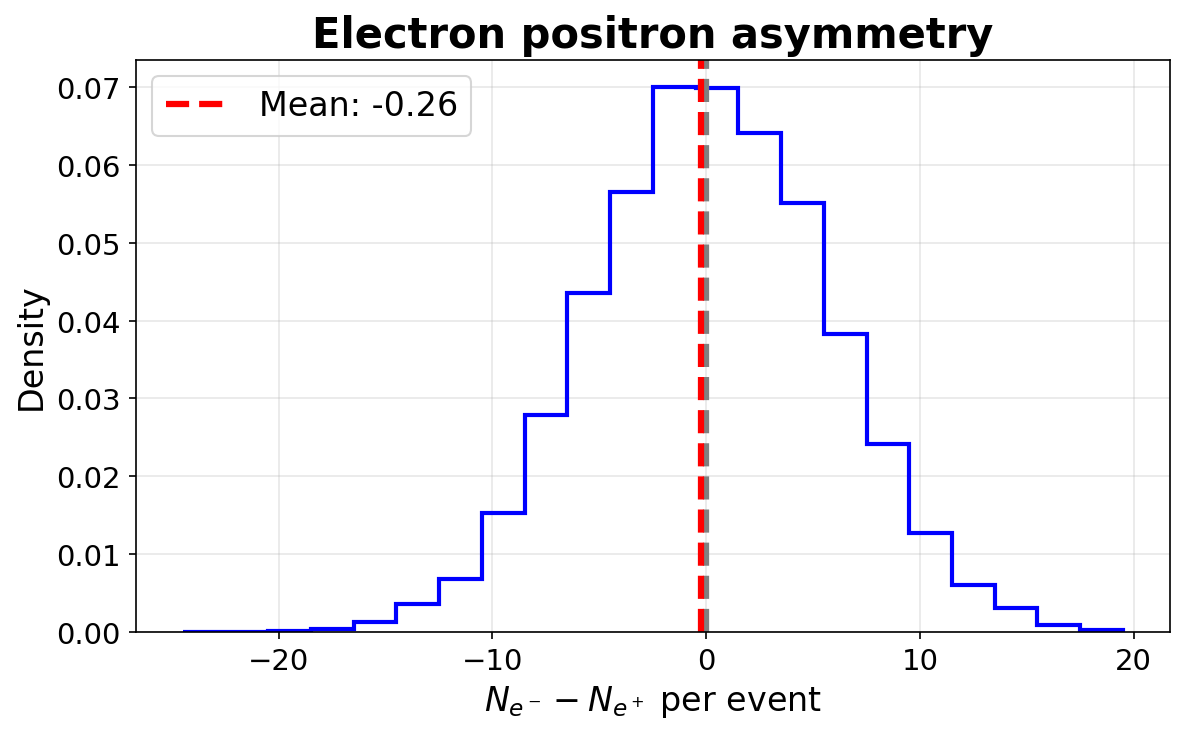

In [9]:
# Plot N(e-) - N(e+) per event (generated only)
gen_diff = gen_data_selected['eminus']['mult'] - gen_data_selected['eplus']['mult']

bins_diff = np.arange(gen_diff.min(), gen_diff.max() + 2, 2) - 0.5

fig, ax = plt.subplots(figsize=(8, 5), dpi=150)
ax.hist(gen_diff, bins=bins_diff, density=True,
        histtype='step', linewidth=2, color='blue')

ax.set_xlabel(r'$N_{e^-} - N_{e^+}$ per event')
ax.set_ylabel('Density')
ax.set_title('Electron positron asymmetry', fontweight='bold')
ax.axvline(0, color='grey', linestyle='--', linewidth=3)
ax.axvline(gen_diff.mean(), color='red', linestyle='--', linewidth=3, label=f'Mean: {gen_diff.mean():.2f}')
ax.legend(loc='upper left')
# ax.annotate(
#     f"mean={gen_diff.mean():.2f}, std={gen_diff.std():.2f}",
#     xy=(0.98, 0.94), xycoords='axes fraction', ha='right', va='top',
#     bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.8), fontsize=11)
ax.grid(True, alpha=0.3)
#plt.savefig(f'/work/submit/haoyun22/FCC-Beam-Background/output_figures/big_font/electron_positron_asymmetry_step_{SELECTED_STEP}.pdf', dpi=300)
plt.tight_layout()
plt.show()


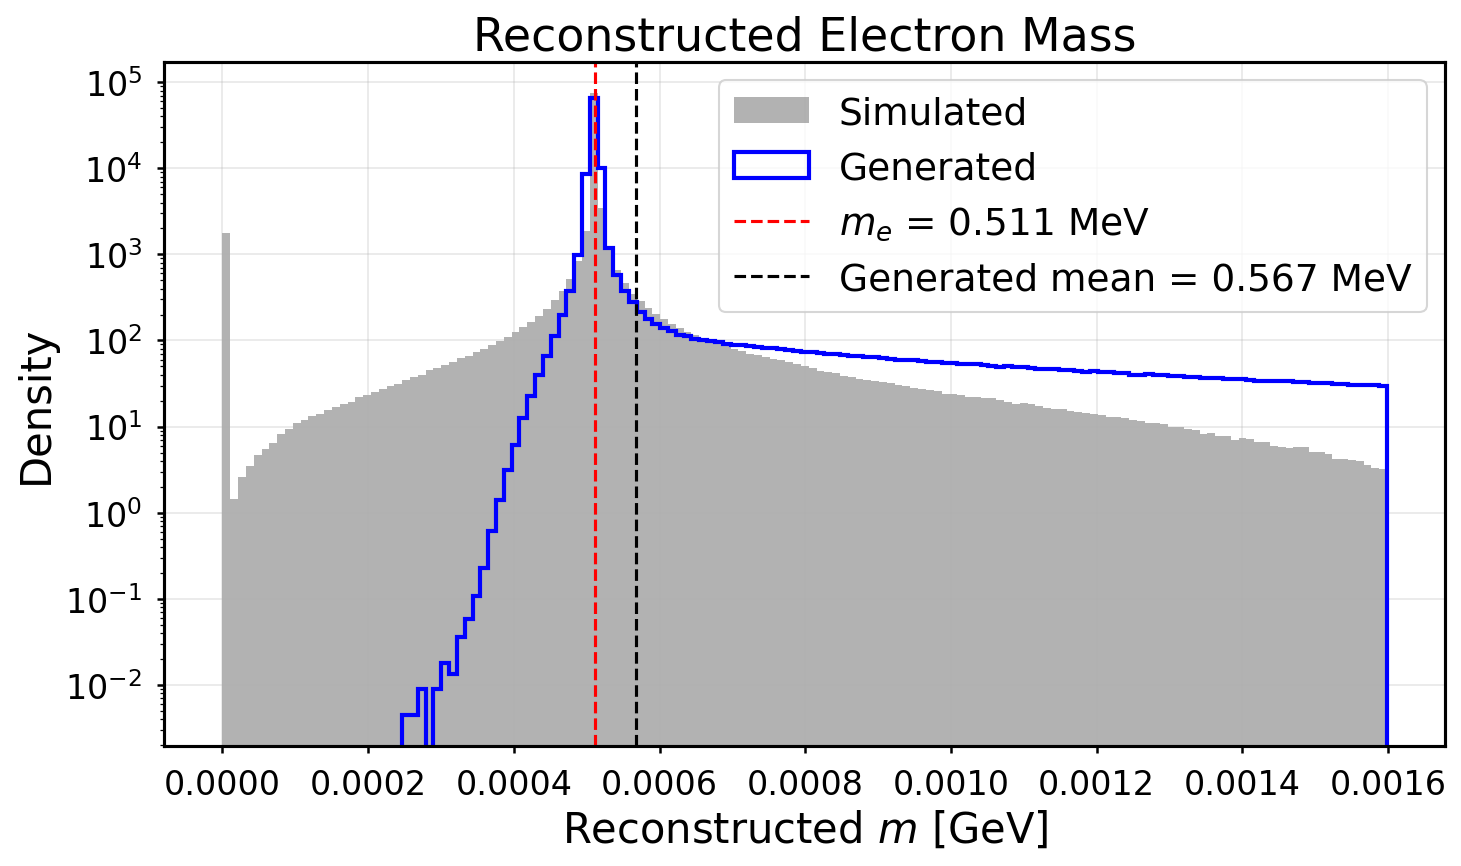

In [22]:
# Reconstructed electron mass: m = E * sqrt(1 - beta^2)
# Using E and beta directly (more stable than E^2 - p^2 method)
# Energy clipped to [0, 99th percentile] to remove extreme values

ME_PDG = 0.000511  # GeV

fig, ax = plt.subplots(1, 1, figsize=(10, 6), dpi=150)

tag = 'all'
label = 'All'

real_sp = real_data[tag]
gen_sp  = gen_data_selected[tag]

real_E_raw = real_sp['E']
real_beta_raw = real_sp['beta_mag']
gen_E_raw = gen_sp['E']
gen_beta_raw = gen_sp['beta_mag']

# Determine 99th percentile cut from combined data
E_max = np.quantile(np.concatenate([real_E_raw, gen_E_raw]), 0.95)

# Apply cuts (keep particles within range)
real_sel = (real_E_raw <= E_max)
gen_sel  = (gen_E_raw  <= E_max)

real_E, real_beta = real_E_raw[real_sel], real_beta_raw[real_sel]
gen_E,  gen_beta  = gen_E_raw[gen_sel],   gen_beta_raw[gen_sel]

# Calculate mass: m = E * sqrt(1 - beta^2)
real_m = real_E * np.sqrt(np.clip(1.0 - real_beta**2, 0, None))
gen_m  = gen_E * np.sqrt(np.clip(1.0 - gen_beta**2, 0, None))

combined = np.concatenate([real_m, gen_m])
hist_range = (0, np.quantile(combined, 0.99))
bins_m = np.linspace(*hist_range, 150)

ax.hist(real_m, bins=bins_m, density=True, alpha=0.6,
        label='Simulated', color='grey')
ax.hist(gen_m,  bins=bins_m, density=True,
        histtype='step', linewidth=2, color='blue',
        label=f'Generated')
ax.axvline(ME_PDG, color='red', linestyle='--', linewidth=1.5,
           label=r'$m_e$ = 0.511 MeV')
ax.axvline(gen_m.mean(), color='black', linestyle='--', linewidth=1.5,
           label=f'Generated mean = {gen_m.mean()*1e3:.3f} MeV')

ax.set_xlabel(r'Reconstructed $m$ [GeV]')
ax.set_ylabel('Density')
ax.set_yscale('log')
ax.set_title(f'Reconstructed Electron Mass')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 9. Energy and momentum distribution

Visualizing energy and momentum distributions for step 200


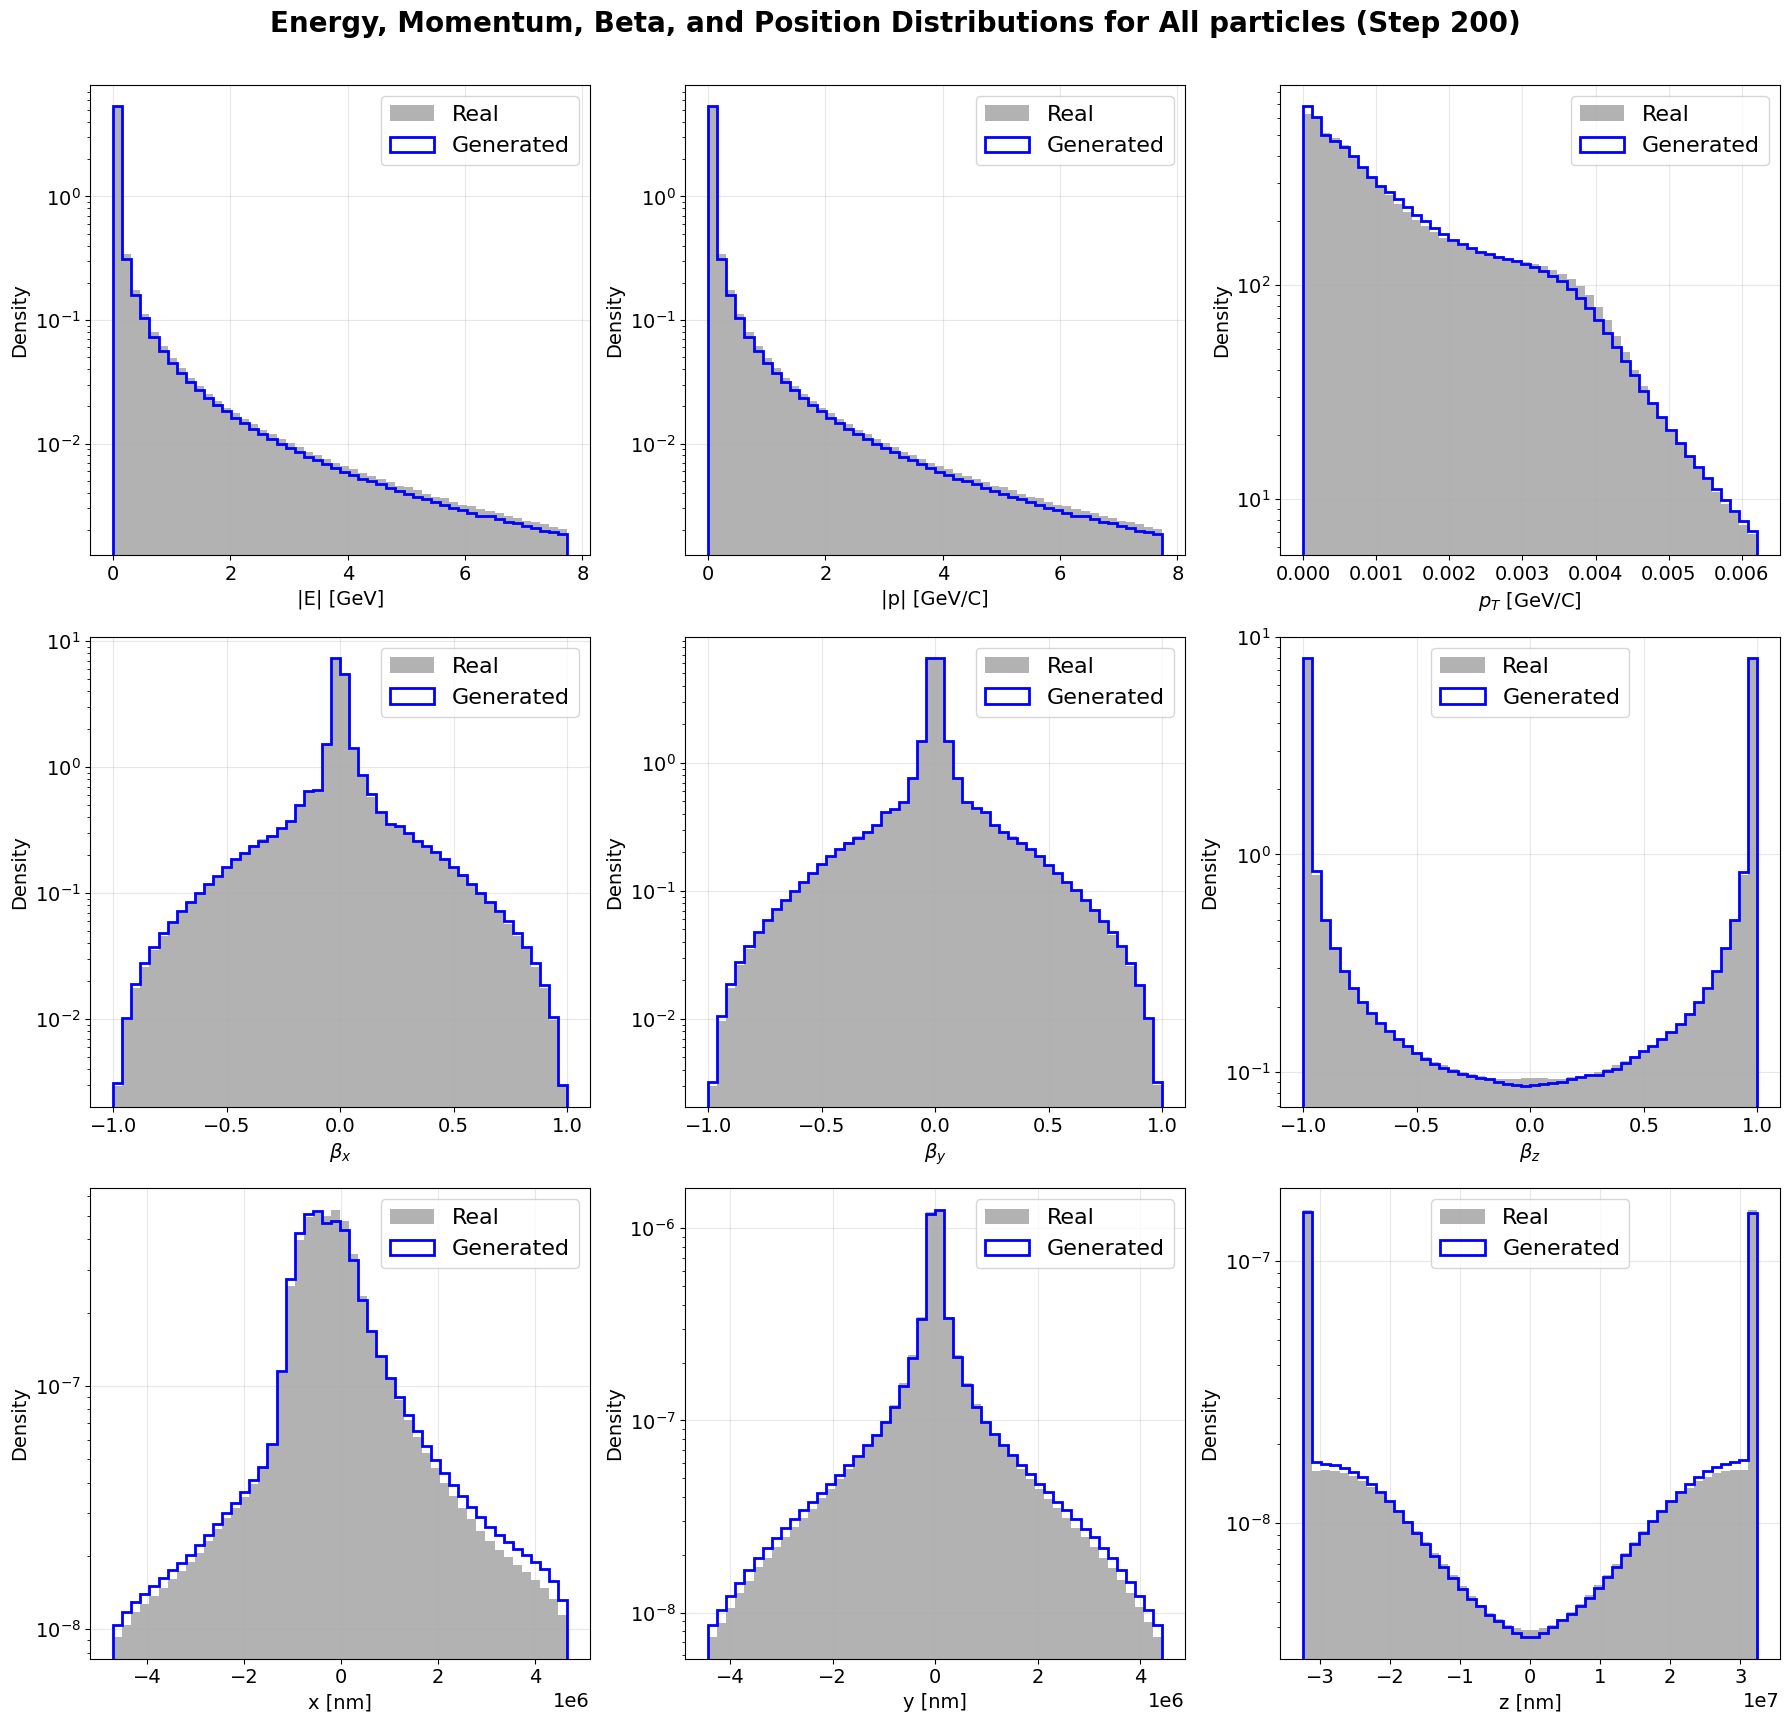

In [11]:
# Select which step to visualize
SELECTED_STEP = 200  # Change this to visualize different steps

if SELECTED_STEP not in gen_data_all:
    print(f"Warning: Step {SELECTED_STEP} not available. Using first available step.")
    SELECTED_STEP = list(gen_data_all.keys())[0]

print(f"Visualizing energy and momentum distributions for step {SELECTED_STEP}")

tag = 'all'  # select ['all', 'eminus','eplus']
name = 'All particles'

real_sp = real_data[tag]
gen_sp = gen_data_all[SELECTED_STEP][tag]

fig, axes = plt.subplots(3, 3, figsize=(18, 17))

plot_configs = [
    ('E', '|E| [GeV]', (0, np.quantile(np.concatenate([real_sp['E'], gen_sp['E']]), 0.99))),
    ('p', '|p| [GeV/C]', (0, np.quantile(np.concatenate([real_sp['p'], gen_sp['p']]), 0.99))),
    ('pt', '$p_T$ [GeV/C]', (0, np.quantile(np.concatenate([real_sp['pt'], gen_sp['pt']]), 0.99))),
    ('betax', '$\\beta_x$', (-1, 1)),
    ('betay', '$\\beta_y$', (-1, 1)),
    ('betaz', '$\\beta_z$', (-1, 1)),
    ('x', 'x [nm]', (np.quantile(np.concatenate([real_sp['x'], gen_sp['x']]), 0.01), np.quantile(np.concatenate([real_sp['x'], gen_sp['x']]), 0.99))),
    ('y', 'y [nm]', (np.quantile(np.concatenate([real_sp['y'], gen_sp['y']]), 0.01), np.quantile(np.concatenate([real_sp['y'], gen_sp['y']]), 0.99))),
    ('z', 'z [nm]', (np.quantile(np.concatenate([real_sp['z'], gen_sp['z']]), 0.01), np.quantile(np.concatenate([real_sp['z'], gen_sp['z']]), 0.99))),
]

for idx, (key, xlabel, range_lim) in enumerate(plot_configs):
    ax = axes[idx // 3, idx % 3]
    
    real_vals = real_sp[key]
    gen_vals = gen_sp[key]
    
    if real_vals.size > 0 and gen_vals.size > 0:
        ax.hist(real_vals, bins=50, range=range_lim, density=True, 
                alpha=0.6, label='Real', color='grey')
        ax.hist(gen_vals, bins=50, range=range_lim, density=True, 
                histtype='step', linewidth=2, label=f'Generated', color='blue')
        
        ax.set_xlabel(xlabel, fontsize=14)
        ax.set_ylabel('Density', fontsize=14)
        ax.set_yscale('log')
        # ax.set_title(f'{xlabel} - {name} (Step {SELECTED_STEP})', fontsize=14)
        ax.legend()
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()

plt.suptitle(f'Energy, Momentum, Beta, and Position Distributions for {name} (Step {SELECTED_STEP})', fontsize=20, fontweight='bold', y=1.01)
# plt.savefig(f'/work/submit/haoyun22/FCC-Beam-Background/output_figures/big_font/distributions_comparison_step_{SELECTED_STEP}_{tag}.pdf', dpi=300)
plt.tight_layout()
plt.show()

## 10. Event-Level analysis

Computing event-level observables...


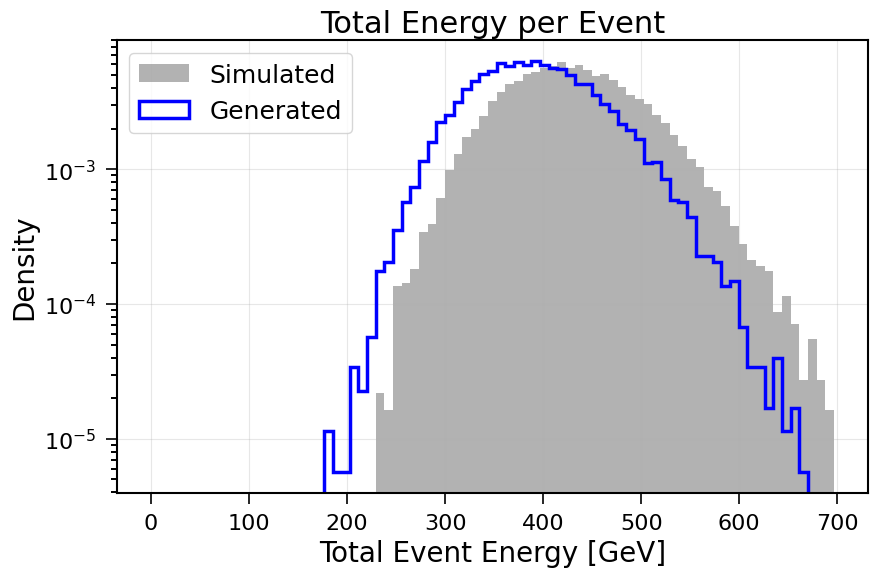

In [ ]:
# ── Event-Level Observables ──────────────────────────────────────────────────
# 1. Total energy per event
# 2. Total beta in x, y, z per event
# 3. Total momentum in x, y, z per event
# 4. Scatter plot of Total Energy vs Multiplicity
def compute_event_observables(events):
    event_E = []
    event_bx = []
    event_by = []
    event_bz = []
    event_px = []
    event_py = []
    event_pz = []
    event_mult = []
    for ev in events:
        out = sanitize_event(ev)
        px, py, pz = out[1:4]
        Eabs = out[4]
        betax, betay, betaz = out[10:13]
        
        event_E.append(np.sum(Eabs))
        event_bx.append(np.sum(betax))
        event_by.append(np.sum(betay))
        event_bz.append(np.sum(betaz))
        event_px.append(np.sum(px))
        event_py.append(np.sum(py))
        event_pz.append(np.sum(pz))
        event_mult.append(len(Eabs))
        
    return (np.array(event_E), 
            np.array(event_bx), np.array(event_by), np.array(event_bz), 
            np.array(event_px), np.array(event_py), np.array(event_pz),
            np.array(event_mult))

print("Computing event-level observables...")
real_ev_E, real_ev_bx, real_ev_by, real_ev_bz, real_ev_px, real_ev_py, real_ev_pz, real_ev_mult = compute_event_observables(real_events)
gen_ev_E, gen_ev_bx, gen_ev_by, gen_ev_bz, gen_ev_px, gen_ev_py, gen_ev_pz, gen_ev_mult = compute_event_observables(gen_events_all[SELECTED_STEP])

# ── 1. Total Energy per Event ──
plt.figure(figsize=(9, 6))
bins_E = np.linspace(0, np.percentile(np.concatenate([real_ev_E, gen_ev_E]), 99.99), 80)
plt.hist(real_ev_E, bins=bins_E, density=True, alpha=0.6, label='Simulated', color='grey')
plt.hist(gen_ev_E, bins=bins_E, density=True, histtype='step', linewidth=2.5, color='blue', label='Generated')
plt.yscale('log')
plt.xlabel('Total Event Energy [GeV]')
plt.ylabel('Density')
plt.title(f'Total Energy per Event')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig(f'/work/submit/haoyun22/FCC-Beam-Background/output_figures/cosine_charge/event_energy_comparison_step_{SELECTED_STEP}.pdf', dpi=300)
plt.show()

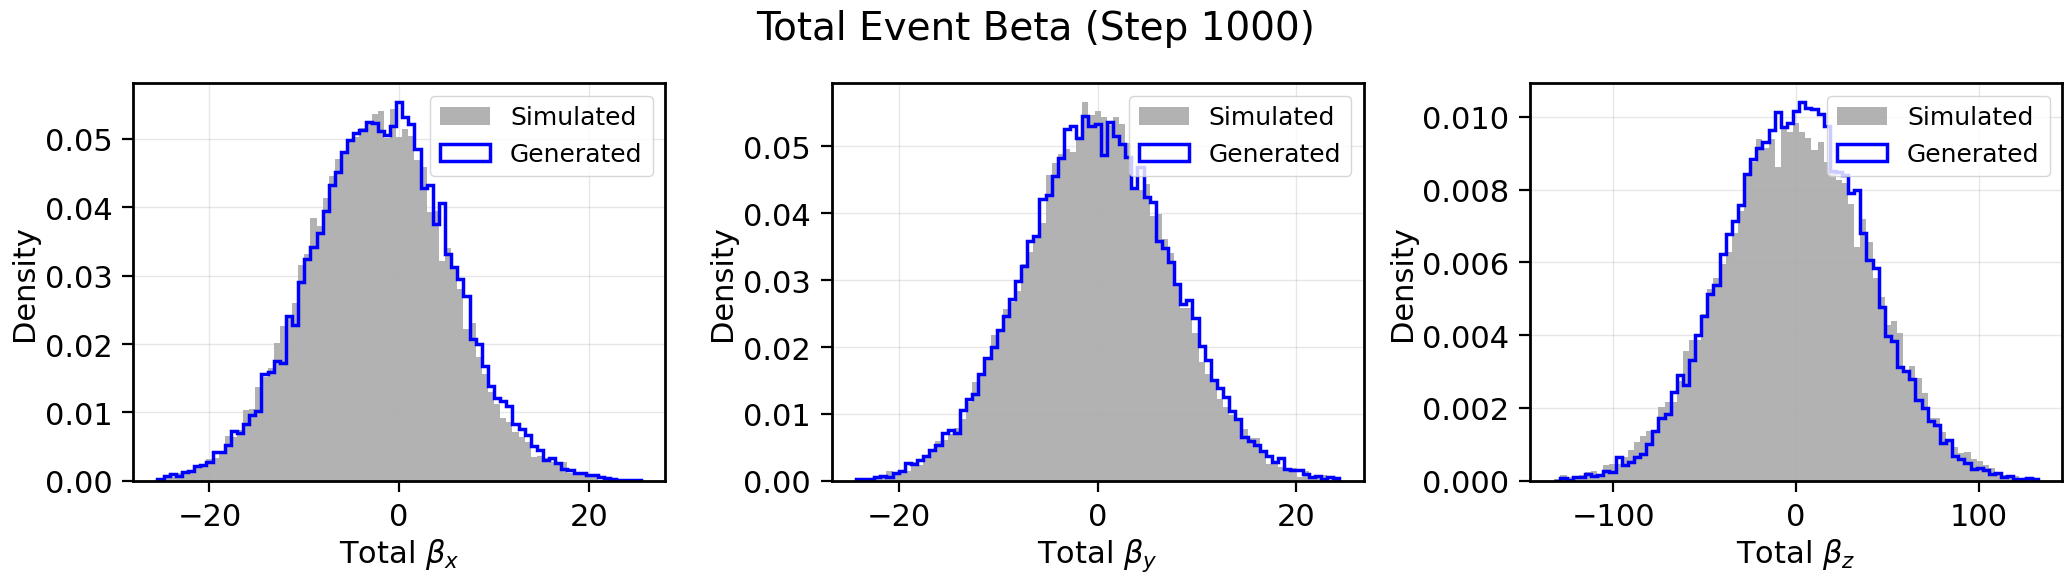

In [ ]:
# ── 2. Total Event Beta (betax, betay, betaz) ──
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle(f'Total Event Beta (Step {SELECTED_STEP})', fontsize=28)

for ax, P_real, P_gen, axis_label in zip(
    axes, 
    [real_ev_bx, real_ev_by, real_ev_bz], 
    [gen_ev_bx, gen_ev_by, gen_ev_bz], 
    [r'$\beta_x$', r'$\beta_y$', r'$\beta_z$']
):
    lim = np.percentile(np.abs(np.concatenate([P_real, P_gen])), 99.9)
    bins_P = np.linspace(-lim, lim, 80)
    
    ax.hist(P_real, bins=bins_P, density=True, alpha=0.6, color='grey', label='Simulated')
    ax.hist(P_gen, bins=bins_P, density=True, histtype='step', linewidth=2.5, color='blue', label='Generated')
    
    ax.set_xlabel(f'Total {axis_label}')
    ax.set_ylabel('Density')
    ax.set_yscale('linear')
    ax.legend(fontsize=18)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'/work/submit/haoyun22/FCC-Beam-Background/output_figures/cosine_charge/event_beta_comparison_step_{SELECTED_STEP}.pdf', dpi=300)
plt.show()

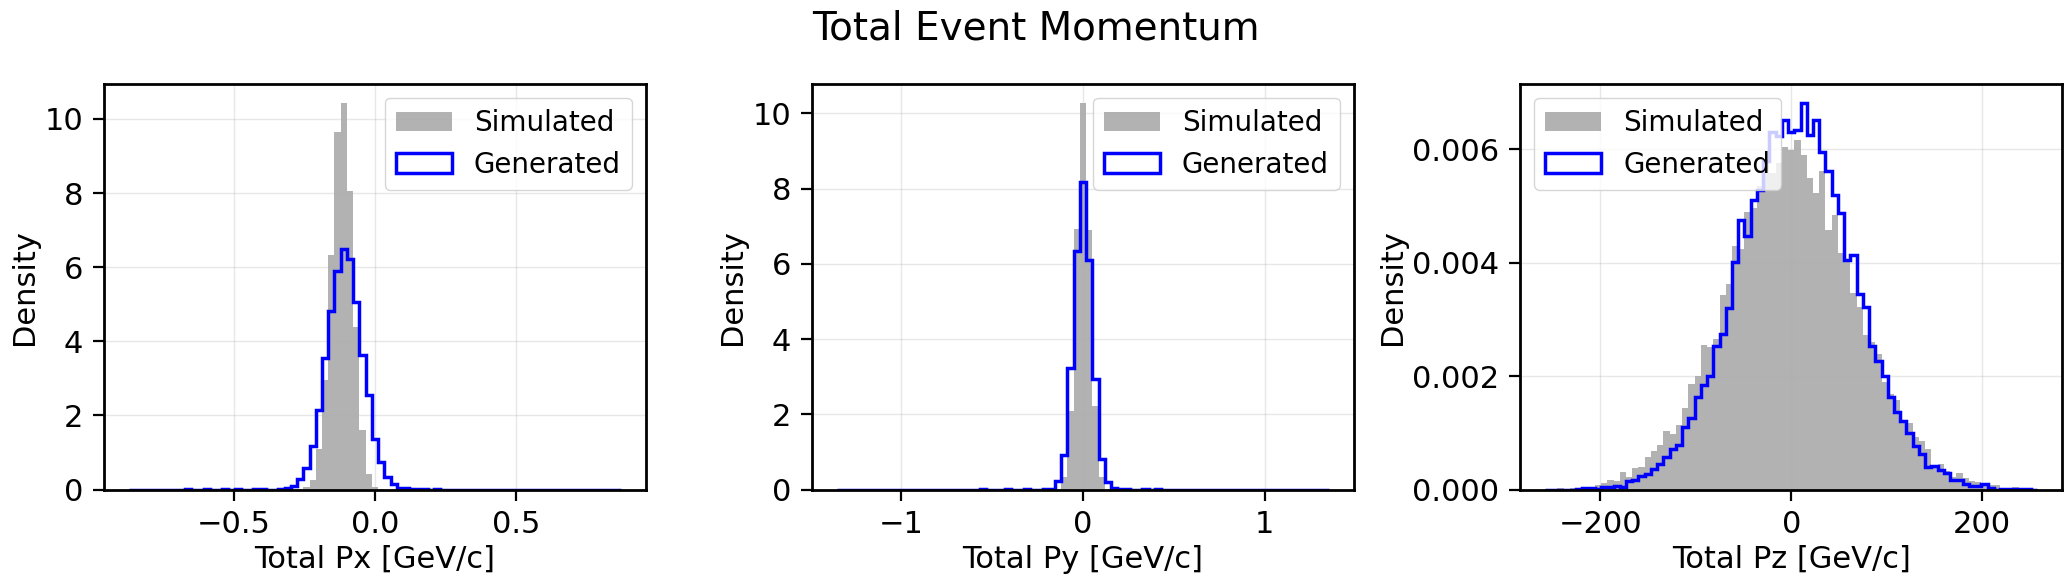

In [ ]:
# ── 3. Total Event Momentum (px, py, pz) ──
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle(f'Total Event Momentum', fontsize=28)

for ax, P_real, P_gen, axis_label in zip(
    axes, 
    [real_ev_px, real_ev_py, real_ev_pz], 
    [gen_ev_px, gen_ev_py, gen_ev_pz], 
    ['Px', 'Py', 'Pz']
):
    lim = np.percentile(np.abs(np.concatenate([P_real, P_gen])), 99.99)
    bins_P = np.linspace(-lim, lim, 80)
    
    ax.hist(P_real, bins=bins_P, density=True, alpha=0.6, color='grey', label='Simulated')
    ax.hist(P_gen, bins=bins_P, density=True, histtype='step', linewidth=2.5, color='blue', label='Generated')
    ax.set_xlabel(f'Total {axis_label} [GeV/c]')
    ax.set_ylabel('Density')
    ax.set_yscale('linear')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'/work/submit/haoyun22/FCC-Beam-Background/output_figures/cosine_charge/event_momentum_comparison_step_{SELECTED_STEP}.pdf', dpi=300)
plt.show()

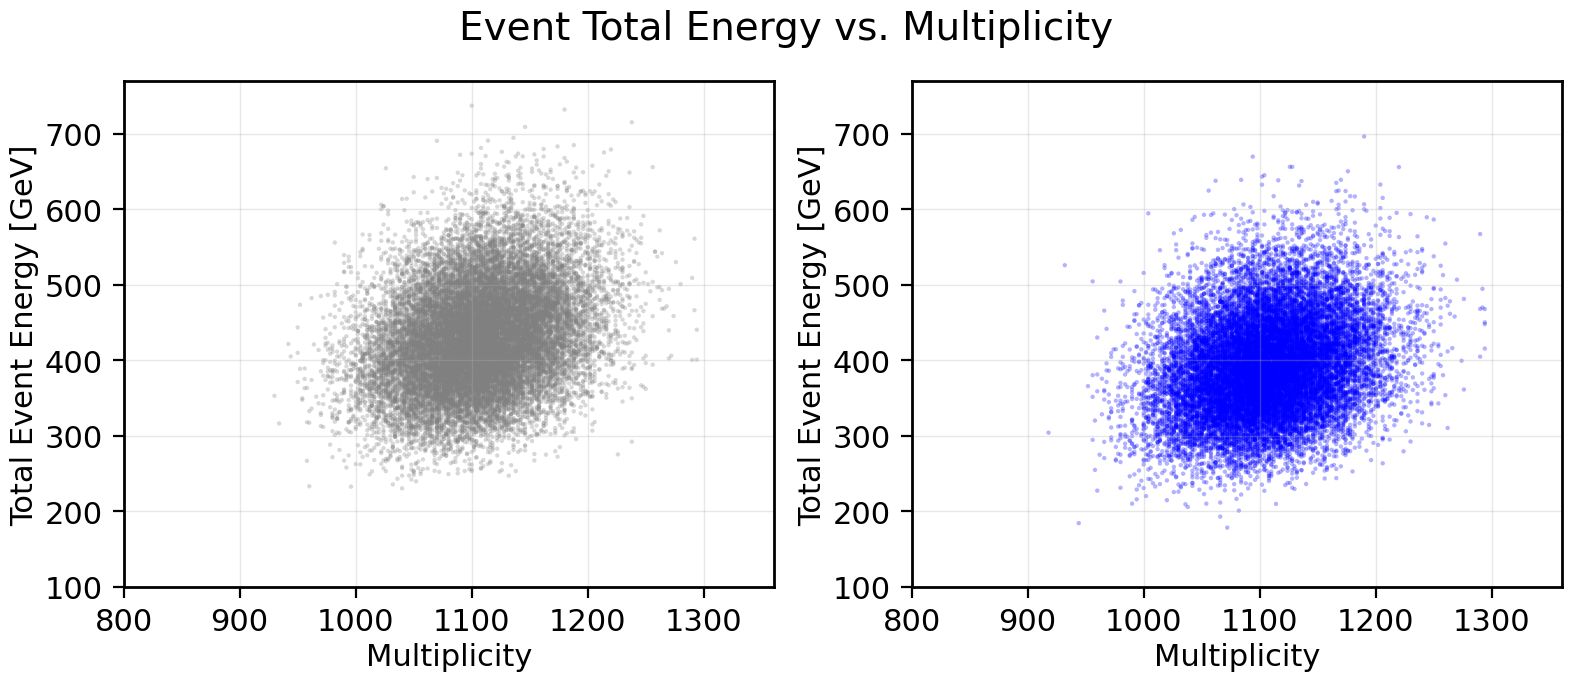

In [ ]:
# ── 4. Energy vs Multiplicity Scatter Plot ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(f'Event Total Energy vs. Multiplicity', fontsize=28)

# Avoid extreme outliers for plotting range
max_mult = max(np.percentile(real_ev_mult, 99.9), np.percentile(gen_ev_mult, 99.9))
max_E = max(np.percentile(real_ev_E, 99.9), np.percentile(gen_ev_E, 99.9))

# Simulated
sc1 = ax1.scatter(real_ev_mult, real_ev_E, alpha=0.3, s=10, color='grey', edgecolors='none')
ax1.set_xlabel('Multiplicity')
ax1.set_ylabel('Total Event Energy [GeV]')
ax1.set_xlim(800, max_mult+100)
ax1.set_ylim(100, max_E+100)
ax1.grid(True, alpha=0.3)

# Generated
sc2 = ax2.scatter(gen_ev_mult, gen_ev_E, alpha=0.3, s=10, color='blue', edgecolors='none')
ax2.set_xlabel('Multiplicity')
ax2.set_ylabel('Total Event Energy [GeV]')
ax2.set_xlim(800, max_mult+100)
ax2.set_ylim(100, max_E+100)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'/work/submit/haoyun22/FCC-Beam-Background/output_figures/cosine_charge/event_energy_vs_multiplicity_step_{SELECTED_STEP}.pdf', dpi=300)
plt.show()

## 11. Corner Plots - Beta and Position Distributions

These plots show correlations between beta components and positions for real vs generated data.

In [153]:
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter

try:
    import corner
    HAVE_CORNER = True
    print("Corner library imported successfully!")
except ImportError:
    HAVE_CORNER = False
    print("Corner library not found. Corner plots will be skipped.")


def downsample_data(data, max_points=300000, seed=42):
    """
    Downsample data to max_points for faster corner plotting.
    """
    if len(data) <= max_points:
        return data
    
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(data), size=max_points, replace=False)
    return data[indices]

def robust_range_corner(real_vals, gen_vals, q_lo=0.01, q_hi=0.99):
    """
    Compute robust range for corner plots based on quantiles.
    """
    all_vals = np.concatenate([real_vals, gen_vals])
    all_vals = all_vals[np.isfinite(all_vals)]
    
    if len(all_vals) < 2:
        return None
    
    lo = float(np.quantile(all_vals, q_lo))
    hi = float(np.quantile(all_vals, q_hi))
    
    if not np.isfinite(lo) or not np.isfinite(hi) or lo >= hi:
        return None
    
    return (lo, hi)

def create_corner_plot(real_sp, gen_sp, keys, labels, title, max_points=150000, save = False):
    """
    Create overlay corner plot comparing real and generated distributions.
    
    Args:
        real_sp: Dictionary with real data
        gen_sp: Dictionary with generated data
        keys: List of keys to plot (e.g., ['betax', 'betay', 'betaz'])
        labels: List of axis labels
        title: Plot title
        max_points: Maximum points per dataset (for downsampling)
    """
    # Set matplotlib parameters for publication-quality figures
    plt.rcParams.update({
        'font.size': 16,
        'axes.labelsize': 18,
        'axes.titlesize': 28,
        'xtick.labelsize': 24,
        'ytick.labelsize': 24,
        'legend.fontsize': 20,
        'axes.linewidth': 1.5,
        'grid.linewidth': 1,
        'lines.linewidth': 1.8,
        'xtick.major.width': 1.4,
        'ytick.major.width': 1.4,
        'xtick.minor.width': 1.2,
        'ytick.minor.width': 1.2,
        'xtick.major.size': 6,
        'ytick.major.size': 6,
        'xtick.minor.size': 3,
        'ytick.minor.size': 3,
        'xtick.major.pad': 7,
        'ytick.major.pad': 7,
    })
    
    if not HAVE_CORNER:
        print(f"⚠ Cannot create corner plot '{title}': corner library not installed")
        return
    
    # Check if all keys have data
    for key in keys:
        if real_sp[key].size == 0 or gen_sp[key].size == 0:
            print(f"⚠ Cannot create corner plot '{title}': missing data for {key}")
            return
    
    # Build data matrices
    real_data_list = []
    gen_data_list = []
    ranges = []
    
    for key in keys:
        real_vals = real_sp[key]
        gen_vals = gen_sp[key]
        
        # Remove non-finite values
        real_vals = real_vals[np.isfinite(real_vals)]
        gen_vals = gen_vals[np.isfinite(gen_vals)]
        
        # Compute range
        if key == 'betaz':
            rng = (-1.0, 1.0)
        else:
            rng = robust_range_corner(real_vals, gen_vals, q_lo=0.01, q_hi=0.99)
            if rng is None:
                print(f"⚠ Cannot compute range for {key}")
                return
        
        ranges.append(rng)
        real_data_list.append(real_vals)
        gen_data_list.append(gen_vals)
    
    # Stack into matrices (N, D)
    # Find minimum length to create rectangular arrays
    real_min_len = min(len(arr) for arr in real_data_list)
    gen_min_len = min(len(arr) for arr in gen_data_list)
    
    real_matrix = np.column_stack([arr[:real_min_len] for arr in real_data_list])
    gen_matrix = np.column_stack([arr[:gen_min_len] for arr in gen_data_list])
    
    # Downsample
    if real_matrix.shape[0] > max_points:
        real_matrix = downsample_data(real_matrix, max_points)
        print(f"  Downsampled real data: {real_min_len} → {max_points} points")
    
    if gen_matrix.shape[0] > max_points:
        gen_matrix = downsample_data(gen_matrix, max_points)
        print(f"  Downsampled generated data: {gen_min_len} → {max_points} points")
    
    # Create the corner plot with scatter points for real data
    fig = corner.corner(
        real_matrix,
        labels=labels,
        range=ranges,
        color='blue',
        alpha=0.3,
        hist_kwargs={'density': True, 'alpha': 0.6},
        label='Simulated Data',
        plot_datapoints=True,
        plot_density=False,
        plot_contours=True,
        fill_contours=False,
        levels=[0.68, 0.95],
        contour_kwargs={'linewidths': 1.5, 'alpha': 0.8},
        data_kwargs={'alpha': 0.3, 'ms': 1.5},
        smooth=0.7
    )

    # Set y-axis to log scale for diagonal histograms
    for idx in [0, 4, 8]:
        ax = fig.axes[idx]
        ax.set_yscale('log')
        ax.grid(True, alpha=0.3)
    
    # Overlay generated data with scatter points
    corner.corner(
        gen_matrix,
        fig=fig,
        labels=labels,
        range=ranges,
        color='red',
        alpha=0.3,
        hist_kwargs={'density': True, 'histtype': 'step', 'linewidth': 2, 'alpha': 0.5},
        label='Diffusion Model Data',
        plot_datapoints=True,
        plot_density=False,
        plot_contours=True,
        fill_contours=False,
        levels=[0.68, 0.95],
        contour_kwargs={'linewidths': 1.5, 'alpha': 0.8},
        data_kwargs={'alpha': 0.3, 'ms': 1.5},
        smooth=0.7
    )
    
    # Add title
    fig.suptitle(title, y=1.0)
    # Add title for diagonal histograms display q16, q50, q84
    diag_axes = [fig.axes[i] for i in [0, 4, 8]]
    for i, ax in enumerate(diag_axes):
        real_vals = real_matrix[:, i]
        q16_real, q50_real, q84_real = np.percentile(real_vals, [16, 50, 84])
        
        # Calculate errors
        upper_err = q84_real - q50_real
        lower_err = q50_real - q16_real
        
        # Format title with median and errors
        #title_text = f'{labels[i]} = {q50_real:.2f}$^{{+{upper_err:.2f}}}_{{-{lower_err:.2f}}}$'
        #ax.set_title(title_text, fontsize=12)

    # Add custom legend
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Simulated Data',
               markerfacecolor='blue', markersize=8, alpha=0.6),
        Line2D([0], [0], marker='o', color='w', label='Diffusion Model Data',
               markerfacecolor='red', markersize=8, alpha=0.6)
    ]
    fig.legend(handles=legend_elements, fontsize=16, frameon=True, fancybox=True, shadow=False, framealpha=0.95,
               bbox_to_anchor=(0.98, 0.95), loc='upper right')
    
    # Add legend to the top-right corner of the figure
    axes = fig.get_axes()
    
    # Adjust tick labels and axis labels to prevent overlap
    for ax in axes:
        # Reduce tick label font size
        ax.tick_params(axis='both', which='major', labelsize=9)
        
        # Increase padding between axis labels and tick labels
        if ax.get_xlabel():
            ax.set_xlabel(ax.get_xlabel(), labelpad=10)
        if ax.get_ylabel():
            ax.set_ylabel(ax.get_ylabel(), labelpad=10)
        
        # Reduce number of ticks if needed
        ax.locator_params(axis='x', nbins=5)
        ax.locator_params(axis='y', nbins=5)
        # ax.xaxis.set_major_formatter(FormatStrFormatter('%.2e'))
        # ax.yaxis.set_major_formatter(FormatStrFormatter('%.2e'))

    plt.tight_layout()
    
    if save:
        plt.savefig(f'/work/submit/haoyun22/FCC-Beam-Background/output_figures/cosine_charge/corner_plot_{title.replace(" ", "_")}.pdf', dpi=300)
    
    plt.show()
    
print("✓ Corner plot functions defined")

Corner library imported successfully!
✓ Corner plot functions defined


### 11.1 Corner Plots - Momentum Components (px, py, pz)

Creating corner plots for beta components (step 200)...


  Downsampled real data: 22945338 → 50000 points
  Downsampled generated data: 22141272 → 50000 points


/work/submit/haoyun22/FCC-Beam-Background/FCC310/lib/python3.10/site-packages/corner/core.py:928: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  return ax.set_ylim(new_ylim)
/work/submit/haoyun22/FCC-Beam-Background/FCC310/lib/python3.10/site-packages/corner/core.py:928: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  return ax.set_ylim(new_ylim)
/work/submit/haoyun22/FCC-Beam-Background/FCC310/lib/python3.10/site-packages/corner/core.py:928: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  return ax.set_ylim(new_ylim)
/tmp/ipykernel_818841/837713216.py:217: UserWarning: 'set_params()' not defined for locator of type <class 'matplotlib.ticker.NullLocator'>
  ax.locator_params(axis='y', nbins=5)


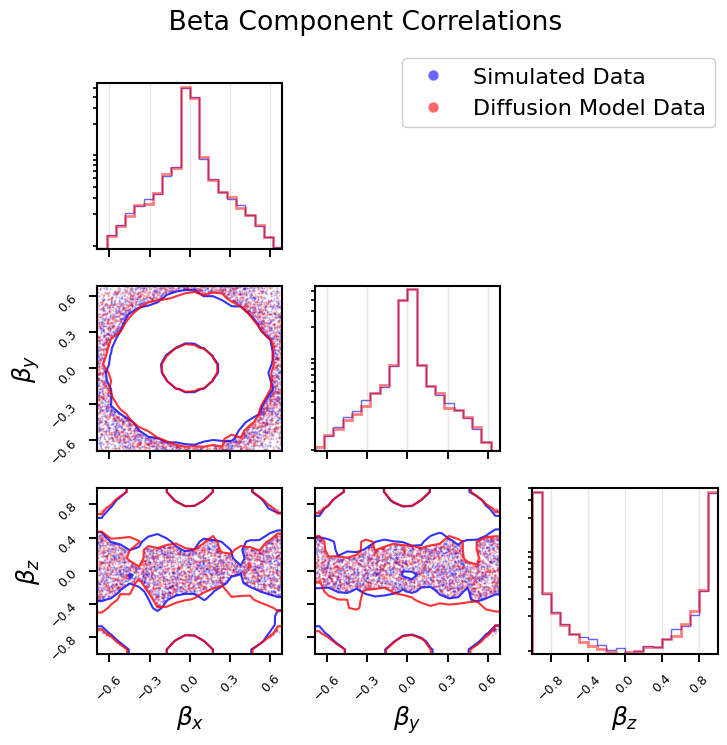


✓ Beta component corner plots complete


In [ ]:
if HAVE_CORNER:
    # Select which step to visualize
    SELECTED_STEP = 200  # Change this to visualize different steps
    
    if SELECTED_STEP not in gen_data_all:
        print(f"Warning: Step {SELECTED_STEP} not available. Using first available step.")
        SELECTED_STEP = list(gen_data_all.keys())[0]
    
    print(f"Creating corner plots for beta components (step {SELECTED_STEP})...")
    
    # Only plot for all particles
    tag = 'all'
    name = 'All particles'
    
    real_sp = real_data[tag]
    gen_sp = gen_data_all[SELECTED_STEP][tag]

    # convert px py to MeV/c for better visualization (optional)
    # real_sp_scaled = real_sp.copy()
    # gen_sp_scaled = gen_sp.copy()
    
    # real_sp_scaled['px'] = real_sp['px'] * 1000
    # real_sp_scaled['py'] = real_sp['py'] * 1000
    # gen_sp_scaled['px'] = gen_sp['px'] * 1000
    # gen_sp_scaled['py'] = gen_sp['py'] * 1000
    
    create_corner_plot(
        real_sp=real_sp,
        gen_sp=gen_sp,
        keys=['betax', 'betay', 'betaz'], #keys=['px', 'py', 'pz']
        labels=[r'$\beta_x$', r'$\beta_y$', r'$\beta_z$'], #labels=[r'$p_x$ [MeV/C]', r'$p_y$ [MeV/C]', r'$p_z$ [MeV/C]']
        title=f' Beta Component Correlations',
        max_points=50000,
        save = True
    )
    
    print("\n✓ Beta component corner plots complete")
else:
    print("⚠ Install corner library to create corner plots: pip install corner")

### Helper Function for Distribution Comparison with Fractional Difference

In [72]:
def plot_distribution_comparison(real_vals, gen_vals, xlabel, title, 
                                  bins=80, range_quantile=0.99, 
                                  figsize=(10, 10), threshold=0.1, yscale='linear', save=False):
    """
    Plot distribution comparison between real and generated data with fractional difference.
    
    Args:
        real_vals: Real data values (1D array)
        gen_vals: Generated data values (1D array)
        xlabel: Label for x-axis
        title: Main title for the plot
        bins: Number of bins for histogram (default: 80)
        range_quantile: Quantile for determining the range (default: 0.99)
        figsize: Figure size tuple (default: (8, 8))
        threshold: Threshold for coloring fractional difference (default: 0.1 for ±10%)
        yscale: Scale for y-axis (default: 'linear')
        save: Whether to save the plot as PDF (default: False)
    """
    # Set matplotlib parameters for publication-quality figures
    plt.rcParams.update({
        'font.size': 16,           # Base font size
        'axes.labelsize': 22,      # Axis label font size
        'axes.titlesize': 28,      # Title font size
        'xtick.labelsize': 16,     # X-axis tick label size
        'ytick.labelsize': 22,     # Y-axis tick label size
        'legend.fontsize': 20,     # Legend font size
        'axes.linewidth': 2,     # Axis line width
        'grid.linewidth': 1,     # Grid line width
        'lines.linewidth': 1.8,    # Line width
        'xtick.major.width': 1.6,  # X tick width
        'ytick.major.width': 1.6,  # Y tick width
        'xtick.minor.width': 1.4,  # X minor tick width
        'ytick.minor.width': 1.4,  # Y minor tick width
        'xtick.major.size': 8,     # X major tick size
        'ytick.major.size': 8,     # Y major tick size
        'xtick.minor.size': 4,     # X minor tick size
        'ytick.minor.size': 4,     # Y minor tick size
        'xtick.major.pad': 7,      # Padding between ticks and labels
        'ytick.major.pad': 7,
    })
    
    # Calculate histogram range - handle both positive-only and data with negatives
    combined = np.concatenate([real_vals, gen_vals])

    if range_quantile <= 0.5 or range_quantile >= 1.0:
        raise ValueError("range_quantile should be between 0.5 and 1.0 for meaningful range calculation.")
    
    if np.min(combined) >= 0:
        # Positive-only data (like pT, p, E)
        hist_range = (0, np.quantile(combined, range_quantile))
    else:
        # Data with negatives (like px, py, pz, betax, betay, betaz)
        q_low = 1 - range_quantile
        hist_range = (np.quantile(combined, q_low), np.quantile(combined, range_quantile))
    
    # Calculate histograms
    real_hist, bin_edges = np.histogram(real_vals, bins=bins, range=hist_range, density=True)
    gen_hist, _ = np.histogram(gen_vals, bins=bin_edges, density=True)
    
    # kl_div = entropy(real_hist + 1e-10, gen_hist + 1e-10)  # add small value to avoid log(0)
    # wass_dist = wasserstein_distance(real_vals, gen_vals)

    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, gridspec_kw={'height_ratios': [3, 1]})
    fig.suptitle(title, fontsize=26)
    
    # Upper subplot: Distribution comparison
    ax1.hist(real_vals, bins=bin_edges, density=True, alpha=0.6, label='Simulated', color='grey')
    ax1.hist(gen_vals, bins=bin_edges, density=True, histtype='step', linewidth=2.5, label='Generated', color='blue')
    ax1.set_ylabel('Density')
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)
    ax1.set_yscale(yscale)
    #ax1.set_xlim(-0.0035, 0.0035)
    

    # Annotate KL divergence and Wasserstein distance
    # ax1.text(0.98, 0.97, f'KL Divergence: {kl_div:.4f}\nWasserstein Dist: {wass_dist:.4f}',
    #          transform=ax1.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='right',
    #          bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))
    
    # Lower subplot: Fractional difference
    frac_diff = np.where(real_hist > 0, (gen_hist - real_hist) / real_hist, 0)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Categorize points by threshold
    within_threshold_idx = [i for i, fd in enumerate(frac_diff) if abs(fd) <= threshold]
    beyond_threshold_idx = [i for i, fd in enumerate(frac_diff) if abs(fd) > threshold]
    
    # Plot all points in gray first
    # ax2.scatter(bin_centers, frac_diff, marker='o', color='gray', alpha=0.5, s=20)
    ax2.plot(bin_centers, frac_diff, color='blue', alpha=1, linestyle='-', linewidth=2.5)
    # Overlay colored points
    # if within_threshold_idx:
    #     ax2.scatter(bin_centers[within_threshold_idx], frac_diff[within_threshold_idx], 
    #                marker='o', color='green', label=f'Within ±{int(threshold*100)}%', zorder=3, s=25)
    # if beyond_threshold_idx:
    #     ax2.scatter(bin_centers[beyond_threshold_idx], frac_diff[beyond_threshold_idx], 
    #                marker='o', color='red', label=f'Beyond ±{int(threshold*100)}%', zorder=3, s=25)
    
    # Reference lines
    ax2.axhline(0, color='black', linestyle='-', linewidth=1.5, alpha =1)
    ax2.axhline(threshold, color='grey', linestyle='--', linewidth=1.5, alpha=1, 
                label=f'±{int(threshold*100)}%')
    ax2.axhline(-threshold, color='grey', linestyle='--', linewidth=1.5, alpha=1)
    
    ax2.set_xlabel(xlabel)
    ax2.set_ylabel('Frac Diff')
    ax2.legend(loc='best')
    # ax2.grid(True, alpha=0.3)
    ax2.set_ylim(-0.5, 0.5)
    #ax2.set_xlim(-0.0035, 0.0035)
    
    if save:
        plt.savefig(f'/work/submit/haoyun22/FCC-Beam-Background/output_figures/cosine_charge/distribution_comparison_{physics}_peak_step_{SELECTED_STEP}_{tag}.pdf', dpi=300)

    plt.tight_layout()
    plt.show()
    
    # Print statistics
    n_within = len(within_threshold_idx)
    n_beyond = len(beyond_threshold_idx)
    n_total = len(frac_diff)
    print(f"Statistics:")
    print(f"  Within ±{int(threshold*100)}%: {n_within}/{n_total} ({100*n_within/n_total:.1f}%)")
    print(f"  Beyond ±{int(threshold*100)}%: {n_beyond}/{n_total} ({100*n_beyond/n_total:.1f}%)")

print("✓ Distribution comparison function defined")

✓ Distribution comparison function defined


Comparing distributions for step 1000


/tmp/ipykernel_2024163/44059332.py:83: RuntimeWarning: invalid value encountered in divide
  frac_diff = np.where(real_hist > 0, (gen_hist - real_hist) / real_hist, 0)


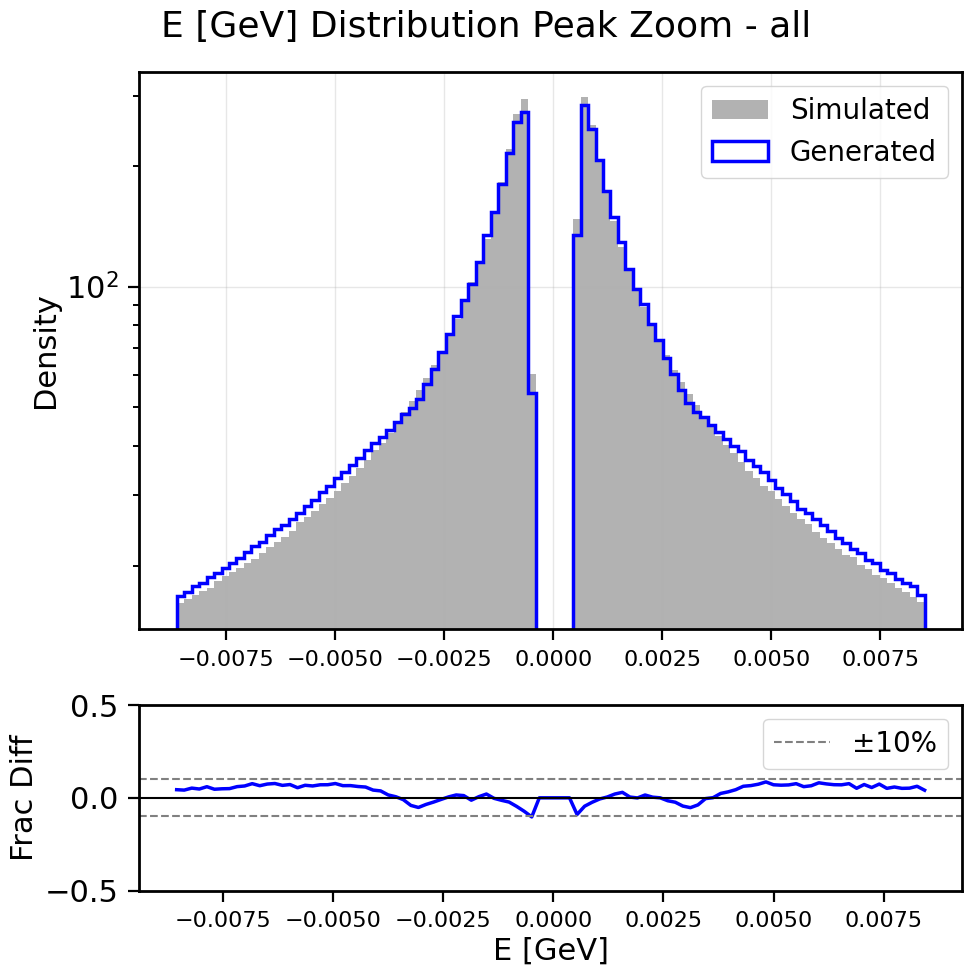

Statistics:
  Within ±10%: 99/100 (99.0%)
  Beyond ±10%: 1/100 (1.0%)


In [74]:
# Example: Compare distributions using the helper function
 
# Select which step to visualize
SELECTED_STEP = 1000  # Change this to visualize different steps

if SELECTED_STEP not in gen_data_all:
    print(f"Warning: Step {SELECTED_STEP} not available. Using first available step.")
    SELECTED_STEP = list(gen_data_all.keys())[0]

print(f"Comparing distributions for step {SELECTED_STEP}")

tag = 'all' # select ['all', 'eminus','eplus']
real_sp = real_data[tag]
gen_sp = gen_data_all[SELECTED_STEP][tag]

physics = 'E_signed' # [mult, px, py, pz, p, pt, E, E_abs, E_signed, beta_mag, betax, betay, betaz, x, y, z]
title_map = {
    'mult': 'Multiplicity',
    'px': '$p_x$ [GeV/C]',
    'py': '$p_y$ [GeV/C]',
    'pz': '$p_z$ [GeV/C]',
    'p': '|p| [GeV/C]',
    'pt': '$p_T$ [GeV/C]',
    'E': '|E| [GeV]',
    'E_abs': '|E| [GeV]',
    'E_signed': 'E [GeV]',
    'beta_mag': '|β|',
    'betax': '$\\beta_x$',
    'betay': '$\\beta_y$',
    'betaz': '$\\beta_z$',
    'x': 'x [nm]',
    'y': 'y [nm]',
    'z': 'z [nm]',
}

plot_distribution_comparison(
    real_vals=real_sp[physics],
    gen_vals=gen_sp[physics],
    xlabel=title_map[physics],
    title=f'{title_map[physics]} Distribution Peak Zoom - {tag}',
    bins=100,
    range_quantile=0.75, # Set 0.6 to check peak, increase bins as well
    threshold=0.1,
    yscale='log',
    save=True
)

Following code will generate many figures, use analysis.py instead if you want.


Comparing px distributions for step 200...


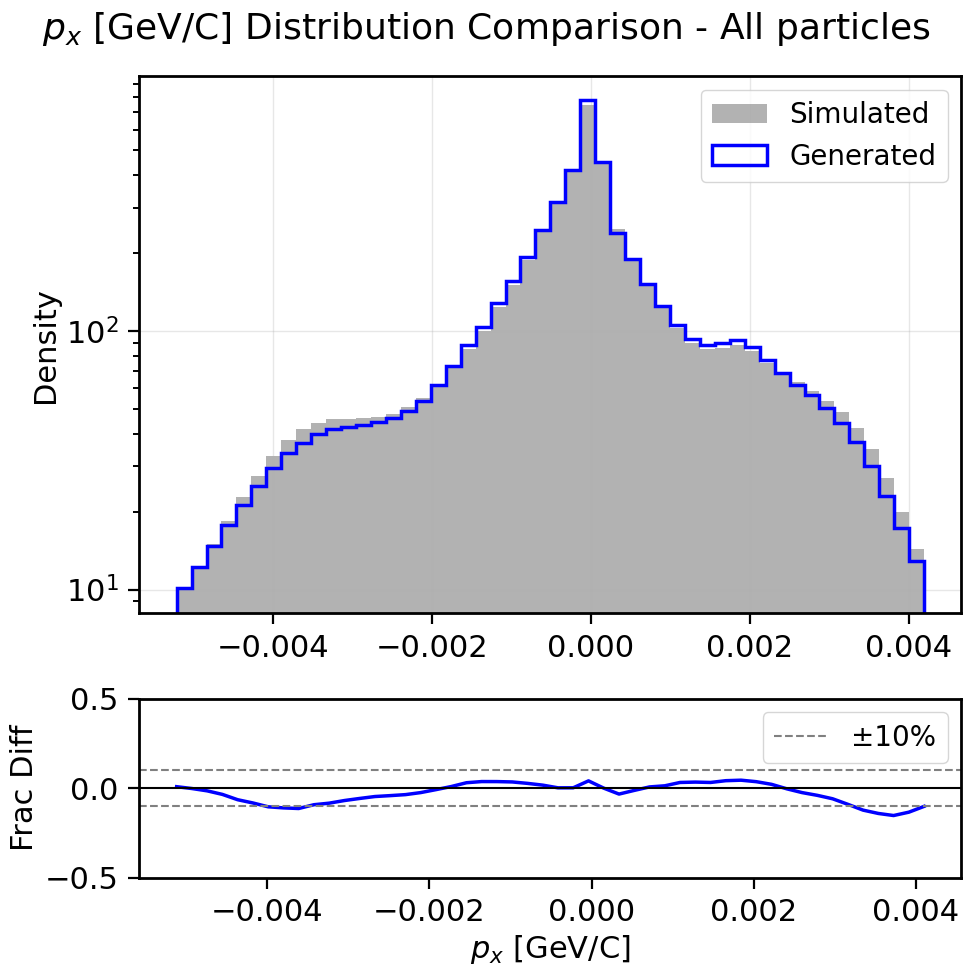

Statistics:
  Within ±10%: 42/50 (84.0%)
  Beyond ±10%: 8/50 (16.0%)

Comparing py distributions for step 200...


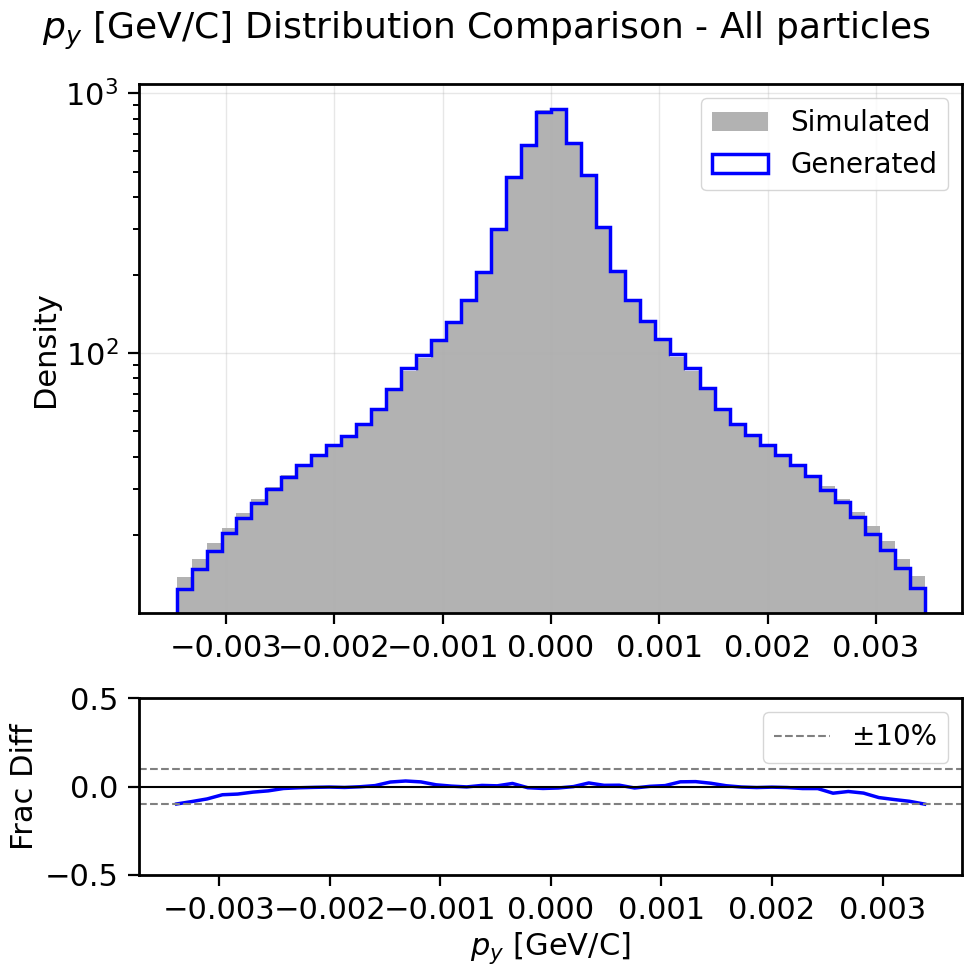

Statistics:
  Within ±10%: 50/50 (100.0%)
  Beyond ±10%: 0/50 (0.0%)

Comparing pz distributions for step 200...


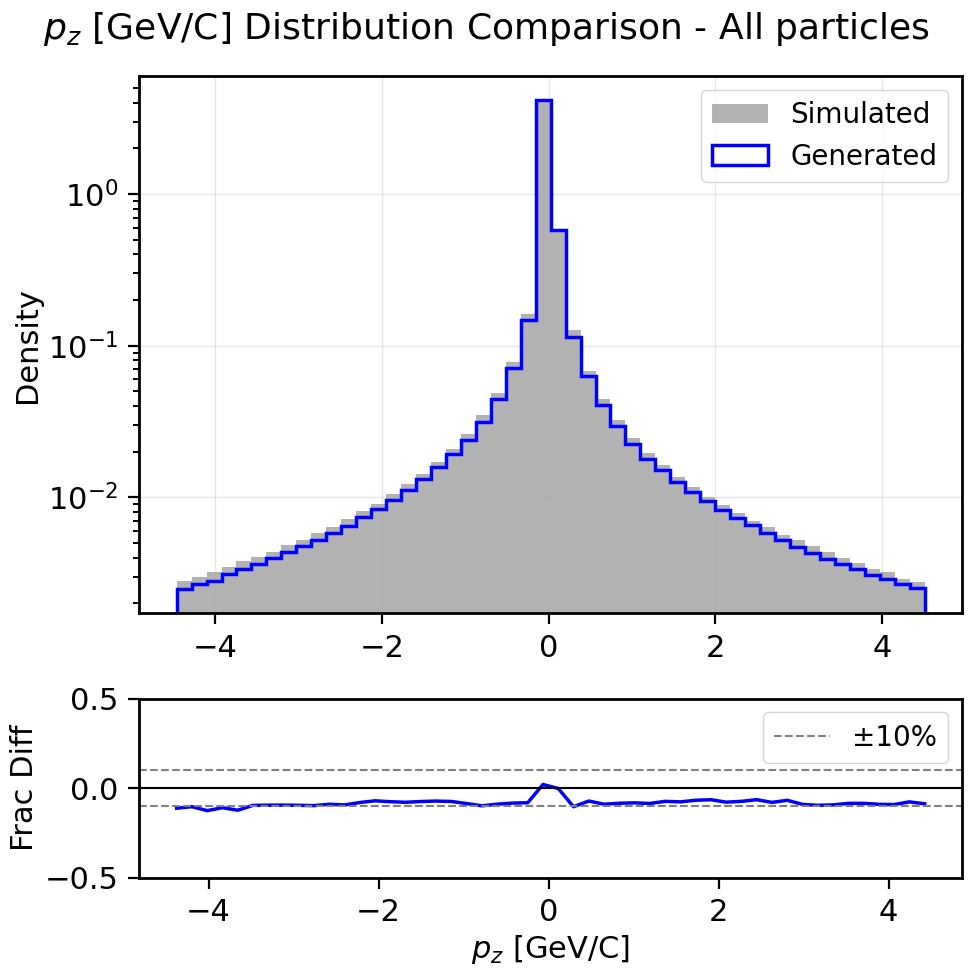

Statistics:
  Within ±10%: 44/50 (88.0%)
  Beyond ±10%: 6/50 (12.0%)

Comparing p distributions for step 200...


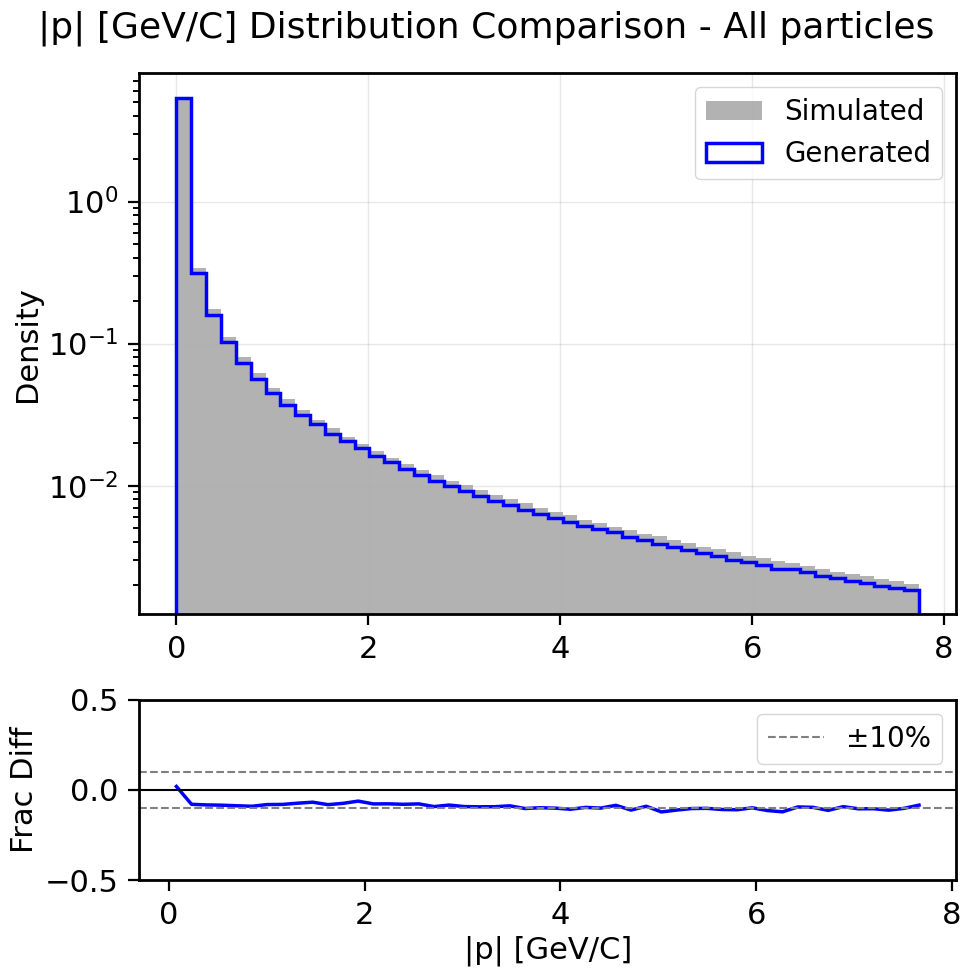

Statistics:
  Within ±10%: 32/50 (64.0%)
  Beyond ±10%: 18/50 (36.0%)

Comparing pt distributions for step 200...


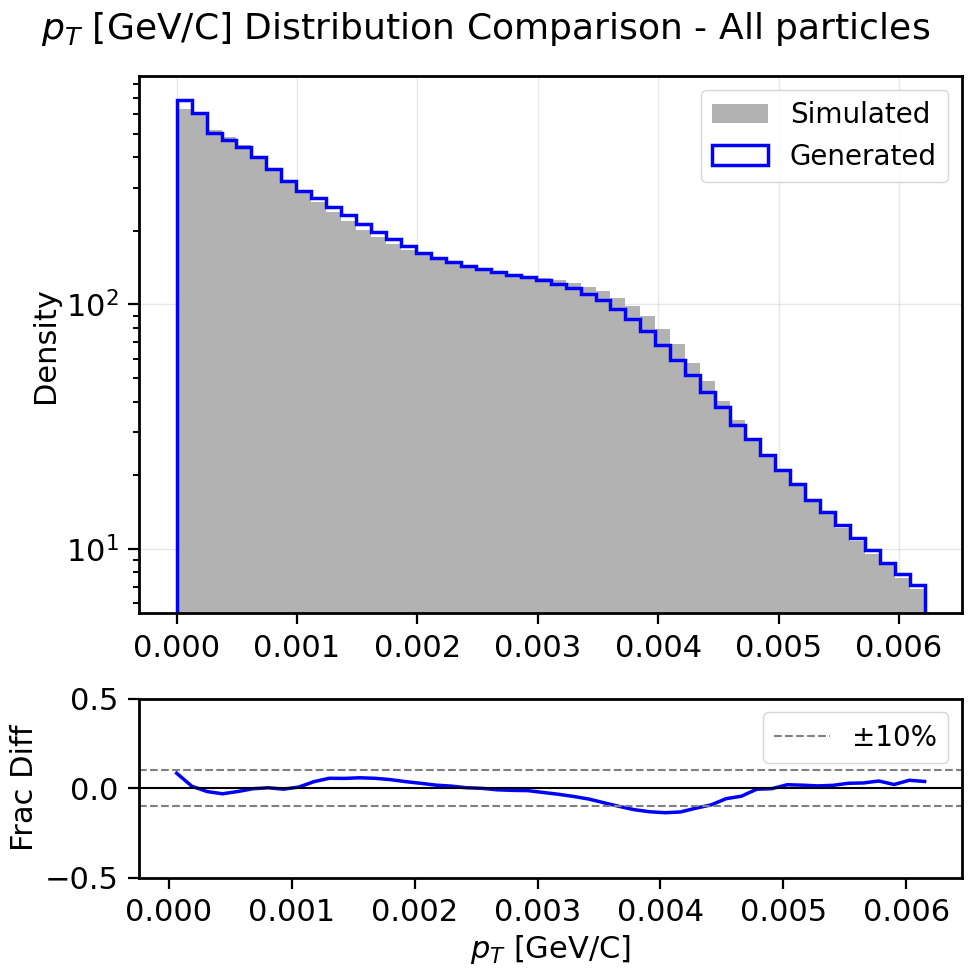

Statistics:
  Within ±10%: 44/50 (88.0%)
  Beyond ±10%: 6/50 (12.0%)

Comparing E distributions for step 200...


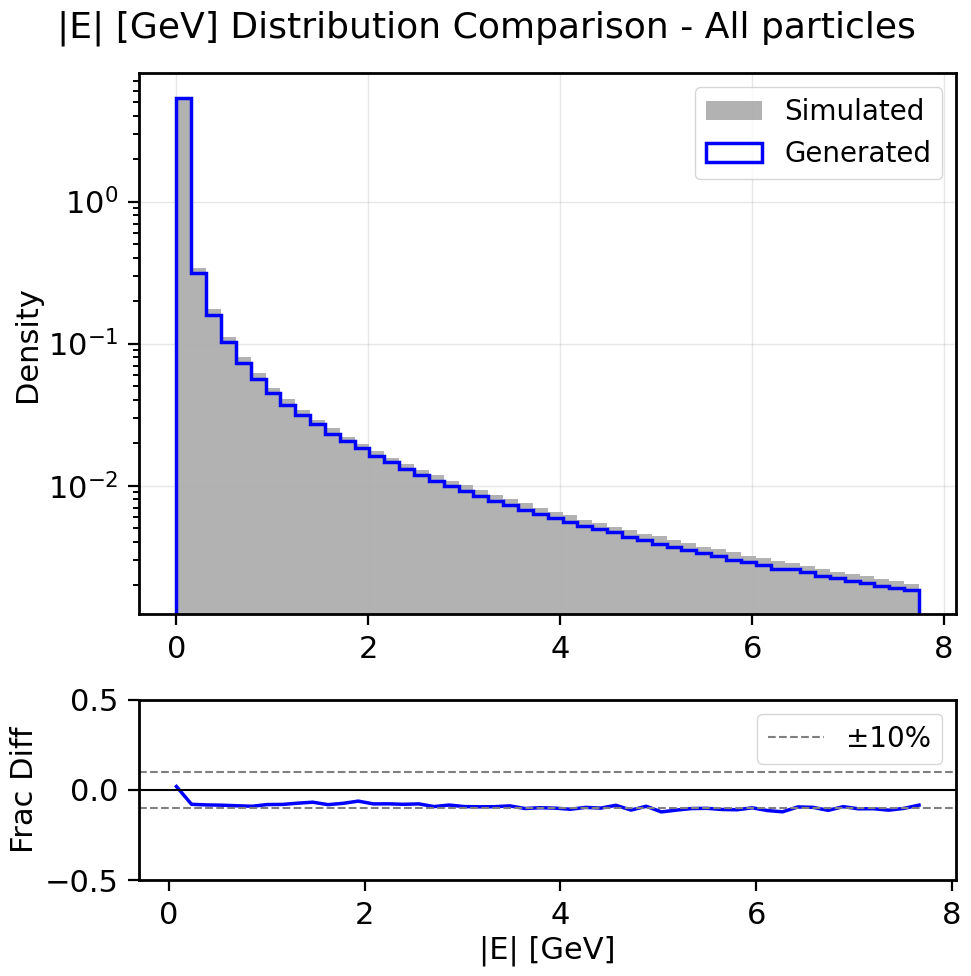

Statistics:
  Within ±10%: 32/50 (64.0%)
  Beyond ±10%: 18/50 (36.0%)

Comparing beta_mag distributions for step 200...


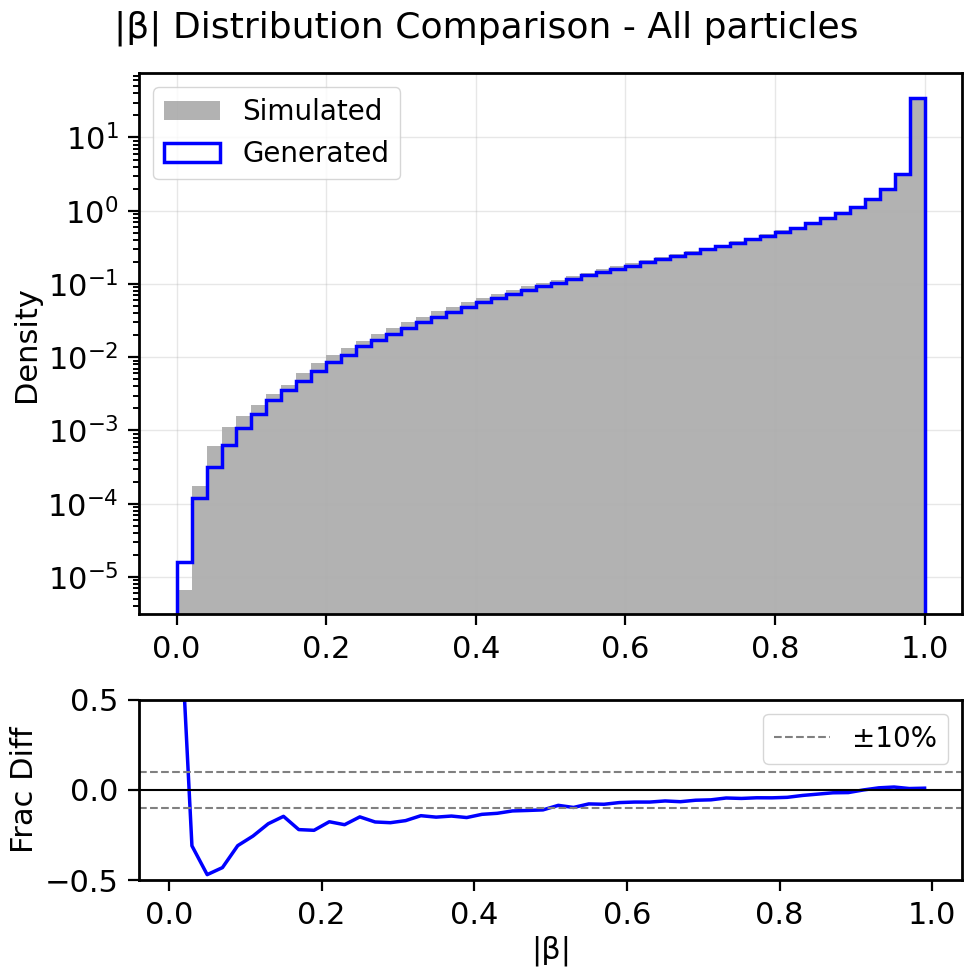

Statistics:
  Within ±10%: 25/50 (50.0%)
  Beyond ±10%: 25/50 (50.0%)

Comparing betax distributions for step 200...


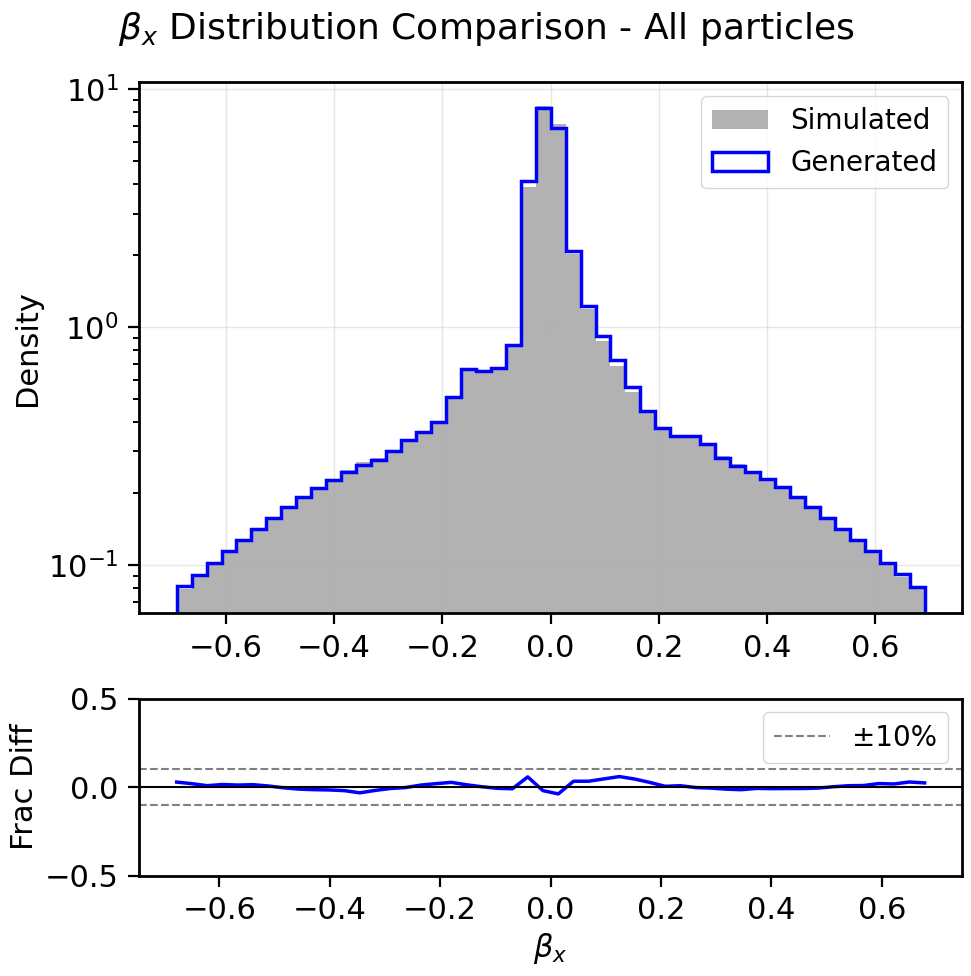

Statistics:
  Within ±10%: 50/50 (100.0%)
  Beyond ±10%: 0/50 (0.0%)

Comparing betay distributions for step 200...


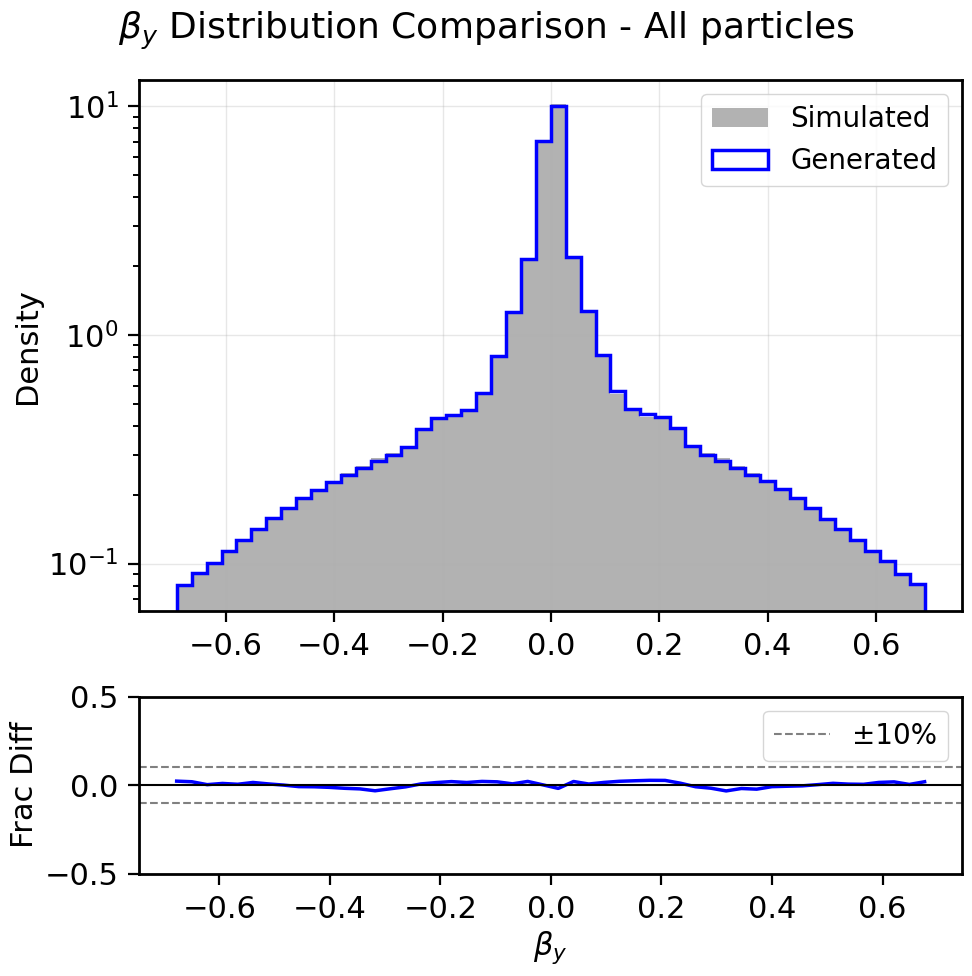

Statistics:
  Within ±10%: 50/50 (100.0%)
  Beyond ±10%: 0/50 (0.0%)

Comparing betaz distributions for step 200...


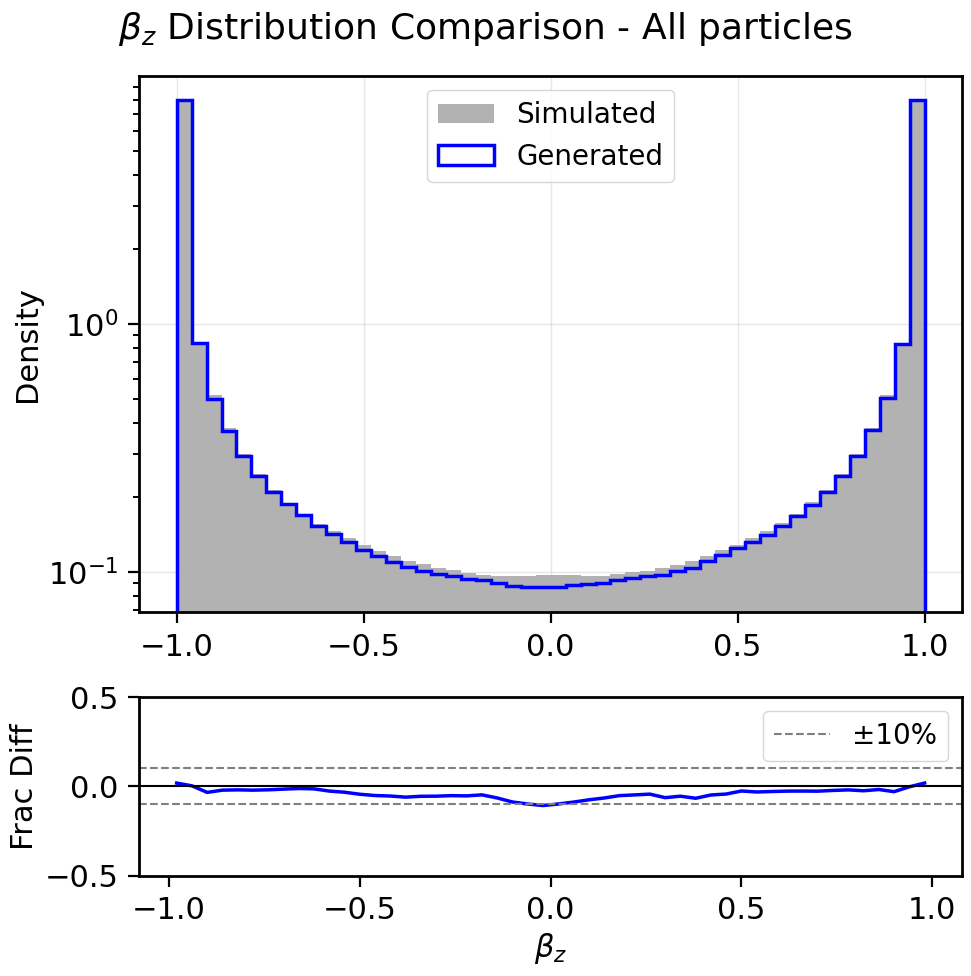

Statistics:
  Within ±10%: 49/50 (98.0%)
  Beyond ±10%: 1/50 (2.0%)

Comparing x distributions for step 200...


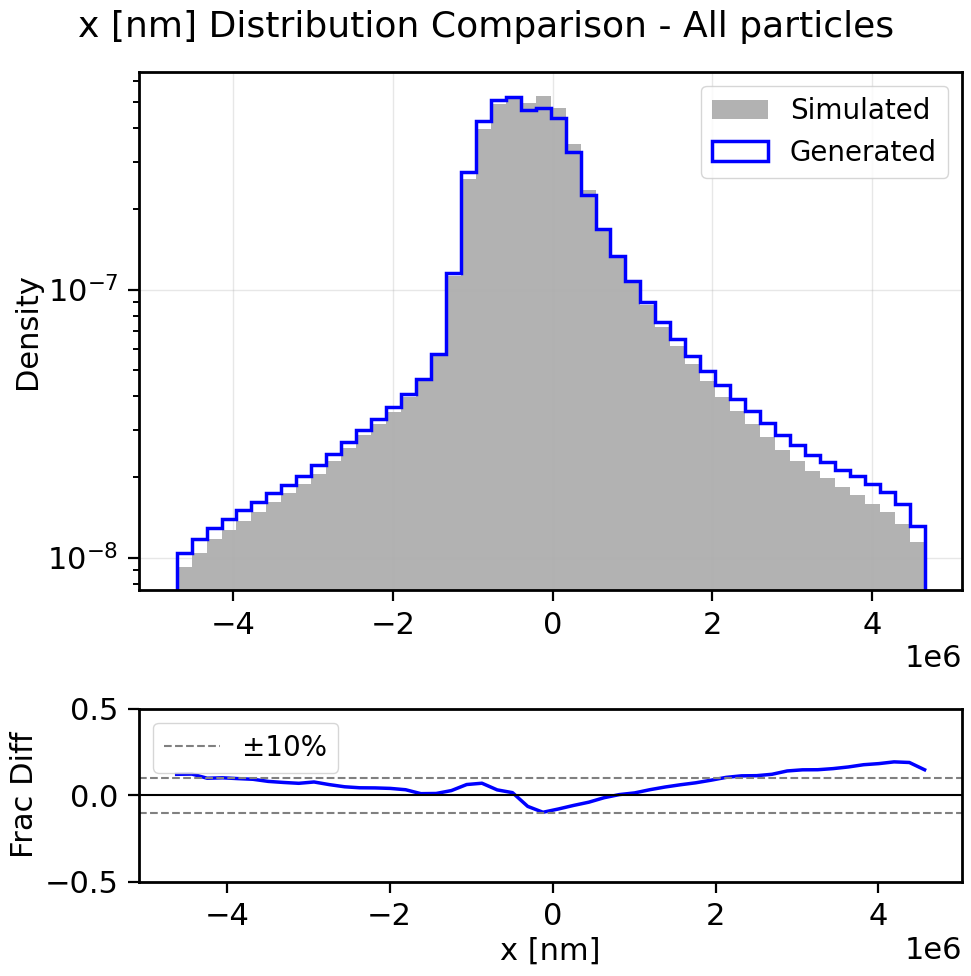

Statistics:
  Within ±10%: 33/50 (66.0%)
  Beyond ±10%: 17/50 (34.0%)

Comparing y distributions for step 200...


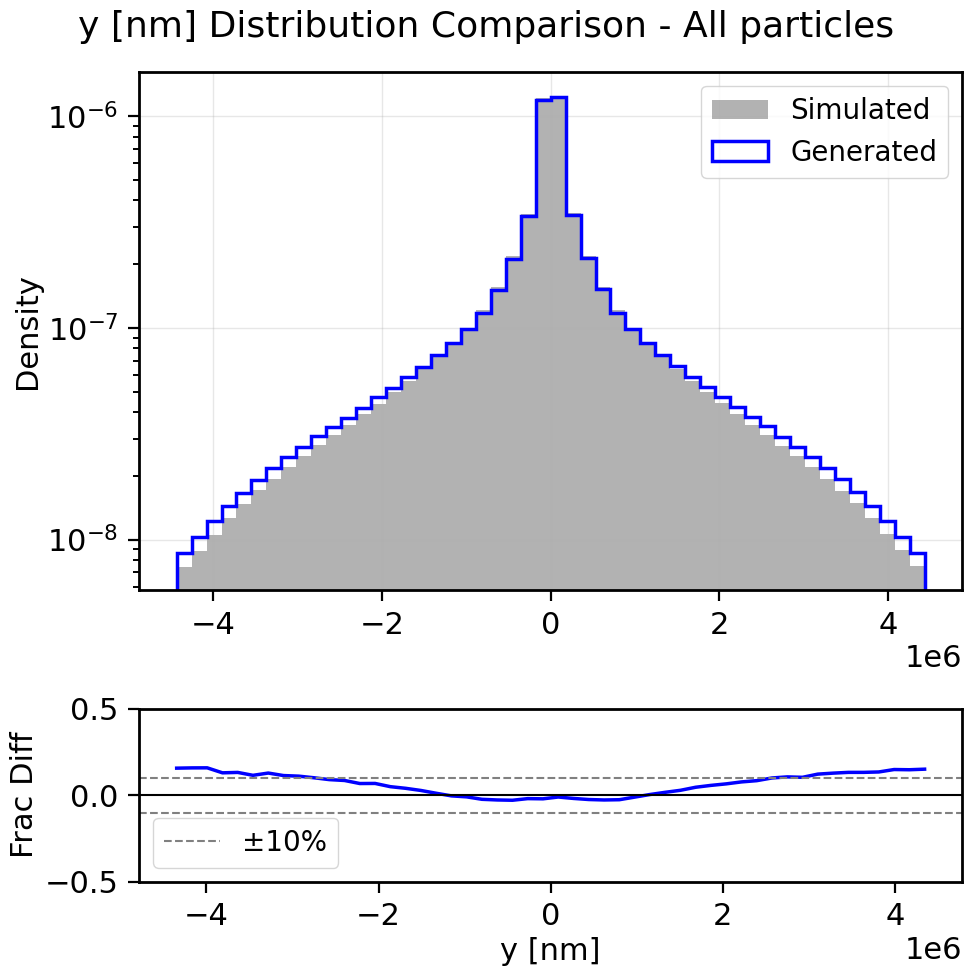

Statistics:
  Within ±10%: 30/50 (60.0%)
  Beyond ±10%: 20/50 (40.0%)

Comparing z distributions for step 200...


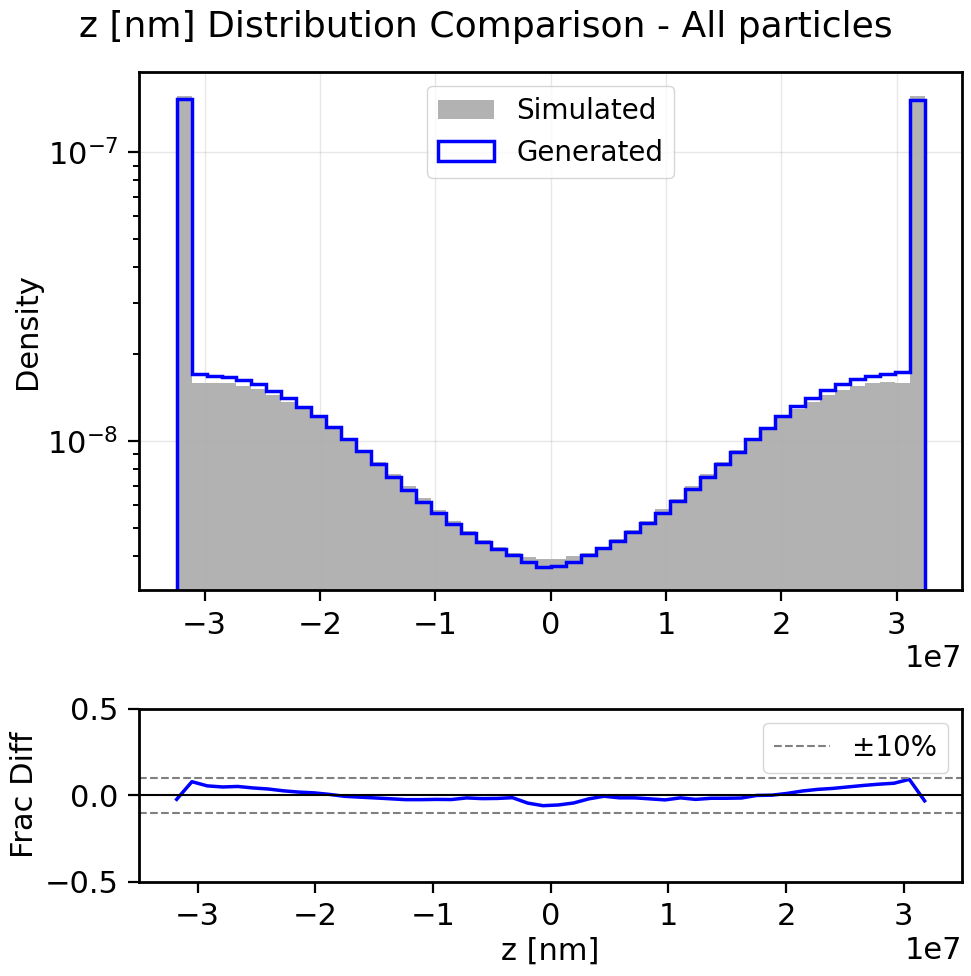

Statistics:
  Within ±10%: 50/50 (100.0%)
  Beyond ±10%: 0/50 (0.0%)

Comparing px distributions for step 200...


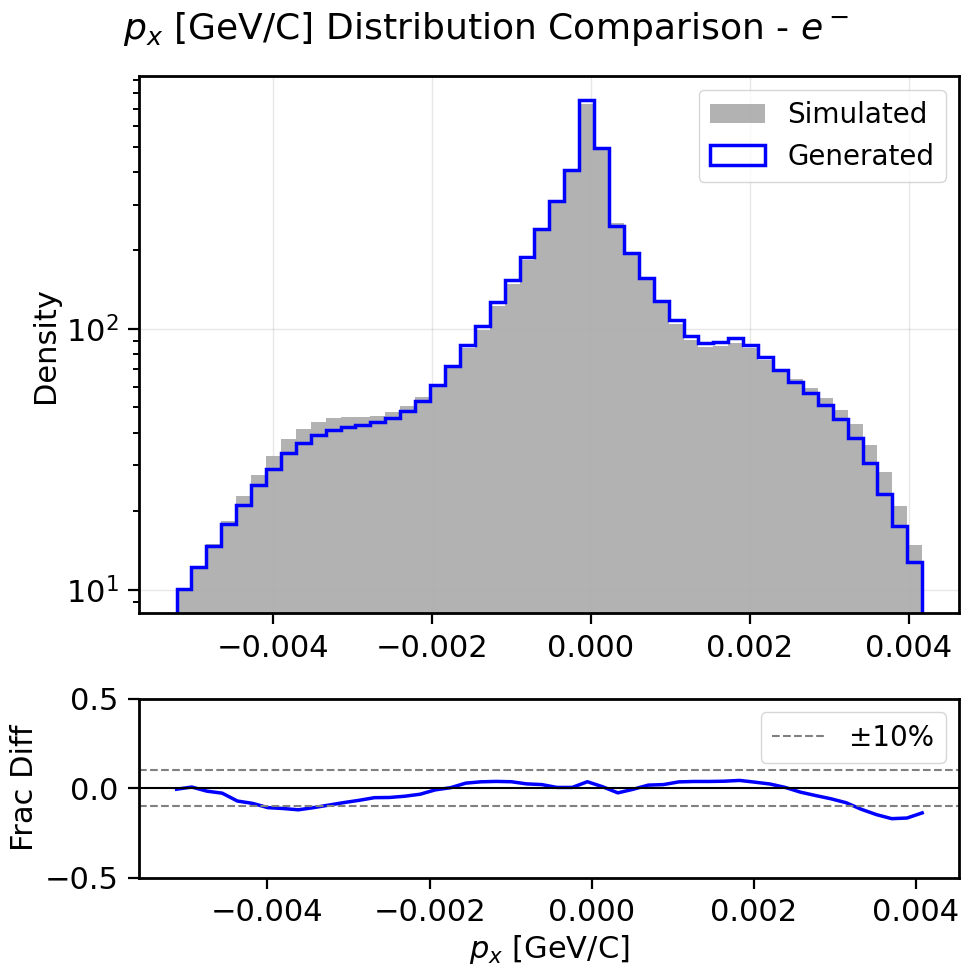

Statistics:
  Within ±10%: 41/50 (82.0%)
  Beyond ±10%: 9/50 (18.0%)

Comparing py distributions for step 200...


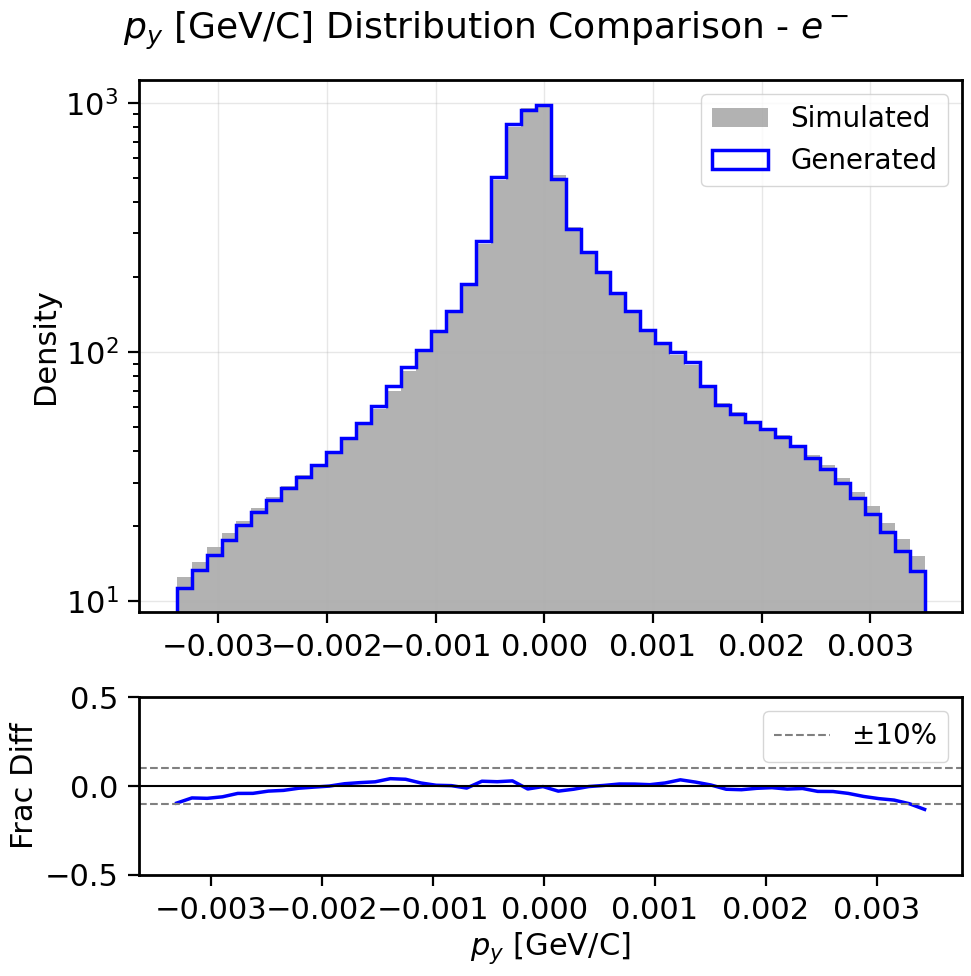

Statistics:
  Within ±10%: 49/50 (98.0%)
  Beyond ±10%: 1/50 (2.0%)

Comparing pz distributions for step 200...


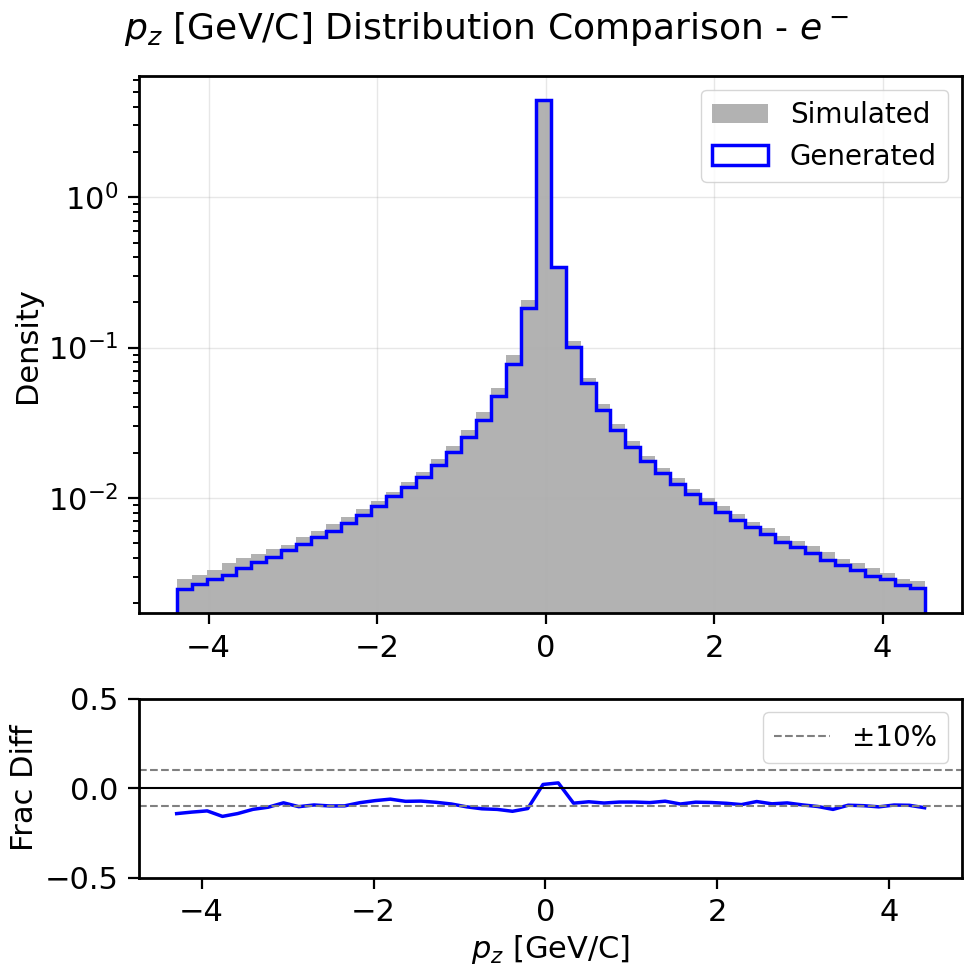

Statistics:
  Within ±10%: 33/50 (66.0%)
  Beyond ±10%: 17/50 (34.0%)

Comparing p distributions for step 200...


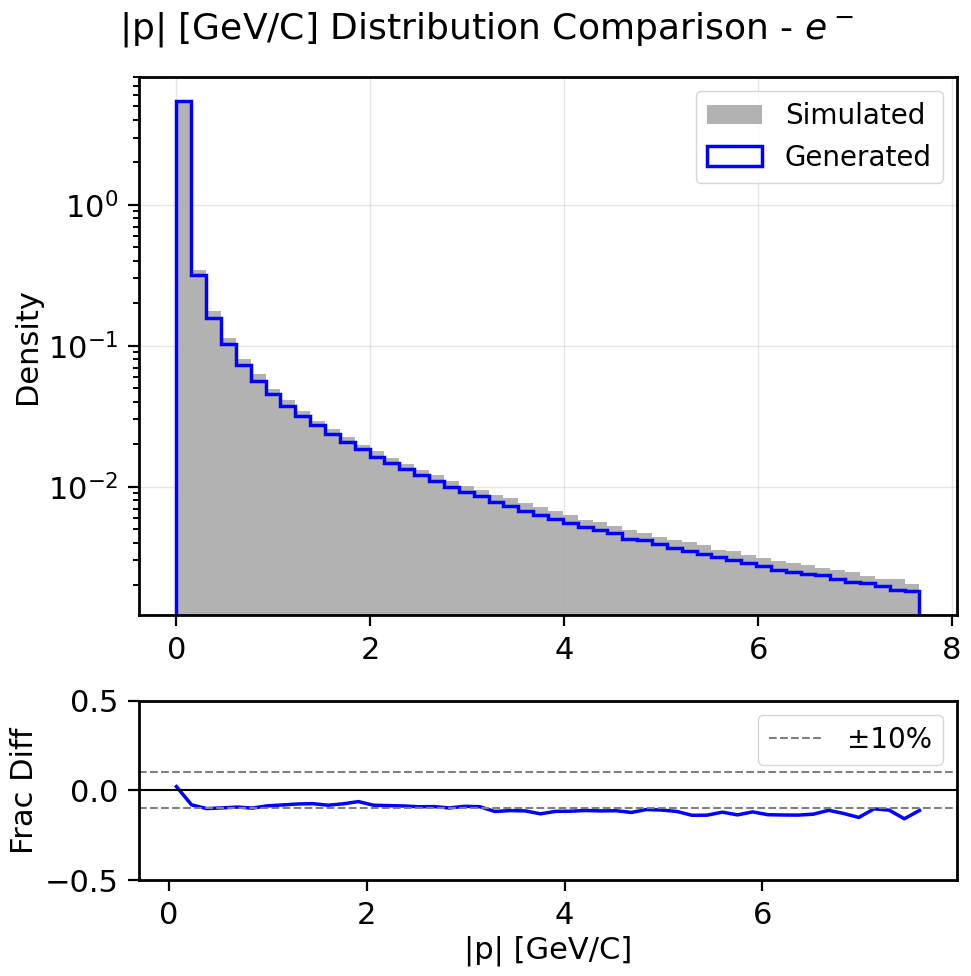

Statistics:
  Within ±10%: 20/50 (40.0%)
  Beyond ±10%: 30/50 (60.0%)

Comparing pt distributions for step 200...


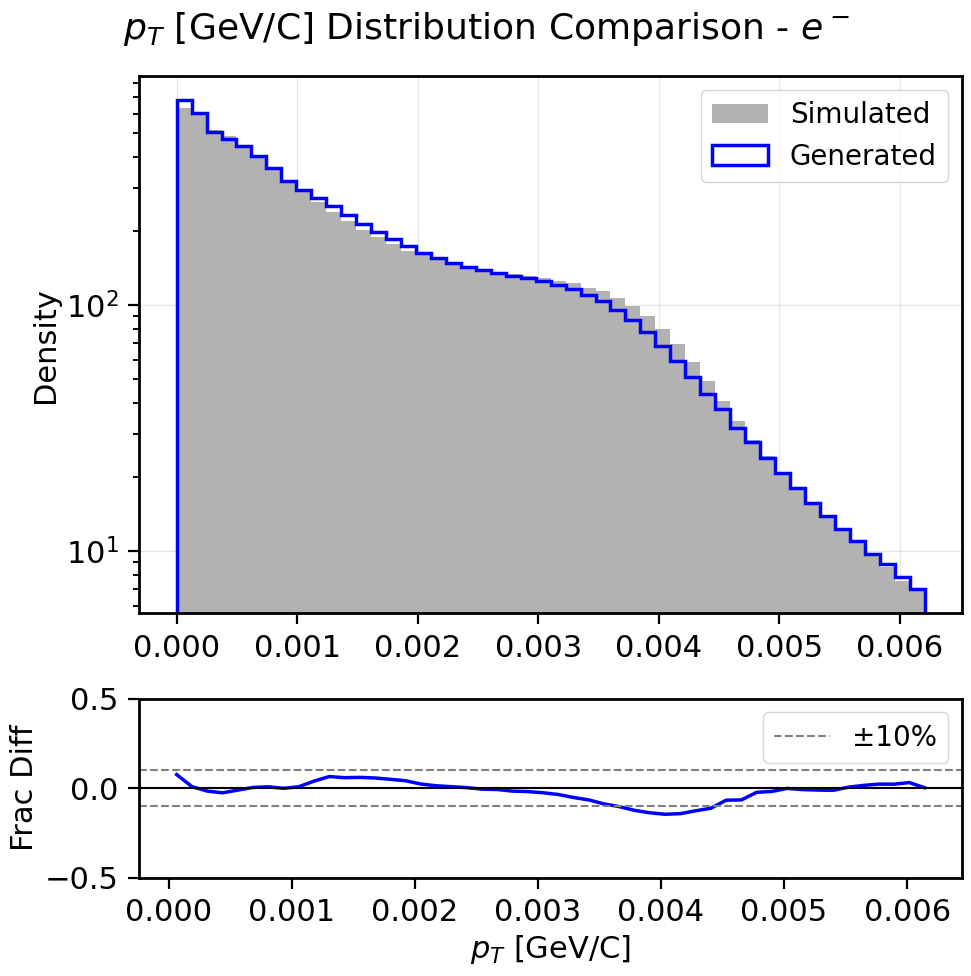

Statistics:
  Within ±10%: 43/50 (86.0%)
  Beyond ±10%: 7/50 (14.0%)

Comparing E distributions for step 200...


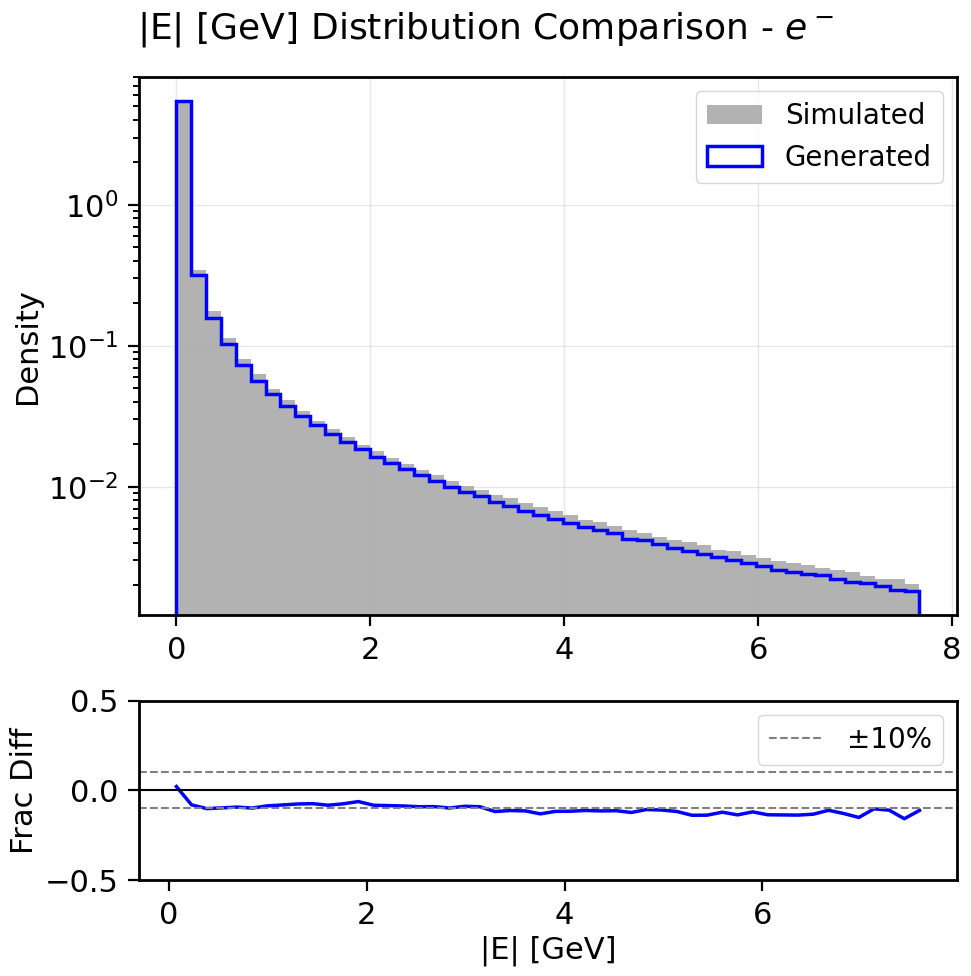

Statistics:
  Within ±10%: 20/50 (40.0%)
  Beyond ±10%: 30/50 (60.0%)

Comparing beta_mag distributions for step 200...


/tmp/ipykernel_818841/4179346651.py:83: RuntimeWarning: divide by zero encountered in divide
  frac_diff = np.where(real_hist > 0, (gen_hist - real_hist) / real_hist, 0)


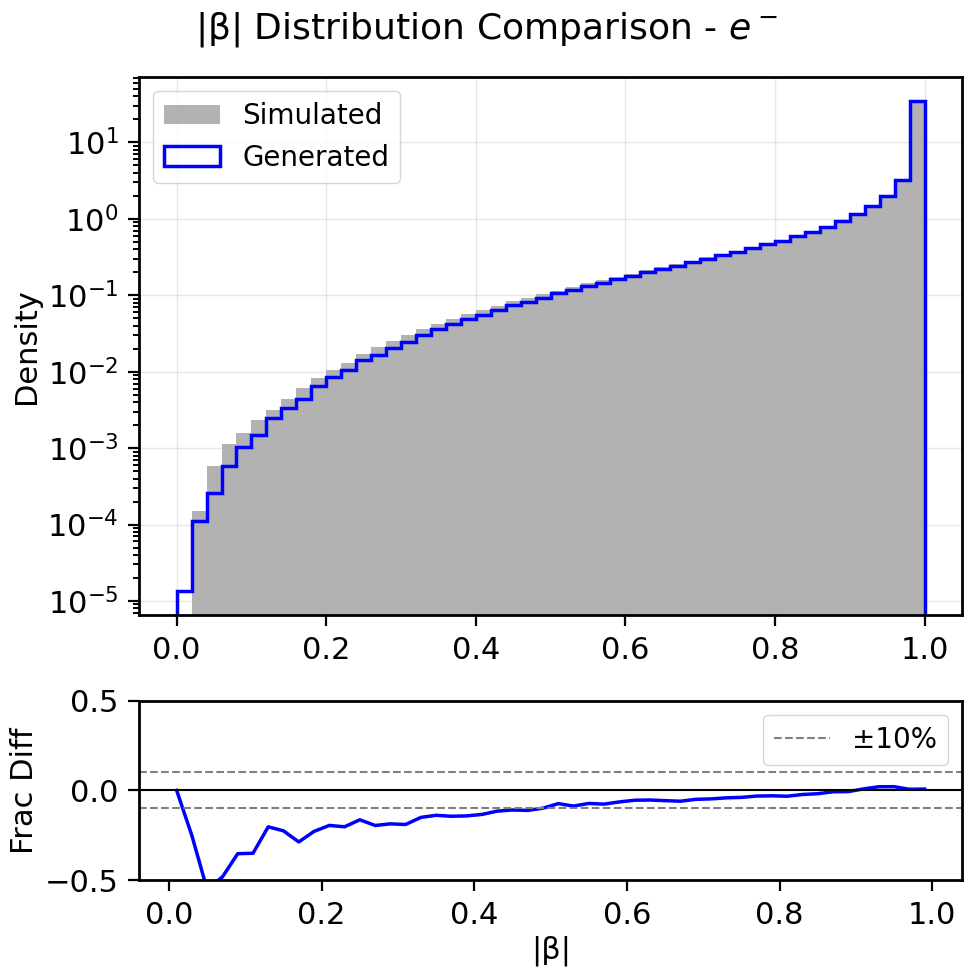

Statistics:
  Within ±10%: 27/50 (54.0%)
  Beyond ±10%: 23/50 (46.0%)

Comparing betax distributions for step 200...


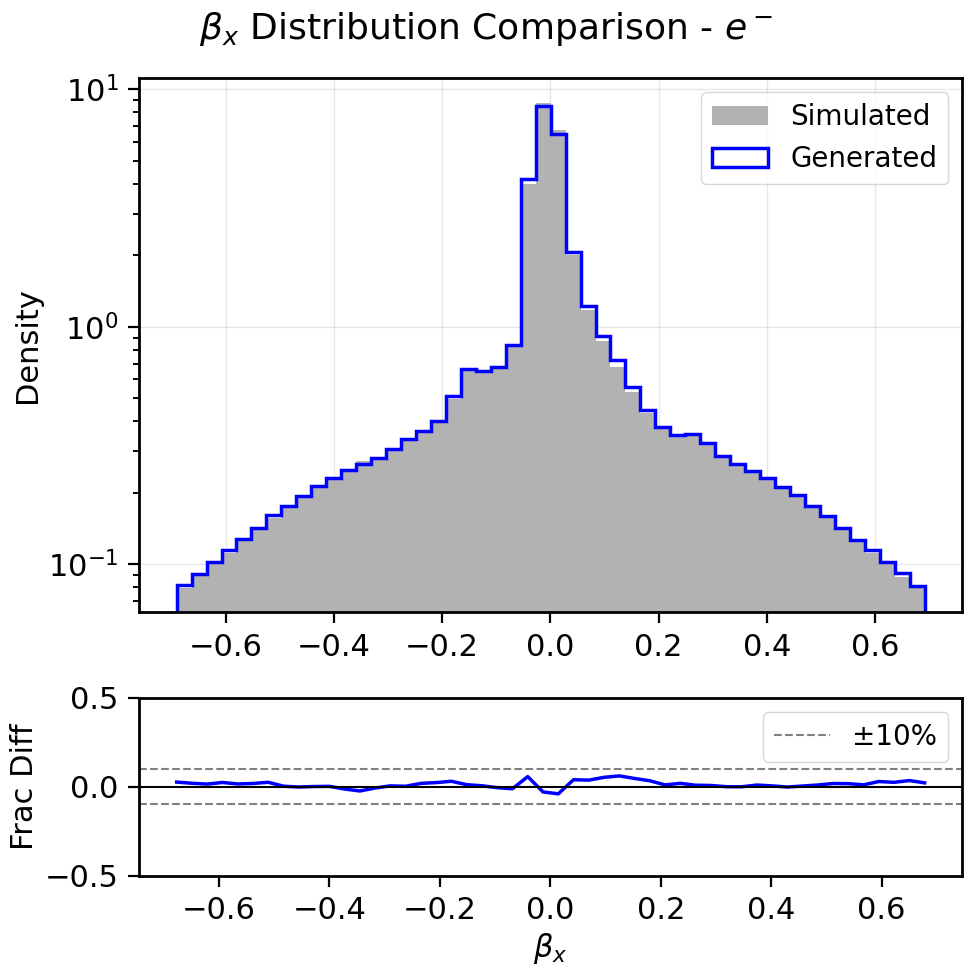

Statistics:
  Within ±10%: 50/50 (100.0%)
  Beyond ±10%: 0/50 (0.0%)

Comparing betay distributions for step 200...


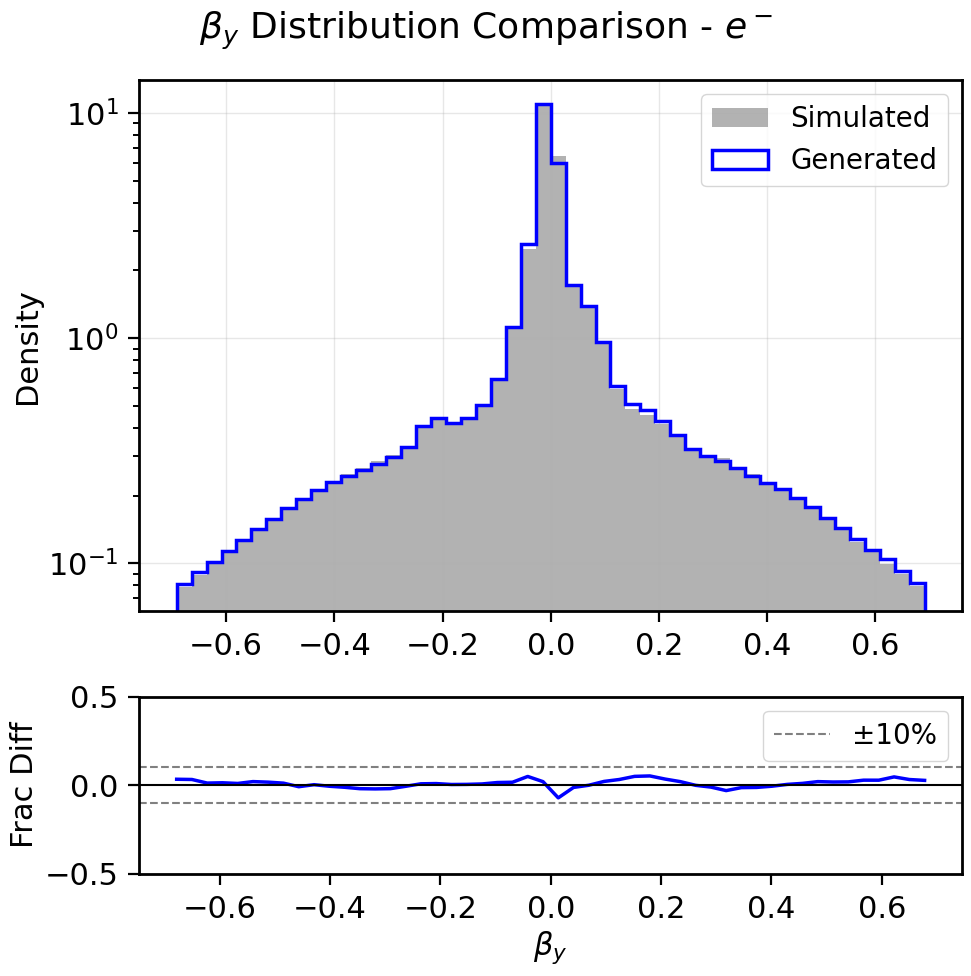

Statistics:
  Within ±10%: 50/50 (100.0%)
  Beyond ±10%: 0/50 (0.0%)

Comparing betaz distributions for step 200...


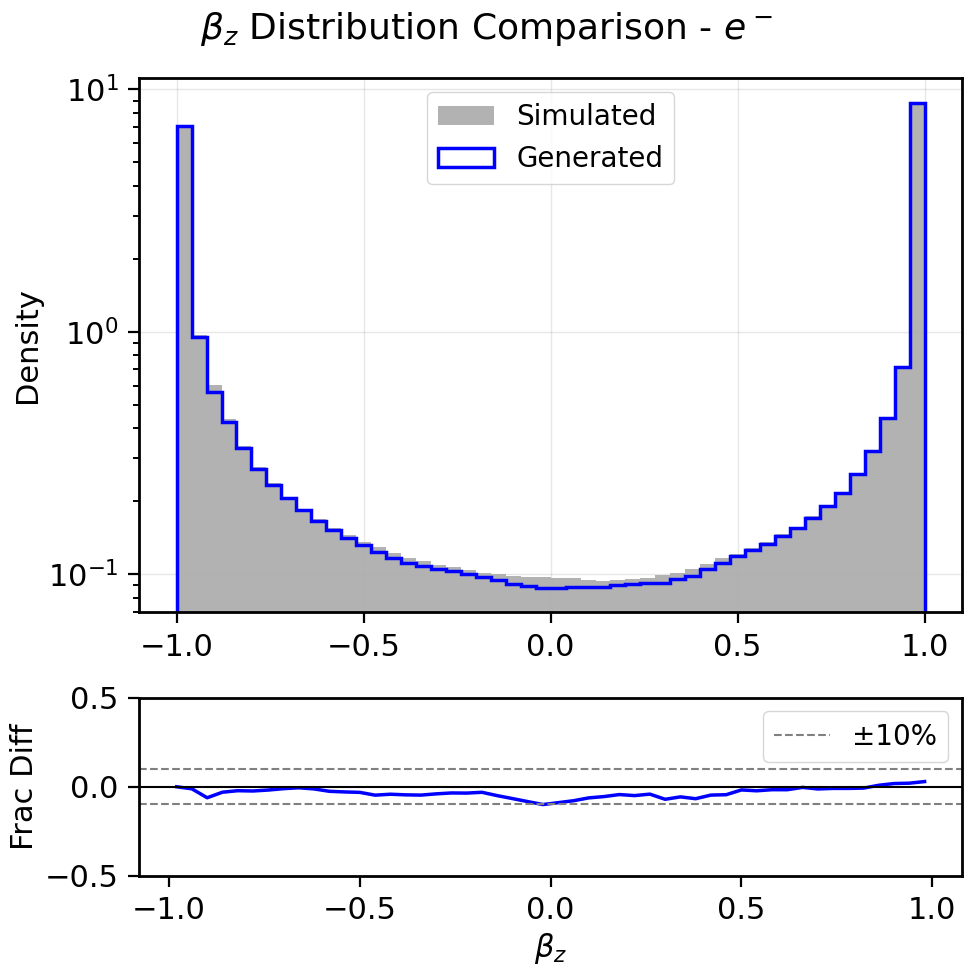

Statistics:
  Within ±10%: 49/50 (98.0%)
  Beyond ±10%: 1/50 (2.0%)

Comparing x distributions for step 200...


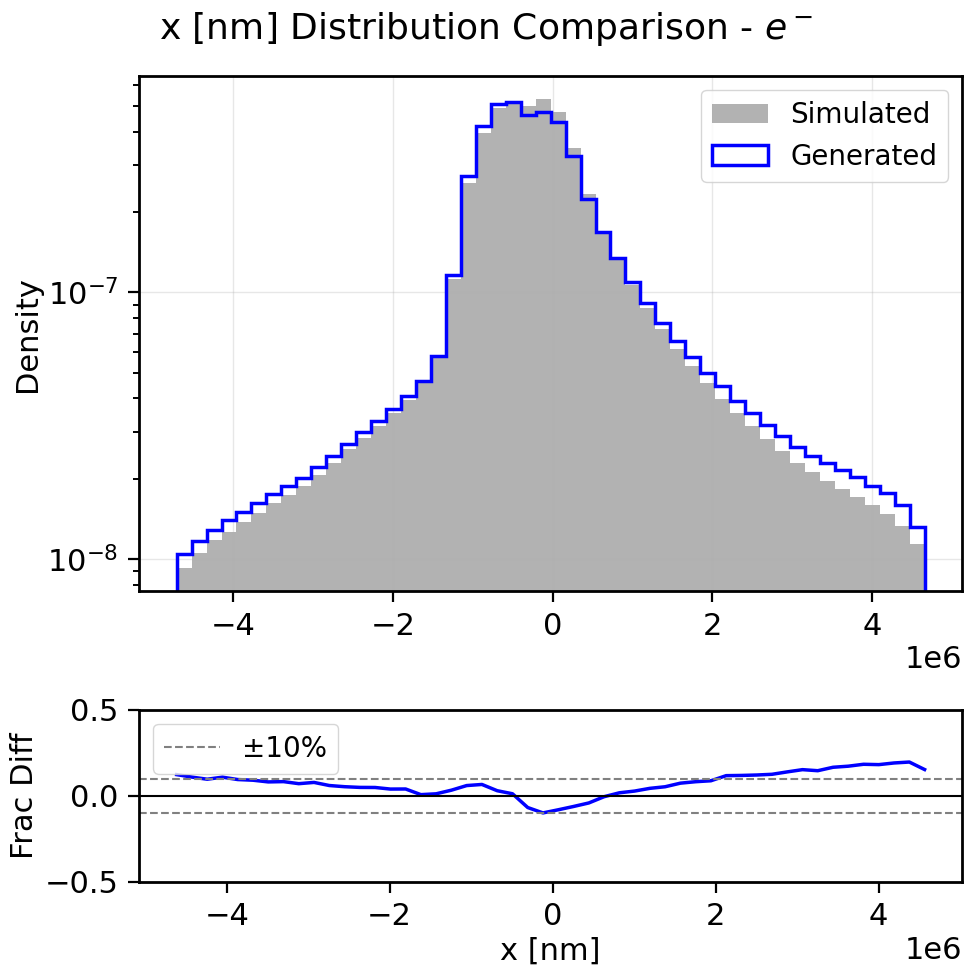

Statistics:
  Within ±10%: 32/50 (64.0%)
  Beyond ±10%: 18/50 (36.0%)

Comparing y distributions for step 200...


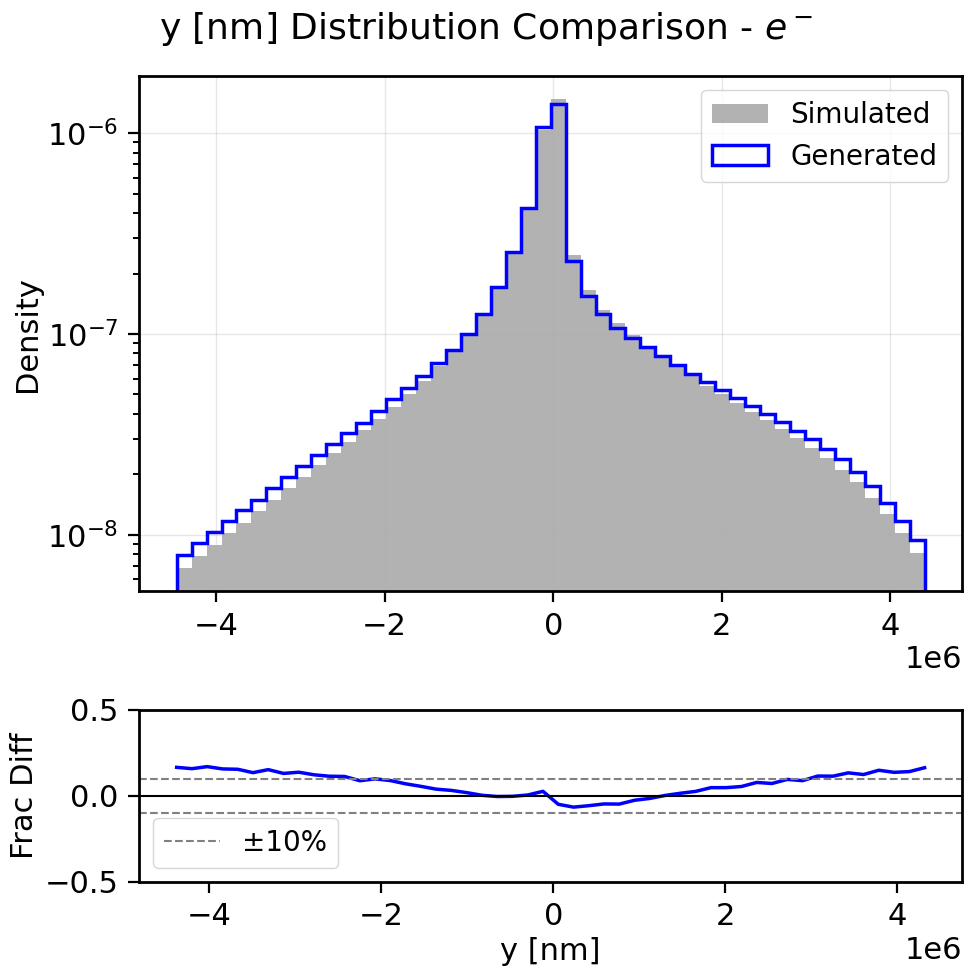

Statistics:
  Within ±10%: 30/50 (60.0%)
  Beyond ±10%: 20/50 (40.0%)

Comparing z distributions for step 200...


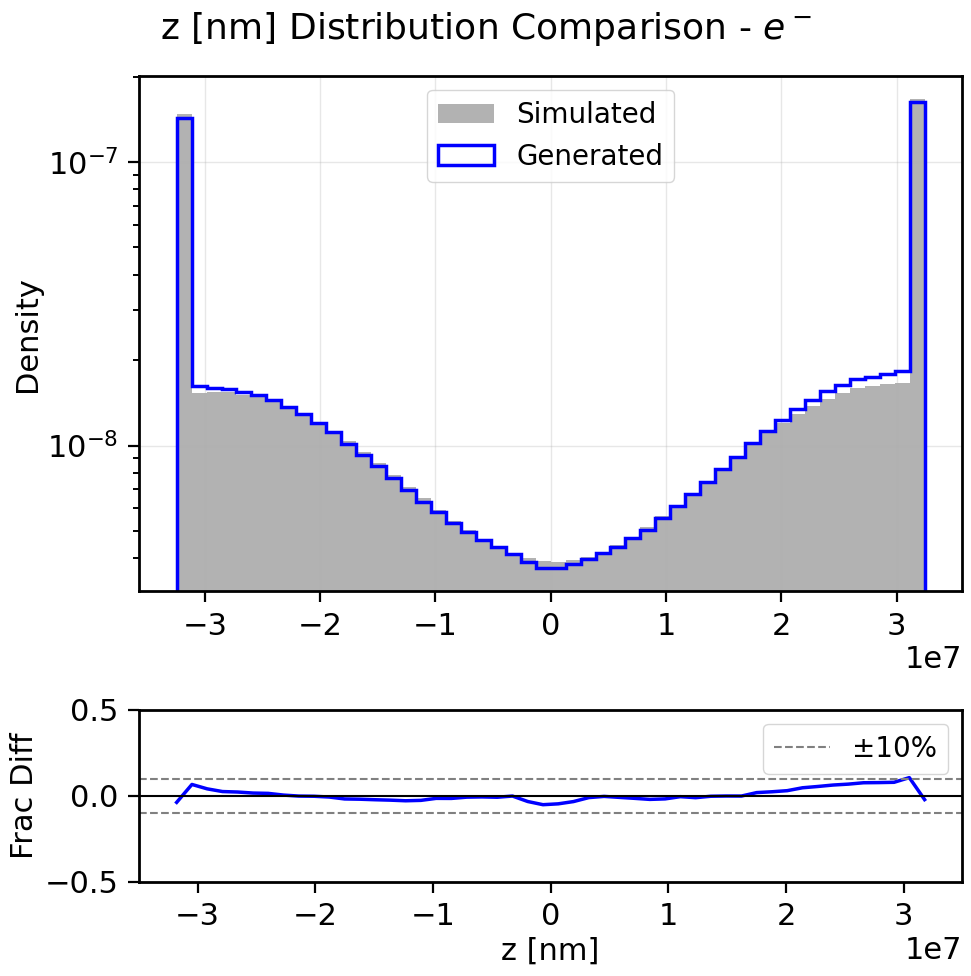

Statistics:
  Within ±10%: 49/50 (98.0%)
  Beyond ±10%: 1/50 (2.0%)

Comparing px distributions for step 200...


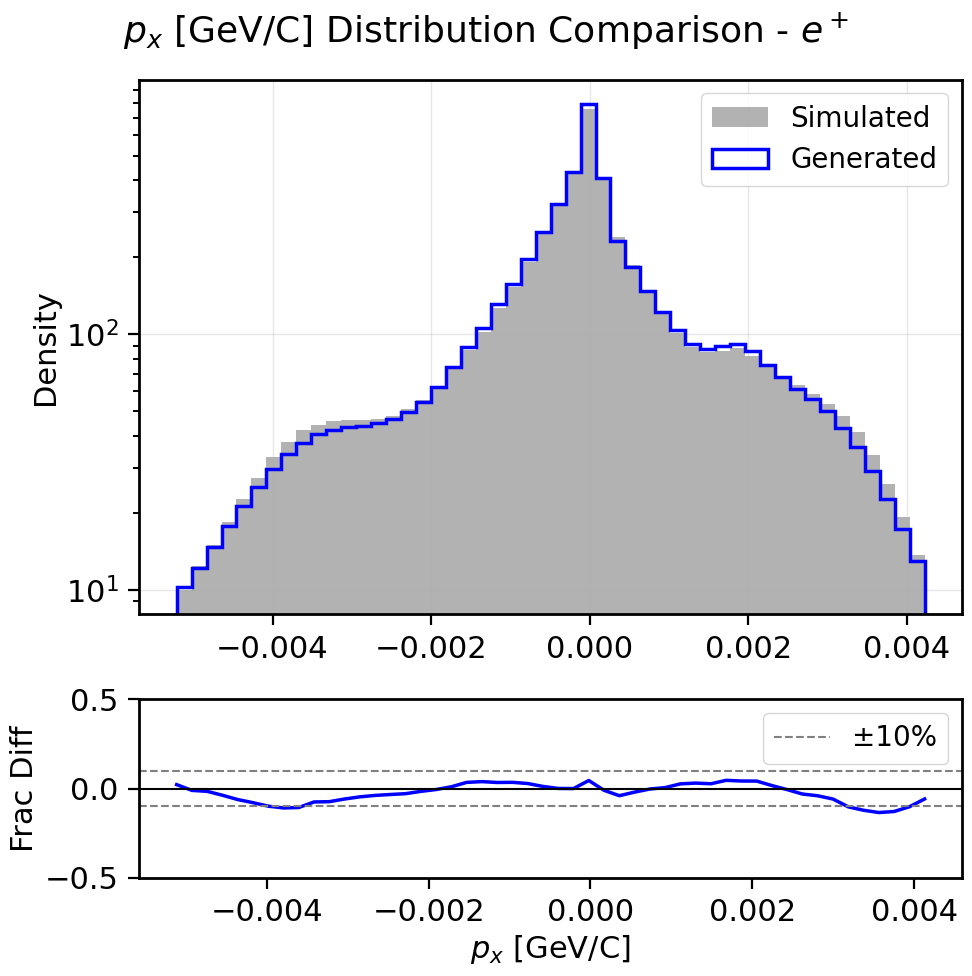

Statistics:
  Within ±10%: 43/50 (86.0%)
  Beyond ±10%: 7/50 (14.0%)

Comparing py distributions for step 200...


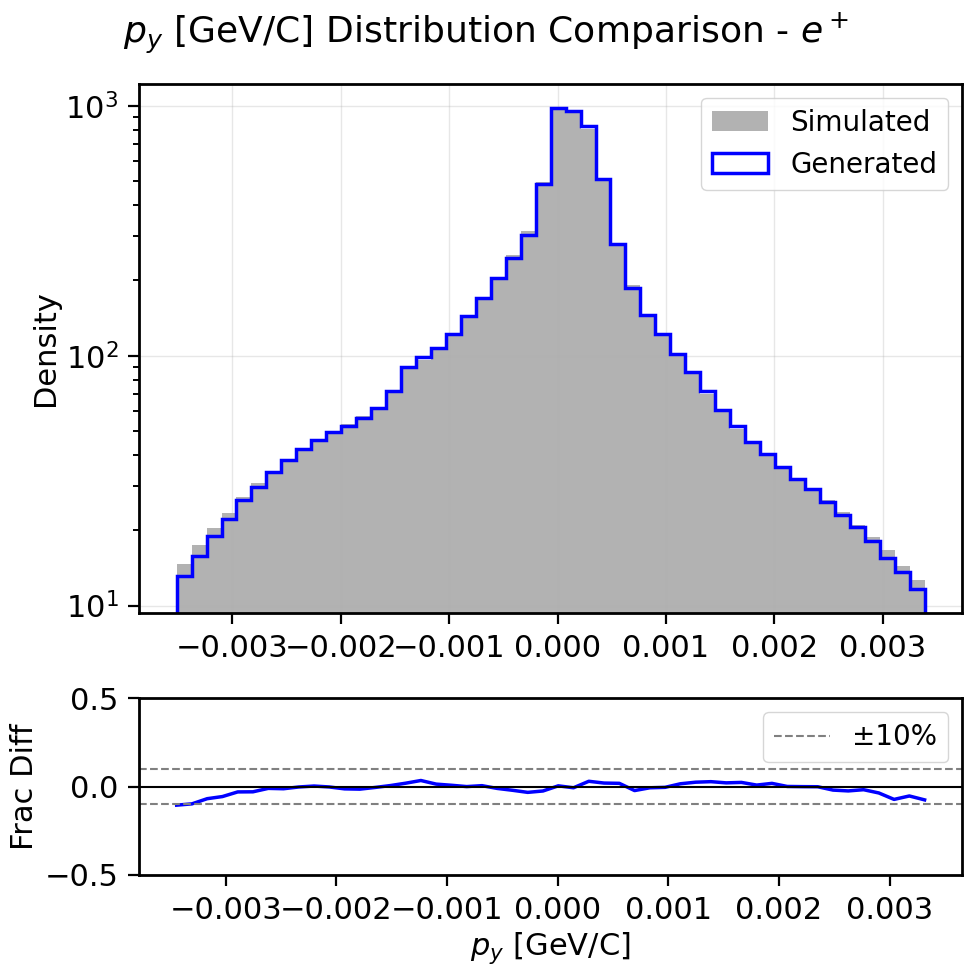

Statistics:
  Within ±10%: 49/50 (98.0%)
  Beyond ±10%: 1/50 (2.0%)

Comparing pz distributions for step 200...


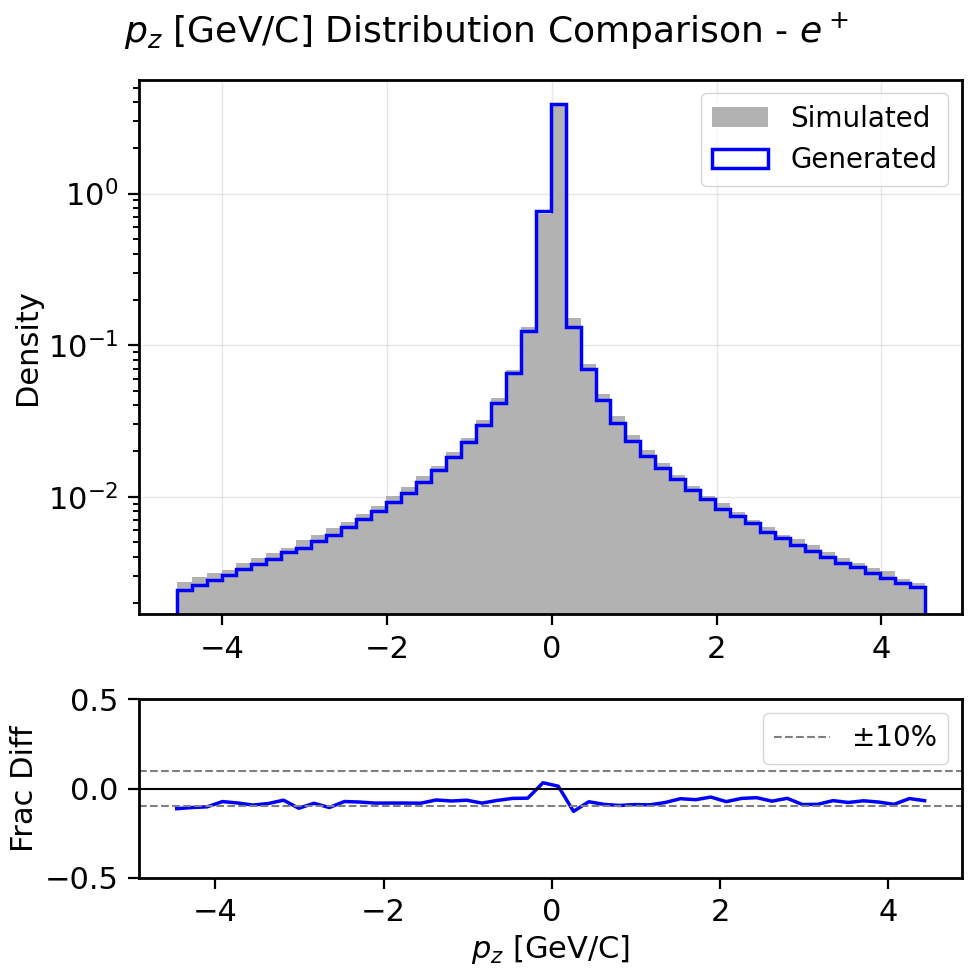

Statistics:
  Within ±10%: 44/50 (88.0%)
  Beyond ±10%: 6/50 (12.0%)

Comparing p distributions for step 200...


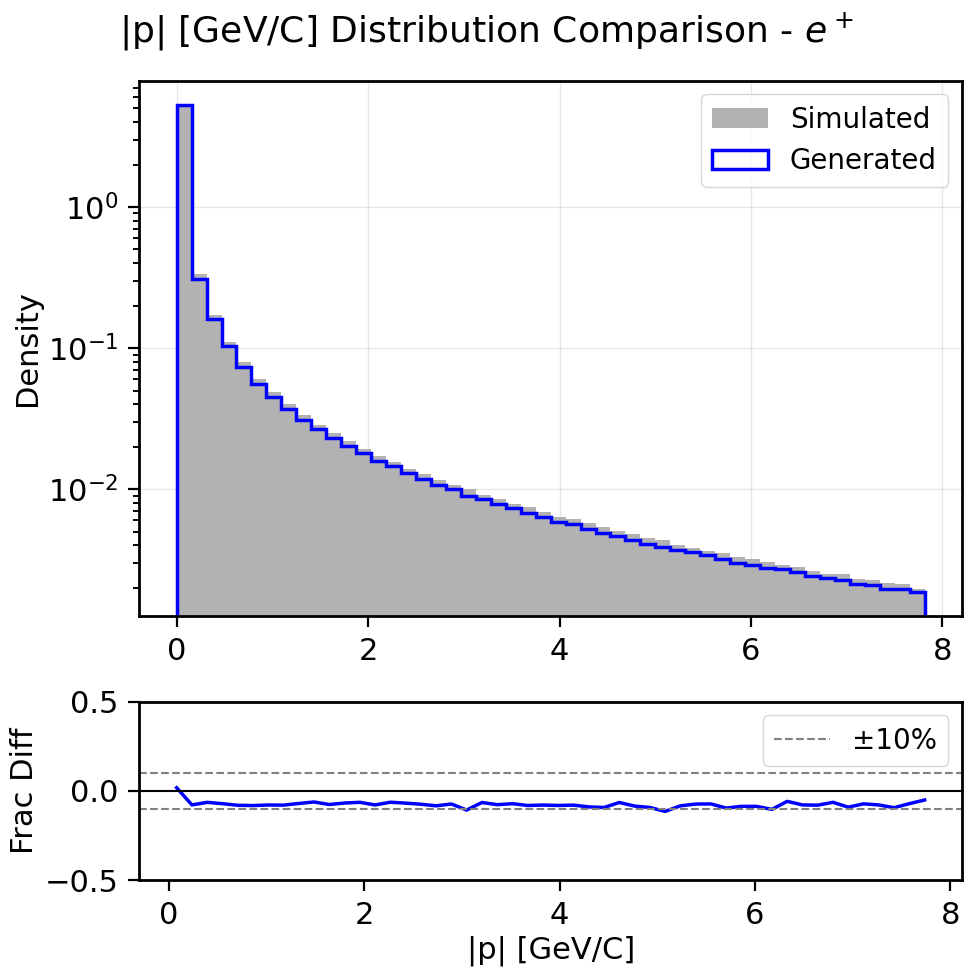

Statistics:
  Within ±10%: 47/50 (94.0%)
  Beyond ±10%: 3/50 (6.0%)

Comparing pt distributions for step 200...


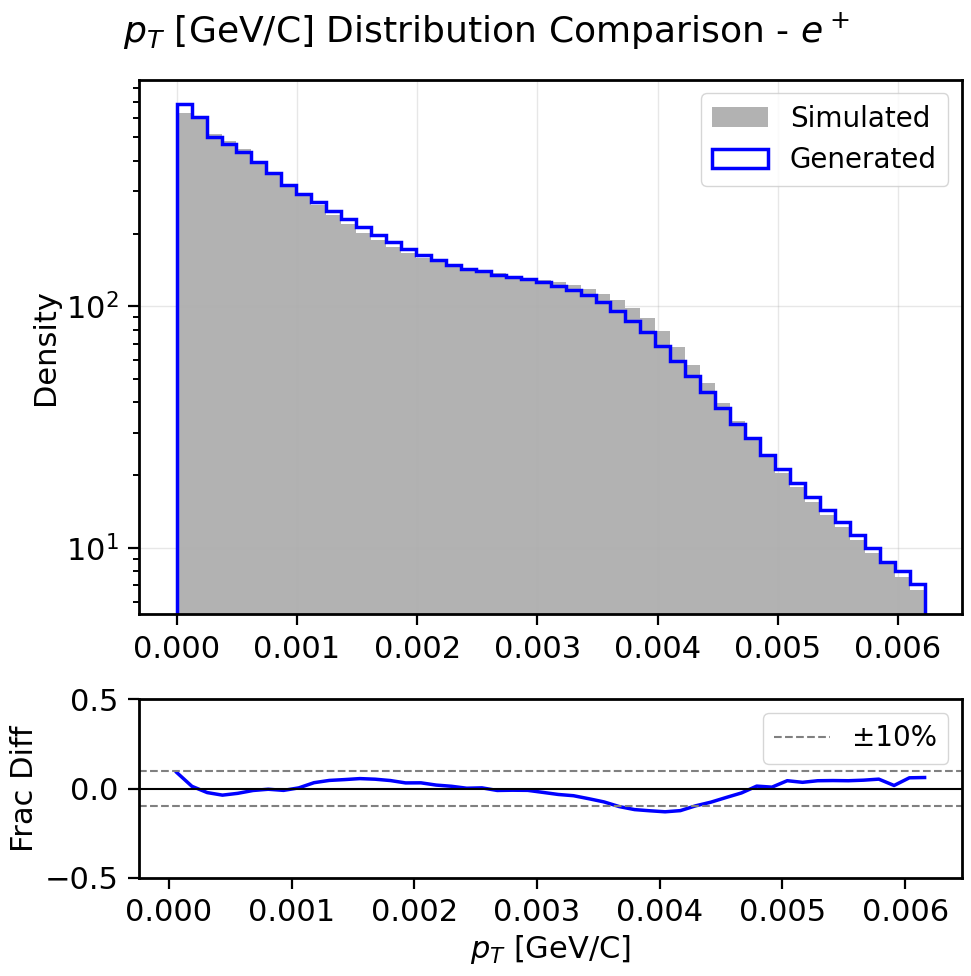

Statistics:
  Within ±10%: 45/50 (90.0%)
  Beyond ±10%: 5/50 (10.0%)

Comparing E distributions for step 200...


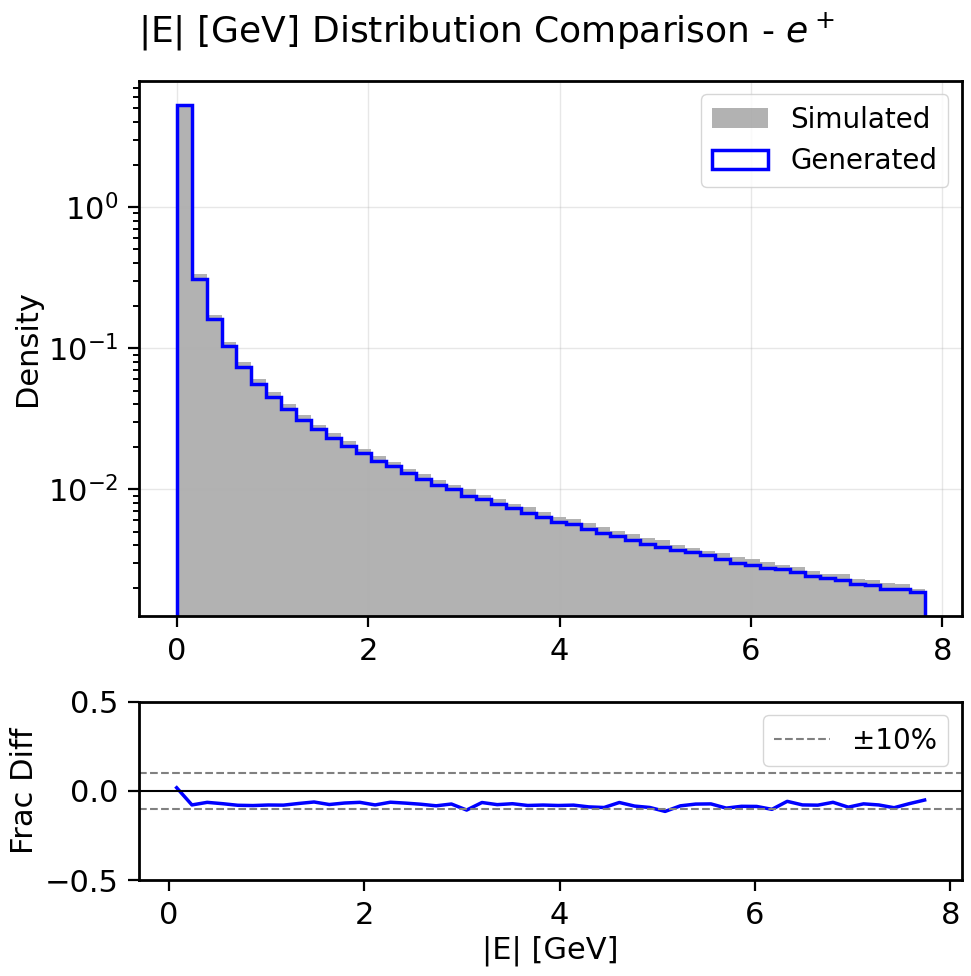

Statistics:
  Within ±10%: 47/50 (94.0%)
  Beyond ±10%: 3/50 (6.0%)

Comparing beta_mag distributions for step 200...


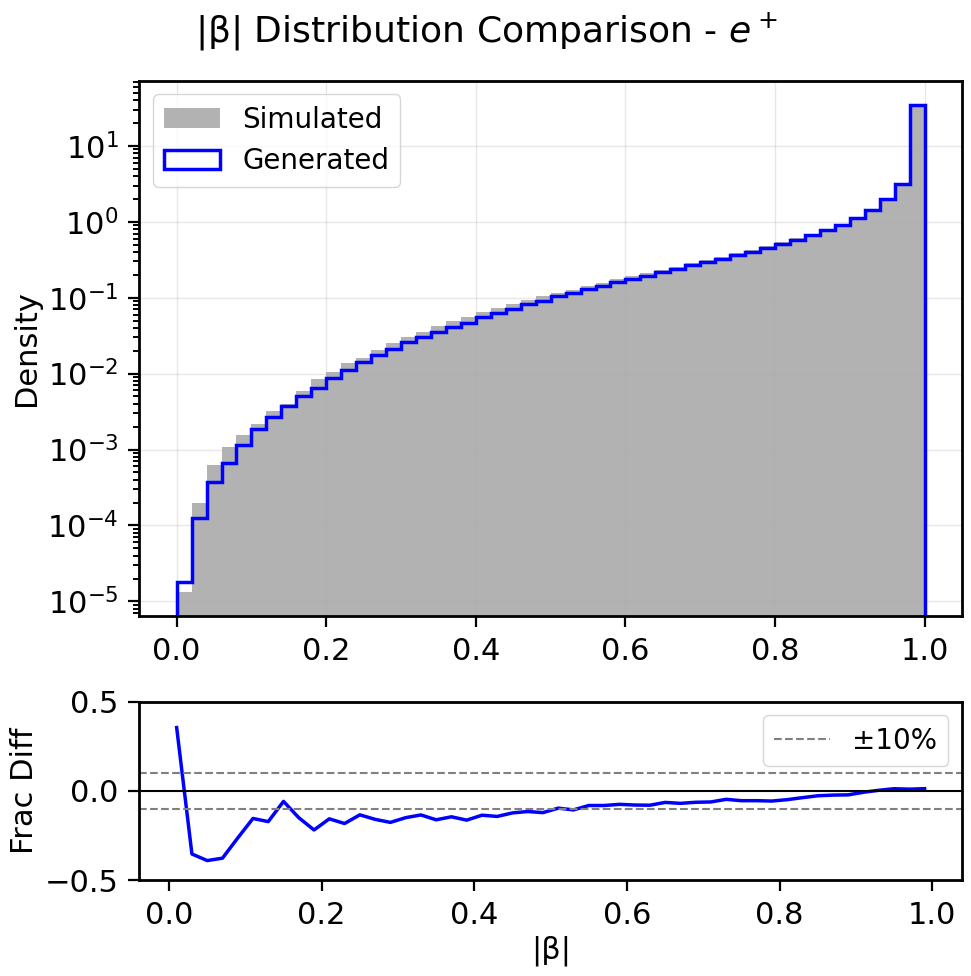

Statistics:
  Within ±10%: 25/50 (50.0%)
  Beyond ±10%: 25/50 (50.0%)

Comparing betax distributions for step 200...


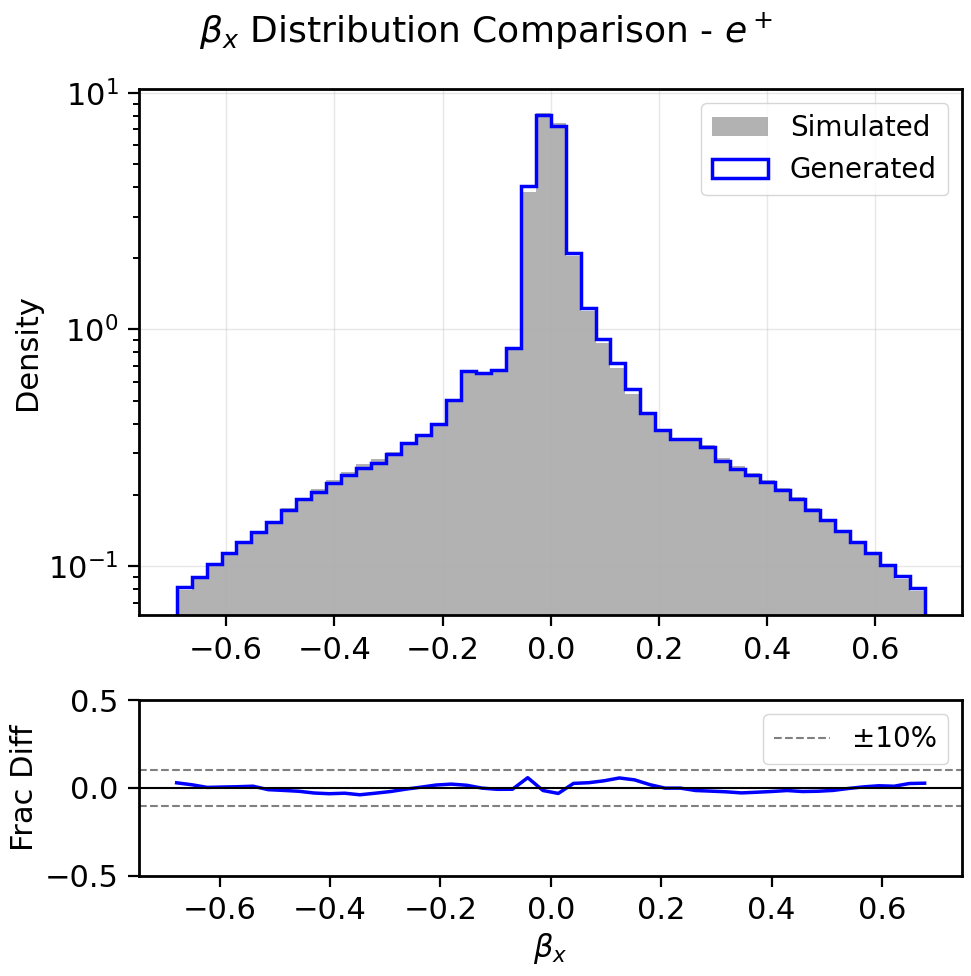

Statistics:
  Within ±10%: 50/50 (100.0%)
  Beyond ±10%: 0/50 (0.0%)

Comparing betay distributions for step 200...


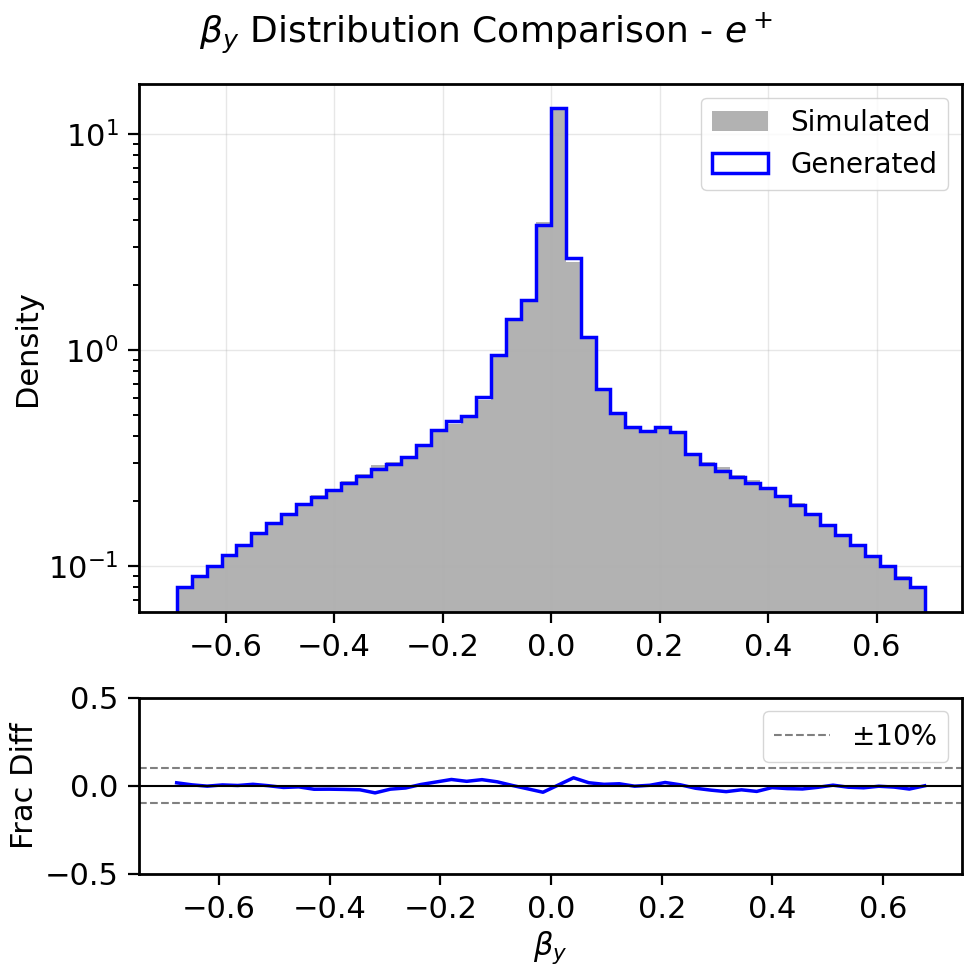

Statistics:
  Within ±10%: 50/50 (100.0%)
  Beyond ±10%: 0/50 (0.0%)

Comparing betaz distributions for step 200...


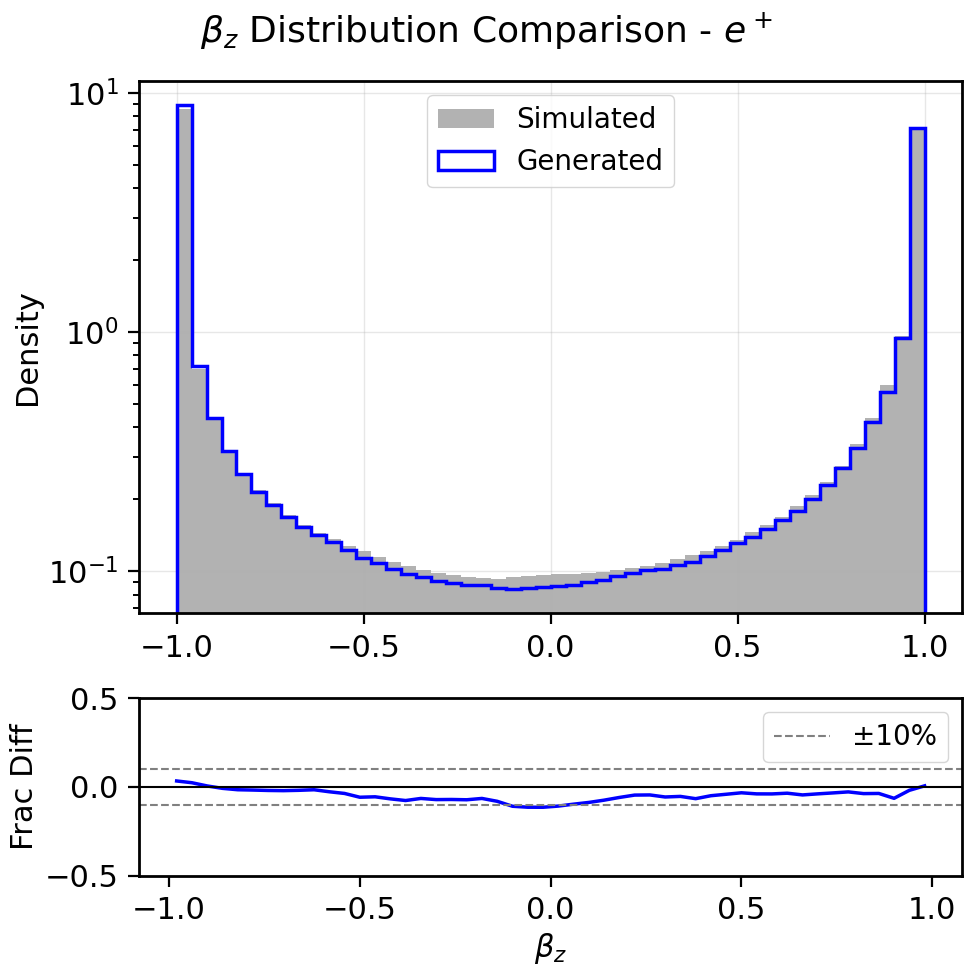

Statistics:
  Within ±10%: 46/50 (92.0%)
  Beyond ±10%: 4/50 (8.0%)

Comparing x distributions for step 200...


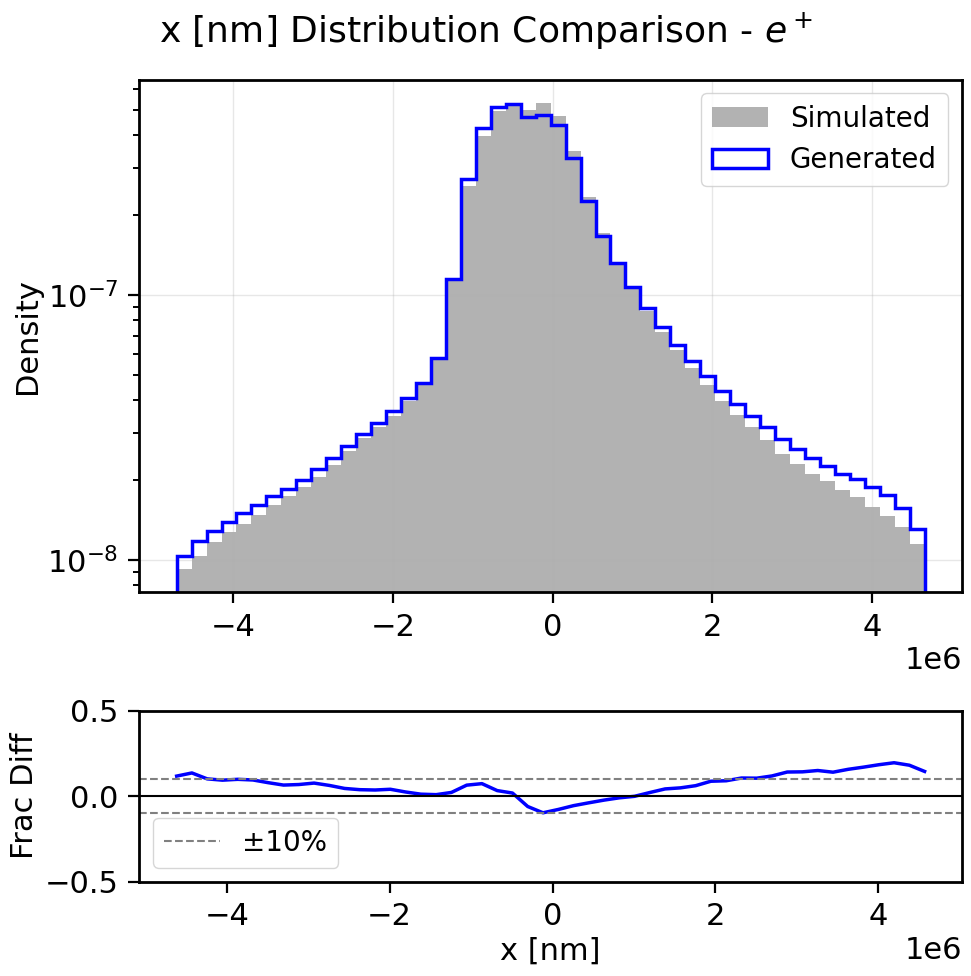

Statistics:
  Within ±10%: 34/50 (68.0%)
  Beyond ±10%: 16/50 (32.0%)

Comparing y distributions for step 200...


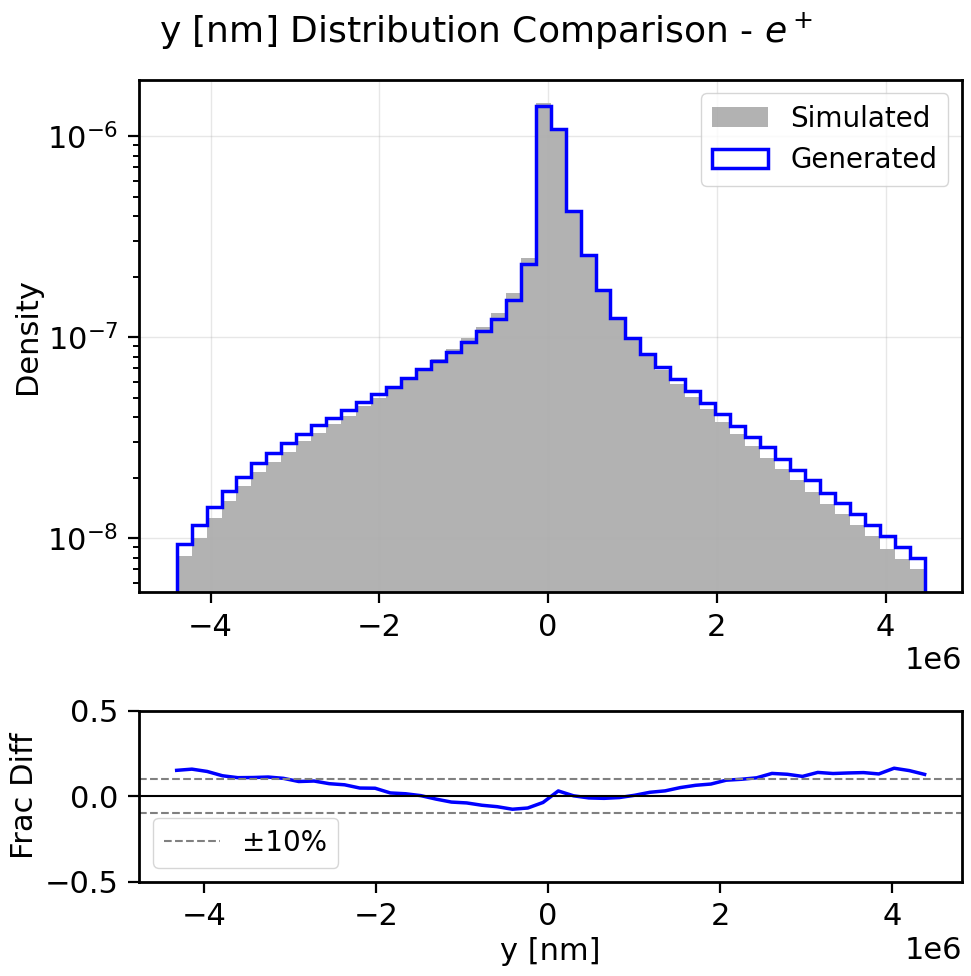

Statistics:
  Within ±10%: 30/50 (60.0%)
  Beyond ±10%: 20/50 (40.0%)

Comparing z distributions for step 200...


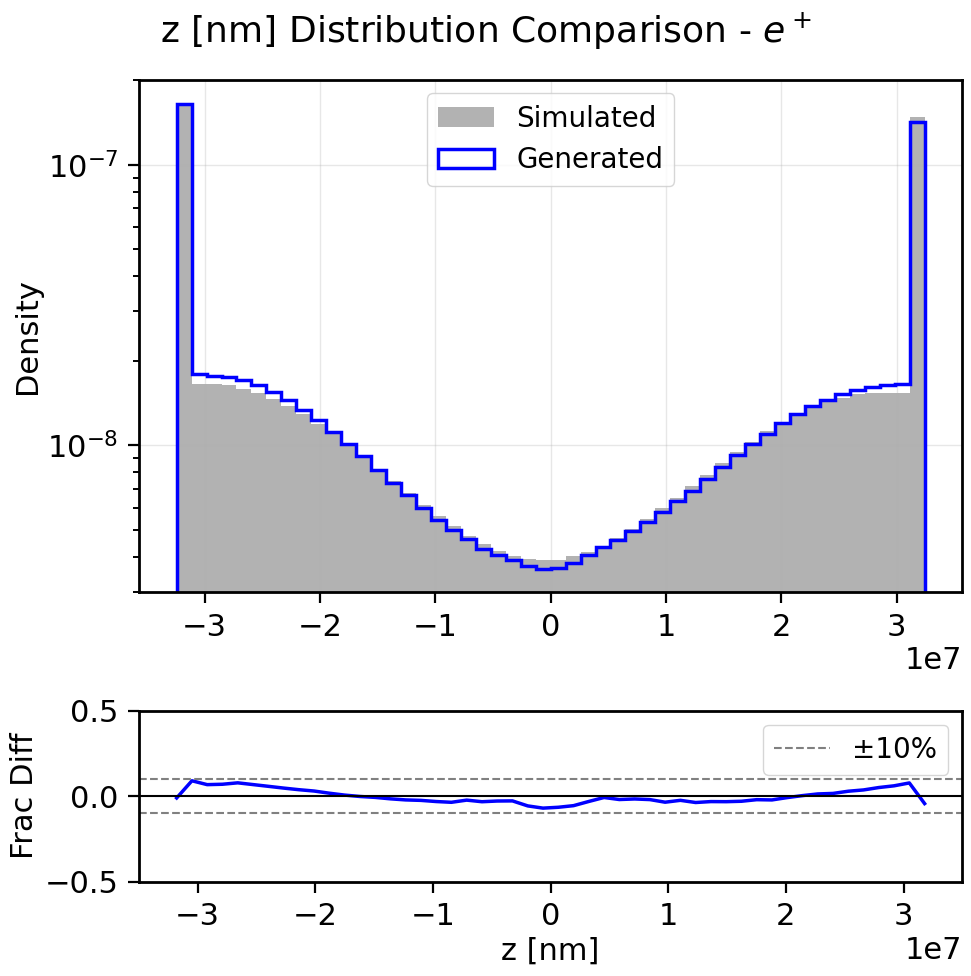

Statistics:
  Within ±10%: 50/50 (100.0%)
  Beyond ±10%: 0/50 (0.0%)


In [ ]:
physics_list = ['px', 'py', 'pz', 'p', 'pt', 'E', 'beta_mag', 'betax', 'betay', 'betaz', 'x', 'y', 'z', 'E_signed']
# tag = 'eplus' # select ['all', 'eminus','eplus']
# real_sp = real_data[tag]
# gen_sp = gen_data_all[SELECTED_STEP][tag]

tag_map = {
    'all': 'All particles',
    'eminus': r'$e^-$',
    'eplus': r'$e^+$'
}


for tag in ['all', 'eminus', 'eplus']:
    real_sp = real_data[tag]
    gen_sp = gen_data_all[SELECTED_STEP][tag]
    for physics in physics_list:
        print(f"\nComparing {physics} distributions for step {SELECTED_STEP}...")
        plot_distribution_comparison(
            real_vals=real_sp[physics],
            gen_vals=gen_sp[physics],
            xlabel=title_map[physics],
            title=f'{title_map[physics]} Distribution Comparison - {tag_map[tag]}',
            bins=50,
            range_quantile=0.99,
            threshold=0.1,
            yscale='log',
            save=True
        )

## 12. Compare All Steps

Compare distributions across all sampling steps in 1 figure

In [ ]:
def compare_distributions_across_steps(real_data, gen_data_all, physics, tag='all', 
                                       bins=50, range_quantile=0.95, 
                                       figsize=(12, 10), save=False):
    """
    Compare a specific physics variable across all sampling steps with fractional difference.
    
    Args:
        real_data: Dictionary containing real data for different particle species
        gen_data_all: Dictionary containing generated data for different steps
        physics: Physics variable to compare (e.g., 'E', 'px', 'py', 'pz', 'p', 'pt', 'betax', etc.)
        tag: Particle species tag ('all', 'eminus', 'eplus')
        bins: Number of bins for histogram (default: 50)
        range_quantile: Quantile for determining the range (default: 0.95)
        figsize: Figure size tuple (default: (12, 10))
        save: Whether to save the plot as PDF (default: False)
    """
    # Tag mapping for display names
    tag_map = {
        'all': 'All particles',
        'eminus': r'$e^-$',
        'eplus': r'$e^+$'
    }
    # Set matplotlib parameters for publication-quality figures
    plt.rcParams.update({
        'font.size': 14,           # Base font size
        'axes.labelsize': 20,      # Axis label font size
        'axes.titlesize': 22,      # Title font size
        'xtick.labelsize': 16,     # X-axis tick label size
        'ytick.labelsize': 16,     # Y-axis tick label size
        'legend.fontsize': 16,     # Legend font size
        'axes.linewidth': 1.5,     # Axis line width
        'grid.linewidth': 0.8,     # Grid line width
        'lines.linewidth': 2.0,    # Line width
        'xtick.major.width': 1.2,  # X tick width
        'ytick.major.width': 1.2,  # Y tick width
        'xtick.major.pad': 7,      # Padding between ticks and labels
        'ytick.major.pad': 7,      # Padding between ticks and labels
    })

    
    # Title mapping for physics variables
    title_map = {
        'mult': 'Multiplicity',
        'px': '$p_x$ [GeV/C]',
        'py': '$p_y$ [GeV/C]',
        'pz': '$p_z$ [GeV/C]',
        'p': '|p| [GeV/C]',
        'pt': '$p_T$ [GeV/C]',
        'E': '|E| [GeV]',
        'E_abs': '|E| [GeV]',
        'E_signed': '$E_{signed}$ [GeV]',
        'beta_mag': '|β|',
        'betax': '$\\beta_x$',
        'betay': '$\\beta_y$',
        'betaz': '$\\beta_z$',
        'x': 'x [nm]',
        'y': 'y [nm]',
        'z': 'z [nm]'
    }
    
    # Define colors for different steps
    colors = {
        "Simulated": "#bdbdbd",   # 灰填充
        "Step 25":  "#0000ff",    # 蓝
        "Step 50":  "#008000",    # 绿
        "Step 100": "#800080",    # 紫
        "Step 150": "#ff0000",    # 红
        "Step 200": "#00bcd4",    # 青
    }
    
    # Extract real data
    real_sp = real_data[tag]
    real_vals = real_sp[physics]
    
    # Compute range from real data
    range_lim = (0, np.quantile(real_vals, range_quantile)) if np.min(real_vals) >= 0 else \
                (np.quantile(real_vals, 1-range_quantile), np.quantile(real_vals, range_quantile))
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, gridspec_kw={'height_ratios': [3, 1]})
    fig.suptitle(f'{title_map[physics]} Distribution {tag_map[tag]}', fontsize=22, fontweight='bold')
    
    # Compute real histogram once
    real_hist, bin_edges = np.histogram(real_vals, bins=bins, range=range_lim, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Upper subplot: Distribution comparison
    ax1.hist(real_vals, bins=bin_edges, density=True, 
            alpha=0.6, label='Simulated', color=colors["Simulated"], zorder=10)
    
    # Plot each step and compute fractional differences
    for step in sorted(gen_data_all.keys()):
        gen_sp = gen_data_all[step][tag]
        gen_vals = gen_sp[physics]
        
        color = colors.get(f"Step {step}", 'gray')
        
        # Plot distribution
        ax1.hist(gen_vals, bins=bin_edges, density=True, 
                histtype='step', linewidth=2.5, label=f'Step {step}', 
                color=color, alpha=1, zorder=15)
        
        # Compute fractional difference for lower subplot
        gen_hist, _ = np.histogram(gen_vals, bins=bin_edges, density=True)
        frac_diff = np.where(real_hist > 0, (gen_hist - real_hist) / real_hist, 0)
        
        # Plot fractional difference
        ax2.plot(bin_centers, frac_diff, linewidth=2, 
                 color=color, alpha=0.8)
    
    ax1.set_ylabel('Density')
    ax1.set_yscale('log')
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(bin_edges[0], bin_edges[-1])
    
    # Lower subplot: Fractional difference
    ax2.axhline(0, color='black', linestyle='-', linewidth=1.5)
    ax2.axhline(0.1, color='grey', linestyle='--', linewidth=1, alpha=0.8, label='±10%')
    ax2.axhline(-0.1, color='grey', linestyle='--', linewidth=1, alpha=0.8)
    
    ax2.set_xlabel(f'{title_map[physics]}')
    ax2.set_ylabel('Frac Diff')
    ax2.legend(loc='best', ncol=2, fontsize = 14)
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(-1, 1)
    ax2.set_xlim(bin_edges[0], bin_edges[-1])
    
    plt.tight_layout()
    
    if save:
        plt.savefig(f'/work/submit/haoyun22/FCC-Beam-Background/output_figures/big_font/distribution_comparison_{physics}_{tag}_all_steps.pdf', dpi=300)
    
    plt.show()
    
    print(f"Compared {physics} distributions across steps: {list(gen_data_all.keys())}")
    print("Fractional Difference = (Generated - Real) / Real")

print("✓ Function compare_distributions_across_steps defined!")

In [ ]:
# Example: Compare distributions across all steps for all physics variables

# Define physics variables and particle types
physics_list = ['px', 'py', 'pz', 'p', 'pt', 'E', 'beta_mag', 'betax', 'betay', 'betaz', 'x', 'y', 'z']
tag_list = ['all', 'eminus', 'eplus']  # Particle species to compare

# Select which particle type to compare
tag = 'eplus'  # Change to 'eminus' or 'eplus' to compare specific species

print(f"Generating comparison plots for {tag}...")
print(f"Total plots to generate: {len(physics_list)}")
print("="*80)

# Generate comparison plots for all physics variables
for idx, physics in enumerate(physics_list, 1):
    print(f"\n[{idx}/{len(physics_list)}] Processing {physics}...")
    
    compare_distributions_across_steps(
        real_data=real_data,
        gen_data_all=gen_data_all,
        physics=physics,
        tag=tag,
        bins=50,
        range_quantile=0.99,
        figsize=(12, 10),
        save=False  # Set to True to save all plots
    )
    
    print(f"✓ Completed {physics}")

print("\n" + "="*80)
print(f"✓ All {len(physics_list)} comparison plots generated successfully!")
print("="*80)

### Quantitative Comparison: KL Divergence and Wasserstein Distance Across Steps

In [ ]:
# Compute metrics for each step
from scipy.stats import entropy, wasserstein_distance

tag = 'all'
physics_vars = ['E', 'p', 'pt', 'px', 'py', 'pz', 'betax', 'betay', 'betaz']

real_sp = real_data[tag]

# Downsample settings
MAX_SAMPLES = 300000  # Maximum samples per variable for faster computation
print(f"Using downsampling: max {MAX_SAMPLES} samples per variable\n")

results = {}

for step in sorted(gen_data_all.keys()):
    print(f"Computing metrics for step {step}...")
    gen_sp = gen_data_all[step][tag]
    results[step] = {}
    
    for var in physics_vars:
        real_vals = real_sp[var]
        gen_vals = gen_sp[var]
        
        if real_vals.size > 0 and gen_vals.size > 0:
            # Downsample if necessary
            if len(real_vals) > MAX_SAMPLES:
                rng = np.random.default_rng(42)
                real_indices = rng.choice(len(real_vals), MAX_SAMPLES, replace=False)
                real_vals_ds = real_vals[real_indices]
            else:
                real_vals_ds = real_vals
            
            if len(gen_vals) > MAX_SAMPLES:
                rng = np.random.default_rng(42)
                gen_indices = rng.choice(len(gen_vals), MAX_SAMPLES, replace=False)
                gen_vals_ds = gen_vals[gen_indices]
            else:
                gen_vals_ds = gen_vals
            
            # Compute range
            if np.min(real_vals_ds) >= 0:
                range_lim = (0, np.quantile(np.concatenate([real_vals_ds, gen_vals_ds]), 0.99))
            else:
                combined = np.concatenate([real_vals_ds, gen_vals_ds])
                range_lim = (np.quantile(combined, 0.01), np.quantile(combined, 0.99))
            
            # Compute histograms
            real_hist, bins = np.histogram(real_vals_ds, bins=100, range=range_lim, density=True)
            gen_hist, _ = np.histogram(gen_vals_ds, bins=bins, density=True)
            
            # Compute metrics
            kl = entropy(real_hist + 1e-10, gen_hist + 1e-10)
            wd = wasserstein_distance(real_vals_ds, gen_vals_ds)
            
            results[step][var] = {'KL': kl, 'W1': wd}
        else:
            results[step][var] = {'KL': np.nan, 'W1': np.nan}
    
    print(f"  ✓ Step {step} complete")

# Print table
print("\n" + "="*90)
print("Quantitative Metrics: KL Divergence and Wasserstein Distance")
print(f"(Computed with downsampled data: max {MAX_SAMPLES} samples)")
print("="*90)

for var in physics_vars:
    print(f"\n{var.upper()}")
    print("-"*90)
    print(f"{'Step':<10} {'KL Divergence':<20} {'Wasserstein Distance':<20}")
    print("-"*90)
    
    for step in sorted(gen_data_all.keys()):
        kl = results[step][var]['KL']
        wd = results[step][var]['W1']
        print(f"{step:<10} {kl:<20.6f} {wd:<20.6f}")

print("\n" + "="*90)
print("✓ Quantitative comparison complete!")
print("="*90)

### Visualization: Metrics vs Sampling Steps

In [ ]:
# Visualize how metrics change with sampling steps

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# KL Divergence
for var in ['E', 'pz', 'pt', 'betaz']:
    steps_list = sorted(gen_data_all.keys())
    kl_list = [results[step][var]['KL'] for step in steps_list]
    ax1.plot(steps_list, kl_list, marker='o', linewidth=2, label=var, markersize=8)

ax1.set_xlabel('Sampling Steps', fontsize=12)
ax1.set_ylabel('KL Divergence', fontsize=12)
ax1.set_title('KL Divergence vs Sampling Steps', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# Wasserstein Distance
for var in ['E', 'pz', 'pt', 'betaz']:
    steps_list = sorted(gen_data_all.keys())
    wd_list = [results[step][var]['W1'] for step in steps_list]
    ax2.plot(steps_list, wd_list, marker='s', linewidth=2, label=var, markersize=8)

ax2.set_xlabel('Sampling Steps', fontsize=12)
ax2.set_ylabel('Wasserstein Distance', fontsize=12)
ax2.set_title('Wasserstein Distance vs Sampling Steps', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log')

plt.tight_layout()
plt.show()

print("✓ Metrics visualization complete!")
print("\nNote: Lower values indicate better agreement with real data")

In [ ]:
# Run generation time benchmark 

STEPS = [25, 50, 100, 150, 200]
time_list = [0.2694, 0.5281, 1.0435, 2.0558, 2.2558]
time_cpu = [0.2694, 0.5281, 1.0435, 2.0558, 32.2605]

plt.figure(figsize=(8, 5))
plt.plot(STEPS, time_list, marker='o', linewidth=2, color='blue', label='GPU')
plt.plot(STEPS, time_cpu, marker='s', linewidth=2, color='red', label='CPU')
plt.xlabel('Sampling Steps', fontsize=12)
plt.ylabel('Average Sampling Time (s)', fontsize=12)
plt.title('Average Sampling Time vs Sampling Steps', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
# plt.xticks(STEPS)
plt.yscale('log')
plt.tight_layout()
plt.show()